In [2]:
# Standard library
import os, sys, json, pickle, warnings, time
from pathlib import Path
from itertools import product

# Scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')

# Reproducibility — set seeds for every library that uses randomness
SEED = 42
np.random.seed(SEED)
try:
    import random; random.seed(SEED)
except Exception: pass

# Plot defaults — publication-grade
mpl.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'axes.linewidth': 0.8,
    'axes.edgecolor': '#333333',
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'legend.frameon': False,
    'lines.linewidth': 1.5,
    'figure.facecolor': 'white',
    'savefig.facecolor': 'white',
    'pdf.fonttype': 42,   # editable text in vector PDFs (publisher requirement)
    'ps.fonttype': 42,
})
sns.set_style('whitegrid')
sns.set_context('paper')

print(f"Python: {sys.version.split()[0]}")
print(f"NumPy:  {np.__version__}")
print(f"Pandas: {pd.__version__}")

Python: 3.11.15
NumPy:  2.4.4
Pandas: 3.0.3


### 0.1 Configuration

All paths, hyperparameters, and toggles in one place. The defaults below are tuned for a **demonstration run** on a laptop (~1-2 hours total). For final publication-grade results, scale up `POP_SIZE`, `N_GEN`, and `SOBOL_N` as marked.


In [3]:
# === Paths ===
ROOT = Path(r'D:\3. dv paper')
assert ROOT.exists(), f"ROOT not found: {ROOT}"
CACHE = ROOT / 'cache'
assert CACHE.exists(), f"CACHE not found: {CACHE}"
FIGDIR = ROOT / 'figures'; FIGDIR.mkdir(exist_ok=True)
RESULTS = ROOT / 'results'; RESULTS.mkdir(exist_ok=True)
MFWS = ROOT / 'mf_workspace'; MFWS.mkdir(exist_ok=True)
AIN_DATA = ROOT / 'data' / 'ain'
AIN_SHP = AIN_DATA / 'wefe.shp'

# === Cache control ===
USE_CACHE = True  # set False to force recompute everything from scratch

# === Synthetic model ===
N_WELLS = 20
DV_RANGES = [(50, 500), (50, 1000)]
DOMAIN_VARIANTS = [1, 2]
DRAWDOWN_THRESH = 2.0  # m

# === Optimization ===
POP_SIZE = 100
N_GEN = 80
ALGOS = ['NSGA2', 'MOEAD', 'SMSEMOA']

# === Sobol sensitivity ===
SOBOL_N = 512  # base sample size; gives 512 * (2*20 + 2) = 21,504 evaluations

# === xAI / ML ===
XGB_PARAMS = dict(
    n_estimators=500, max_depth=5, learning_rate=0.05,
    objective='reg:squarederror', random_state=SEED
)
LIME_N_SAMPLES = 200
BOOTSTRAP_N = 100

# === Hotspot ===
KNN_K_VALUES = [3, 5]

print(f"Cache dir: {CACHE}")
print(f"USE_CACHE: {USE_CACHE}")
print(f"Synthetic runs scheduled: {len(ALGOS)} algos × "
      f"{len(DOMAIN_VARIANTS)} domains × {len(DV_RANGES)} DV ranges = "
      f"{len(ALGOS)*len(DOMAIN_VARIANTS)*len(DV_RANGES)} runs")

Cache dir: D:\3. dv paper\cache
USE_CACHE: True
Synthetic runs scheduled: 3 algos × 2 domains × 2 DV ranges = 12 runs


### 0.2 MODFLOW 6 binary

`flopy.utils.get_modflow()` downloads precompiled MODFLOW binaries to the flopy bin directory. Run once — re-running is a no-op if already installed.


In [4]:
import flopy
from flopy.utils import get_modflow
import os, shutil
from pathlib import Path

# Install to a known-writable location next to the notebook
BIN_DIR = Path.cwd() / 'bin'
BIN_DIR.mkdir(exist_ok=True)

exe_filename = 'mf6.exe' if os.name == 'nt' else 'mf6'
mf6_path = BIN_DIR / exe_filename

# Install if not already there
if not mf6_path.exists():
    print(f"Installing MODFLOW 6 to {BIN_DIR}...")
    try:
        get_modflow(str(BIN_DIR), subset='mf6', verbose=True)
    except Exception as e:
        print(f"get_modflow raised: {e}")

# Resolve and verify
if mf6_path.exists():
    MF6_EXE = str(mf6_path.resolve())
    print(f"✓ MODFLOW 6 found at: {MF6_EXE}")
else:
    # Last resort — check system PATH
    found = shutil.which('mf6') or shutil.which('mf6.exe')
    if found:
        MF6_EXE = found
        print(f"✓ MODFLOW 6 found on system PATH: {MF6_EXE}")
    else:
        # Diagnostic dump before failing
        print(f"!! Looked for binary at: {mf6_path}")
        print(f"!! BIN_DIR contents: {list(BIN_DIR.iterdir()) if BIN_DIR.exists() else 'dir missing'}")
        raise FileNotFoundError(
            "MODFLOW 6 binary not found. Manual fallback:\n"
            "  1. Download from https://github.com/MODFLOW-USGS/modflow6/releases\n"
            f"  2. Unzip mf6.exe into: {BIN_DIR}\n"
            "  3. Re-run this cell."
        )

print(f"FloPy version: {flopy.__version__}")


✓ MODFLOW 6 found at: D:\3. dv paper\bin\mf6.exe
FloPy version: 3.9.5


---
# Part A — Synthetic Benchmark

## 1. Freyberg-extended MODFLOW 6 model

### Design rationale

We extend the Freyberg (1988) benchmark to support a 20-DV optimization problem analogous in structure to the Ain basin study, while preserving the reviewer-recognizable geometry of the original.

**Key features:**
- 40 rows × 20 columns × 1 layer, 250 m cell size (10 km × 5 km domain) — matches Freyberg
- **Heterogeneous K**: background 5 m/d, high-K paleochannel (50 m/d) running NE-SW through the middle, low-K silt lens (1 m/d) in the NW. This deliberate heterogeneity ensures different wells have *meaningfully different* importance — otherwise the consensus framework has nothing to converge on.
- **River boundary** along the eastern edge (RIV package), stage 18 m, bottom 16 m, conductance 500 m²/d
- **Two boundary-condition variants** (`domain_variant`):
  - Variant 1: No-flow on north, south, west (closed system, dominant Freyberg setup)
  - Variant 2: Constant head (CHD = 22 m) on west (open system, mirrors Ain's Rhône-augmented domain)
- **Recharge**: 60 mm/year uniform (1.6e-4 m/d)
- **20 wells**: deliberately placed in a 4-column × 5-row grid spanning the domain, intersecting all three K zones and at varying distances from the river. Wells in the high-K channel near the river should drive R-A exchange; wells in the low-K NW should be inefficient for both objectives.


In [5]:
def make_well_locations(n_wells=20, nrow=40, ncol=20):
    '''Deliberately placed 4×5 well grid spanning K-zones and river distances.'''
    well_cols = [3, 8, 13, 17]      # 4 columns: far/mid/near/very-near river
    well_rows = [4, 12, 20, 28, 36] # 5 rows: spread N-S
    locs = [(0, r, c) for r in well_rows for c in well_cols]
    assert len(locs) == n_wells, f"Expected {n_wells} wells, got {len(locs)}"
    return locs

WELL_LOCS = make_well_locations(N_WELLS)
print(f"Well locations (layer, row, col): {len(WELL_LOCS)} wells")


Well locations (layer, row, col): 20 wells


In [6]:
def build_kfield(nrow=40, ncol=20):
    '''Heterogeneous K field with 3 zones — background, high-K paleochannel, low-K silt.'''
    k = np.full((nrow, ncol), 5.0, dtype=float)  # background
    # High-K paleochannel — diagonal swath
    for r in range(nrow):
        c_center = int(10 + 4 * np.sin(r * np.pi / 30))
        for c in range(max(0, c_center-3), min(ncol, c_center+3)):
            k[r, c] = 50.0
    # Low-K silt lens — NW corner
    k[30:38, 0:6] = 1.0
    return k

K_FIELD = build_kfield()
print(f"K field — min: {K_FIELD.min():.1f}, max: {K_FIELD.max():.1f} m/d")


K field — min: 1.0, max: 50.0 m/d


In [7]:
def build_freyberg_extended(workspace, domain_variant=1, pumping_rates=None,
                              sim_name='freyberg_ext'):
    nlay, nrow, ncol = 1, 40, 20
    delr = delc = 250.0
    top = 30.0
    botm = -30.0
    
    sim = flopy.mf6.MFSimulation(
        sim_name=sim_name, sim_ws=str(workspace),
        exe_name=MF6_EXE, version='mf6'
    )
    flopy.mf6.ModflowTdis(sim, time_units='DAYS', perioddata=[(1.0, 1, 1.0)])
    # Robust solver settings for unconfined steady-state
    flopy.mf6.ModflowIms(
        sim, complexity='MODERATE',
        outer_dvclose=1e-3, inner_dvclose=1e-4,
        outer_maximum=200, inner_maximum=200,
        linear_acceleration='BICGSTAB',
        print_option='SUMMARY'
    )
    
    gwf = flopy.mf6.ModflowGwf(sim, modelname=sim_name, save_flows=True,
                                newtonoptions='UNDER_RELAXATION')
    
    flopy.mf6.ModflowGwfdis(
        gwf, nlay=nlay, nrow=nrow, ncol=ncol,
        delr=delr, delc=delc, top=top, botm=botm
    )
    
    flopy.mf6.ModflowGwfnpf(gwf, icelltype=1, k=K_FIELD.tolist(), save_flows=True)
    flopy.mf6.ModflowGwfic(gwf, strt=22.0)   # start above river stage for stable convergence
    flopy.mf6.ModflowGwfsto(gwf, iconvert=1, ss=1e-5, sy=0.2, steady_state={0: True})
    
    # Recharge
    flopy.mf6.ModflowGwfrcha(gwf, recharge=1.6e-4)
    
    # River — east boundary
    # FIX: conductance was 0.5 m²/d, now 500 m²/d per cell (physically realistic for
    # an alluvial river: K_bed=0.1 m/d × W=20 m × L=250 m / b_bed=1 m = 500 m²/d).
    riv_data = [[(0, r, ncol-1), 18.0, 500.0, 16.0] for r in range(nrow)]
    flopy.mf6.ModflowGwfriv(gwf, stress_period_data={0: riv_data}, save_flows=True)
    
    if domain_variant == 2:
        chd_data = [[(0, r, 0), 22.0] for r in range(nrow)]
        flopy.mf6.ModflowGwfchd(gwf, stress_period_data={0: chd_data})
    
    if pumping_rates is None:
        pumping_rates = np.zeros(len(WELL_LOCS))
    wel_data = [[loc, -float(q)] for loc, q in zip(WELL_LOCS, pumping_rates)]
    flopy.mf6.ModflowGwfwel(gwf, stress_period_data={0: wel_data}, save_flows=True)
    
    flopy.mf6.ModflowGwfoc(
        gwf, head_filerecord=f'{sim_name}.hds',
        budget_filerecord=f'{sim_name}.cbc',
        saverecord=[('HEAD', 'ALL'), ('BUDGET', 'ALL')]
    )
    return sim

print("Builder updated. River conductance 0.5 → 500 m²/d. Solver hardened.")

Builder updated. River conductance 0.5 → 500 m²/d. Solver hardened.


In [8]:
def debug_modflow_run(workspace, sim_name='freyberg_ext'):
    '''Run with verbose output and dump the listing file tail on failure.'''
    sim = flopy.mf6.MFSimulation.load(sim_ws=str(workspace), exe_name=MF6_EXE, verbosity_level=0)
    success, buff = sim.run_simulation(silent=False)
    if not success:
        lst_path = Path(workspace) / 'mfsim.lst'
        if lst_path.exists():
            print("\n=== Tail of mfsim.lst (where the error lives) ===")
            with open(lst_path) as f:
                lines = f.readlines()
            print(''.join(lines[-60:]))
    return success

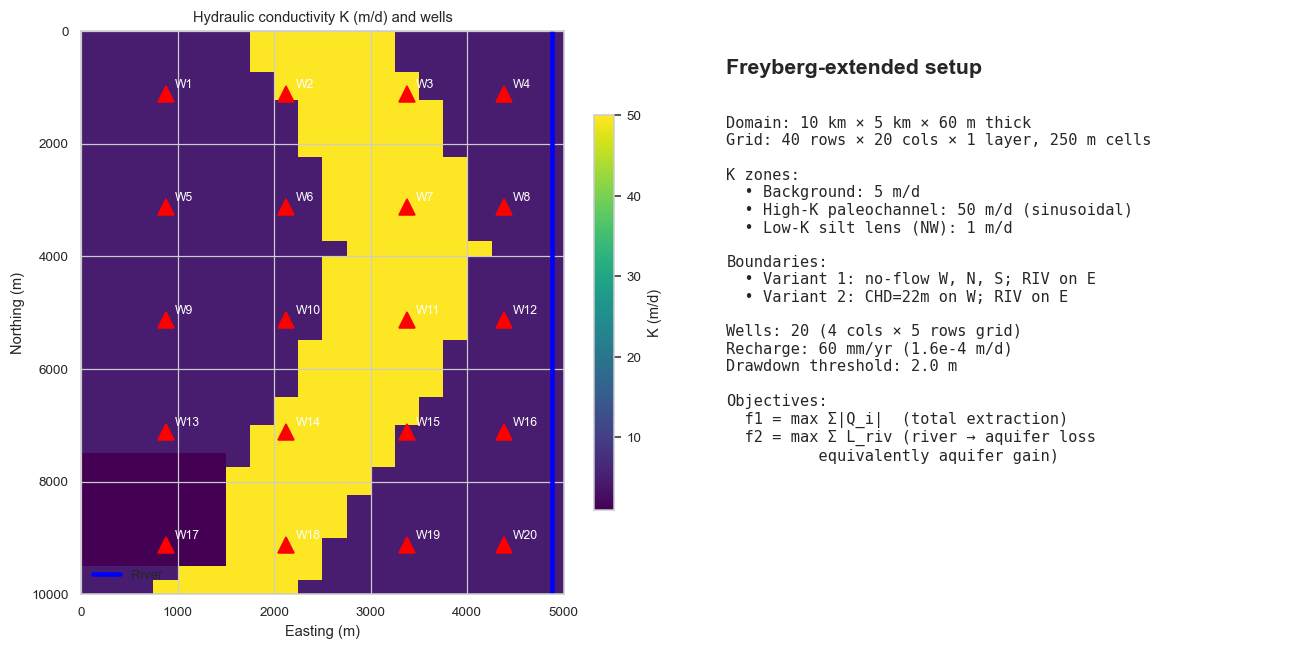

In [9]:
# Figure 1 — model setup visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# K field
im0 = axes[0].imshow(K_FIELD, cmap='viridis', aspect='auto', origin='upper',
                     extent=[0, 5000, 10000, 0])
axes[0].set_title('Hydraulic conductivity K (m/d) and wells')
axes[0].set_xlabel('Easting (m)'); axes[0].set_ylabel('Northing (m)')
plt.colorbar(im0, ax=axes[0], label='K (m/d)', shrink=0.7)

# Overlay wells and river
for i, (_, r, c) in enumerate(WELL_LOCS):
    x = c * 250 + 125; y = r * 250 + 125
    axes[0].plot(x, y, 'r^', markersize=10)
    axes[0].annotate(f'W{i+1}', (x, y), textcoords='offset points',
                     xytext=(6, 4), fontsize=8, color='white')
# River
axes[0].plot([4875, 4875], [0, 10000], 'b-', linewidth=3, label='River')
axes[0].legend(loc='lower left')

# Conceptual cross-section / annotation
axes[1].axis('off')
axes[1].text(0.05, 0.95, 'Freyberg-extended setup', fontsize=14, weight='bold',
             transform=axes[1].transAxes, va='top')
desc = (
    'Domain: 10 km × 5 km × 60 m thick\n'
    'Grid: 40 rows × 20 cols × 1 layer, 250 m cells\n\n'
    'K zones:\n'
    '  • Background: 5 m/d\n'
    '  • High-K paleochannel: 50 m/d (sinusoidal)\n'
    '  • Low-K silt lens (NW): 1 m/d\n\n'
    'Boundaries:\n'
    '  • Variant 1: no-flow W, N, S; RIV on E\n'
    '  • Variant 2: CHD=22m on W; RIV on E\n\n'
    f'Wells: {N_WELLS} (4 cols × 5 rows grid)\n'
    'Recharge: 60 mm/yr (1.6e-4 m/d)\n'
    f'Drawdown threshold: {DRAWDOWN_THRESH} m\n\n'
    'Objectives:\n'
    '  f1 = max Σ|Q_i|  (total extraction)\n'
    '  f2 = max Σ L_riv (river → aquifer loss\n'
    '          equivalently aquifer gain)'
)
axes[1].text(0.05, 0.85, desc, fontsize=10, transform=axes[1].transAxes,
             va='top', family='monospace')

plt.tight_layout()
# plt.savefig(FIGDIR / 'fig01_synthetic_model_setup.png')
plt.show()


### 1.1 Baseline run and objective evaluator

Run the model with **zero pumping** once per domain variant; cache the resulting heads as the drawdown reference. Then define `evaluate_pumping()` which:
1. Updates the WEL package with new rates
2. Runs MODFLOW 6
3. Extracts heads and river leakage from the budget file
4. Computes objectives and drawdown penalty
5. Returns `(Q_total, L_river, penalty, drawdown_violations)`

**Sign convention** (paper): both objectives are maximized as positive quantities. Internally, pymoo minimizes, so we negate before returning to the optimizer.

**River leakage**: from the cell-by-cell budget file, the `RIV` flow is positive when flow goes *into* the aquifer (river → aquifer = aquifer gain). The paper's "maximize R-A exchange" means maximize the *magnitude* of beneficial gain to the aquifer; we use the river-to-aquifer flux directly (positive values means river loses to aquifer).


In [10]:
def run_and_extract(workspace, sim_name='freyberg_ext'):
    '''Run a built model and return (heads_2d, river_leakage_total).'''
    sim = flopy.mf6.MFSimulation.load(sim_ws=str(workspace), exe_name=MF6_EXE,verbosity_level=0)
    success, _ = sim.run_simulation(silent=True)
    if not success:
        raise RuntimeError(f"MODFLOW failed in {workspace}")
    
    gwf = sim.get_model(sim_name)
    head = gwf.output.head().get_data().squeeze()  # 2D head
    
    # River budget — sum over all RIV cells
    bud = gwf.output.budget()
    riv_rec = bud.get_data(text='RIV', kstpkper=(0, 0))[0]
    # 'q' field: negative = water leaving aquifer (going to river)
    #            positive = water entering aquifer (from river)
    # For "max R-A exchange" interpret as aquifer→river flux = -sum(q) where q<0
    riv_flux_to_aq = riv_rec['q'].sum()   # net into aquifer (can be negative)
    return head, riv_flux_to_aq

# Compute baseline heads (no pumping) for each domain variant — cached
BASELINE_HEADS = {}
for dv in DOMAIN_VARIANTS:
    cache_file = CACHE / f'baseline_heads_dv{dv}.pkl'
    if USE_CACHE and cache_file.exists():
        with open(cache_file, 'rb') as f:
            BASELINE_HEADS[dv] = pickle.load(f)
        print(f"Loaded baseline for variant {dv} from cache.")
    else:
        ws = MFWS / f'baseline_dv{dv}'
        ws.mkdir(exist_ok=True)
        sim = build_freyberg_extended(ws, domain_variant=dv, pumping_rates=None)
        sim.write_simulation(silent=True)
        head, _ = run_and_extract(ws)
        BASELINE_HEADS[dv] = head
        with open(cache_file, 'wb') as f:
            pickle.dump(head, f)
        print(f"Computed baseline for variant {dv} — head min/max: {head.min():.2f}/{head.max():.2f}")


Loaded baseline for variant 1 from cache.
Loaded baseline for variant 2 from cache.


In [11]:
def evaluate_pumping(pumping_rates, domain_variant=1, workspace=None,
                      drawdown_threshold=DRAWDOWN_THRESH, c_penalty=1e3):
    '''
    Evaluates the synthetic model under a given pumping configuration.
    
    Returns
    -------
    dict with keys:
        Q       — total extraction (m^3/d)
        L       — river leakage out of aquifer (m^3/d, positive = aquifer→river)
        penalty — drawdown-based penalty (>= 0)
        dd_max  — maximum drawdown observed (m)
        viol_n  — number of well cells exceeding drawdown threshold
    '''
    workspace = workspace or (MFWS / f'eval_dv{domain_variant}_{os.getpid()}')
    workspace = Path(workspace); workspace.mkdir(exist_ok=True, parents=True)
    
    pumping_rates = np.asarray(pumping_rates, dtype=float)
    Q_total = pumping_rates.sum()
    
    sim = build_freyberg_extended(workspace, domain_variant=domain_variant,
                                   pumping_rates=pumping_rates)
    sim.write_simulation(silent=True)
    
    try:
        head, riv_to_aq = run_and_extract(workspace)
    except Exception as e:
        # If MODFLOW fails (dry cells, etc.) return penalty values
        return dict(Q=Q_total, L=0.0, penalty=c_penalty*100, dd_max=99.0, viol_n=N_WELLS, ok=False)
    
    # Drawdown at well cells
    baseline = BASELINE_HEADS[domain_variant]
    dd_at_wells = []
    for (_, r, c) in WELL_LOCS:
        dd = baseline[r, c] - head[r, c]
        dd_at_wells.append(max(0, dd))
    dd_at_wells = np.array(dd_at_wells)
    viol = np.maximum(dd_at_wells - drawdown_threshold, 0.0)
    penalty = c_penalty * (viol**2).sum()
    
    # L_river: paper defines "leakage out of aquifer to river" — i.e., aquifer→river flux
    # In MODFLOW budget, river-to-aquifer is positive; reverse sign for paper convention.
    L = -riv_to_aq  # positive = aquifer loses to river (baseflow)
    
    return dict(Q=Q_total, L=L, penalty=penalty,
                dd_max=dd_at_wells.max(), viol_n=int((dd_at_wells > drawdown_threshold).sum()),
                ok=True)

# Smoke test
test_rates = np.full(N_WELLS, 200.0)
res = evaluate_pumping(test_rates, domain_variant=1)
print(f"Test eval: Q={res['Q']:.0f}, L={res['L']:.1f}, penalty={res['penalty']:.2f}, "
      f"dd_max={res['dd_max']:.2f} m, violations={res['viol_n']}, ok={res['ok']}")


Test eval: Q=4000, L=3998.7, penalty=5337.36, dd_max=3.85 m, violations=10, ok=True


---
## 2. Multi-objective optimization on the synthetic model

We run **3 algorithms × 2 boundary variants × 2 DV ranges = 12 configurations**, mirroring the meta-structure of the Ain study.

### Algorithms
- **NSGA-II** (Deb et al., 2002) — non-dominated sorting genetic algorithm; canonical baseline
- **MOEA/D** (Zhang & Li, 2007) — decomposition-based
- **SMS-EMOA** (Beume et al., 2007) — S-metric (hypervolume) selection

**MOPSO substitution note:** pymoo does not ship MOPSO natively. SMS-EMOA is used here as the third algorithm to span a different selection paradigm (hypervolume vs. dominance vs. decomposition). For exact MOPSO parity with the Ain stack, install `jMetalPy` and substitute `jmetal.algorithm.multiobjective.OMOPSO`. Document the substitution clearly in the manuscript.

### Why these meta-conditions?
The paper's central claim is that DV-space behavior depends on optimization setup. Running all 12 configurations lets us:
- Pool ~600-1200 Pareto-optimal DV vectors across setups
- Test cross-algorithm robustness of importance rankings
- Quantify the effect of boundary conditions and DV range on the optimal DV distribution


In [12]:
from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.algorithms.moo.moead import MOEAD
from pymoo.algorithms.moo.sms import SMSEMOA
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.lhs import LHS
from pymoo.util.ref_dirs import get_reference_directions
from pymoo.optimize import minimize as pymoo_minimize

# NOTE: GroundwaterPumpingProblem is defined in the next cell (the publication-run
# version with per-slot workspaces). Only make_algorithm is defined here.

def make_algorithm(name, n_var=N_WELLS, pop_size=POP_SIZE):
    if name == 'NSGA2':
        return NSGA2(pop_size=pop_size, sampling=LHS(),
                     crossover=SBX(eta=15, prob=0.9),
                     mutation=PM(eta=20, prob=1.0/n_var),
                     eliminate_duplicates=True)
    elif name == 'MOEAD':
        ref_dirs = get_reference_directions('uniform', 2, n_partitions=pop_size-1)
        return MOEAD(ref_dirs=ref_dirs, n_neighbors=10,
                     prob_neighbor_mating=0.7,
                     crossover=SBX(eta=15, prob=0.9),
                     mutation=PM(eta=20, prob=1.0/n_var))
    elif name == 'SMSEMOA':
        return SMSEMOA(pop_size=pop_size, sampling=LHS(),
                       crossover=SBX(eta=15, prob=0.9),
                       mutation=PM(eta=20, prob=1.0/n_var))
    raise ValueError(name)

print("make_algorithm defined. (Problem class is in the next cell.)")

make_algorithm defined. (Problem class is in the next cell.)


In [13]:
# ====================================================================
# OVERNIGHT RUN — PUBLICATION-GRADE SETTINGS
# ====================================================================
from pymoo.core.callback import Callback

# Override config — publication settings comparable to Ain optimization stack
POP_SIZE_RUN = 100
N_GEN_RUN    = 180
PRINT_EVERY  = 10   # print progress every N generations

# --- Corrected Problem class (sequential, no thread workspace bug) ---
class GroundwaterPumpingProblem(Problem):
    '''Sequential vectorized problem. Each individual gets its own workspace
    indexed by position in X, so no PID collisions even if you ever re-add threads.'''
    def __init__(self, domain_variant, dv_range):
        super().__init__(n_var=N_WELLS, n_obj=2,
                         xl=np.full(N_WELLS, dv_range[0]),
                         xu=np.full(N_WELLS, dv_range[1]))
        self.domain_variant = domain_variant
        self.dv_range = dv_range
    
    def _evaluate(self, X, out, *args, **kwargs):
        F = np.zeros((X.shape[0], 2))
        for i, x in enumerate(X):
            ws = MFWS / f'eval_dv{self.domain_variant}_slot{i}'
            res = evaluate_pumping(x, domain_variant=self.domain_variant, workspace=ws)
            F[i, 0] = -res['Q'] + res['penalty']
            F[i, 1] = -res['L'] + res['penalty']
        out['F'] = F


# --- Progress callback: prints every PRINT_EVERY generations ---
class GenCallback(Callback):
    def __init__(self, tag, print_every=PRINT_EVERY):
        super().__init__()
        self.tag = tag
        self.print_every = print_every
        self.t_start = time.time()
    
    def notify(self, algorithm):
        gen = algorithm.n_iter
        if gen != 1 and gen % self.print_every != 0:
            return
        n_evals = algorithm.evaluator.n_eval
        elapsed_min = (time.time() - self.t_start) / 60
        F = algorithm.pop.get('F')
        Q_max, L_max = -F.min(axis=0)  # un-negate for max convention
        print(f"    [{self.tag}] gen {gen:3d}/{N_GEN_RUN} | evals {n_evals:5d} | "
              f"elapsed {elapsed_min:5.1f}min | Q_max {Q_max:7.0f} | L_max {L_max:7.0f}",
              flush=True)


# --- Runner with progress callback ---
def run_one_configuration(algo_name, domain_variant, dv_range,
                            pop_size=POP_SIZE_RUN, n_gen=N_GEN_RUN):
    problem = GroundwaterPumpingProblem(domain_variant, dv_range)
    # rebuild algo with publication pop_size (overrides POP_SIZE in make_algorithm)
    algo = make_algorithm(algo_name, pop_size=pop_size)
    tag = f'{algo_name}_dv{domain_variant}_r{dv_range[1]}'
    cb = GenCallback(tag)
    res = pymoo_minimize(problem, algo, termination=('n_gen', n_gen),
                         seed=SEED, verbose=False, save_history=False, callback=cb)
    X = res.X if res.X is not None else np.empty((0, N_WELLS))
    F = res.F if res.F is not None else np.empty((0, 2))
    Q = -F[:, 0]; L = -F[:, 1]
    df = pd.DataFrame(X, columns=[f'DV_{i+1}' for i in range(N_WELLS)])
    df.insert(0, 'Q', Q); df.insert(1, 'L', L)
    df['algo'] = algo_name; df['domain'] = domain_variant
    df['dv_low'] = dv_range[0]; df['dv_high'] = dv_range[1]
    return df


# --- Plan summary ---
n_configs = len(ALGOS) * len(DOMAIN_VARIANTS) * len(DV_RANGES)
est_evals = POP_SIZE_RUN * (N_GEN_RUN + 1)
est_hours = n_configs * est_evals * 0.20 / 3600
print("="*72)
print(f"OVERNIGHT RUN — start {time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  POP_SIZE = {POP_SIZE_RUN}, N_GEN = {N_GEN_RUN}")
print(f"  Configs:  {n_configs}  (3 algos × 2 domains × 2 DV ranges)")
print(f"  Evals/config: ~{est_evals:,}   Total: ~{n_configs*est_evals:,}")
print(f"  Est. wall time: ~{est_hours:.1f} hours")
print("="*72, flush=True)

# --- Execute with incremental save (crash-resilient) ---
PUB_CACHE = CACHE / 'synthetic_pareto_fronts_PUBLICATION.pkl'
synthetic_fronts = {}
if PUB_CACHE.exists():
    with open(PUB_CACHE, 'rb') as f:
        synthetic_fronts = pickle.load(f)
    print(f"\n>> Resuming — {len(synthetic_fronts)} configs already complete: "
          f"{list(synthetic_fronts.keys())}\n")

t_all = time.time()
configs = list(product(ALGOS, DOMAIN_VARIANTS, DV_RANGES))

for i, (algo, dv, dvr) in enumerate(configs, 1):
    key = f'{algo}_dv{dv}_range{dvr[1]}'
    header = f"[{i:2d}/{len(configs)}] {key}"
    if key in synthetic_fronts:
        print(f"{header}  --  already cached, skipping")
        continue
    print(f"\n{header}  --  start {time.strftime('%H:%M:%S')}", flush=True)
    t_cfg = time.time()
    try:
        df = run_one_configuration(algo, dv, dvr)
        synthetic_fronts[key] = df
        # Save IMMEDIATELY — crash safety
        with open(PUB_CACHE, 'wb') as f:
            pickle.dump(synthetic_fronts, f)
        print(f"{header}  --  done: {len(df)} solutions in "
              f"{(time.time()-t_cfg)/60:.1f} min  (running {(time.time()-t_all)/3600:.2f}h total)",
              flush=True)
    except Exception as e:
        print(f"!! {header}  --  FAILED: {type(e).__name__}: {e}", flush=True)
        import traceback; traceback.print_exc()
        continue

# --- Final summary ---
print("\n" + "="*72)
print(f"COMPLETE  --  end {time.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  Configs done: {len(synthetic_fronts)}/{len(configs)}")
print(f"  Total time:   {(time.time()-t_all)/3600:.2f} hours")
print("="*72)

summary = pd.DataFrame([
    {'config': k, 'n_solutions': len(v),
     'Q_range': f"{v.Q.min():.0f} – {v.Q.max():.0f}",
     'L_range': f"{v.L.min():.0f} – {v.L.max():.0f}"}
    for k, v in synthetic_fronts.items()
])
print(summary.to_string(index=False))

OVERNIGHT RUN — start 2026-09-17 16:08:22
  POP_SIZE = 100, N_GEN = 180
  Configs:  12  (3 algos × 2 domains × 2 DV ranges)
  Evals/config: ~18,100   Total: ~217,200
  Est. wall time: ~12.1 hours

>> Resuming — 12 configs already complete: ['NSGA2_dv1_range500', 'NSGA2_dv1_range1000', 'NSGA2_dv2_range500', 'NSGA2_dv2_range1000', 'MOEAD_dv1_range500', 'MOEAD_dv1_range1000', 'MOEAD_dv2_range500', 'MOEAD_dv2_range1000', 'SMSEMOA_dv1_range500', 'SMSEMOA_dv1_range1000', 'SMSEMOA_dv2_range500', 'SMSEMOA_dv2_range1000']

[ 1/12] NSGA2_dv1_range500  --  already cached, skipping
[ 2/12] NSGA2_dv1_range1000  --  already cached, skipping
[ 3/12] NSGA2_dv2_range500  --  already cached, skipping
[ 4/12] NSGA2_dv2_range1000  --  already cached, skipping
[ 5/12] MOEAD_dv1_range500  --  already cached, skipping
[ 6/12] MOEAD_dv1_range1000  --  already cached, skipping
[ 7/12] MOEAD_dv2_range500  --  already cached, skipping
[ 8/12] MOEAD_dv2_range1000  --  already cached, skipping
[ 9/12] SMSEMOA_dv1_

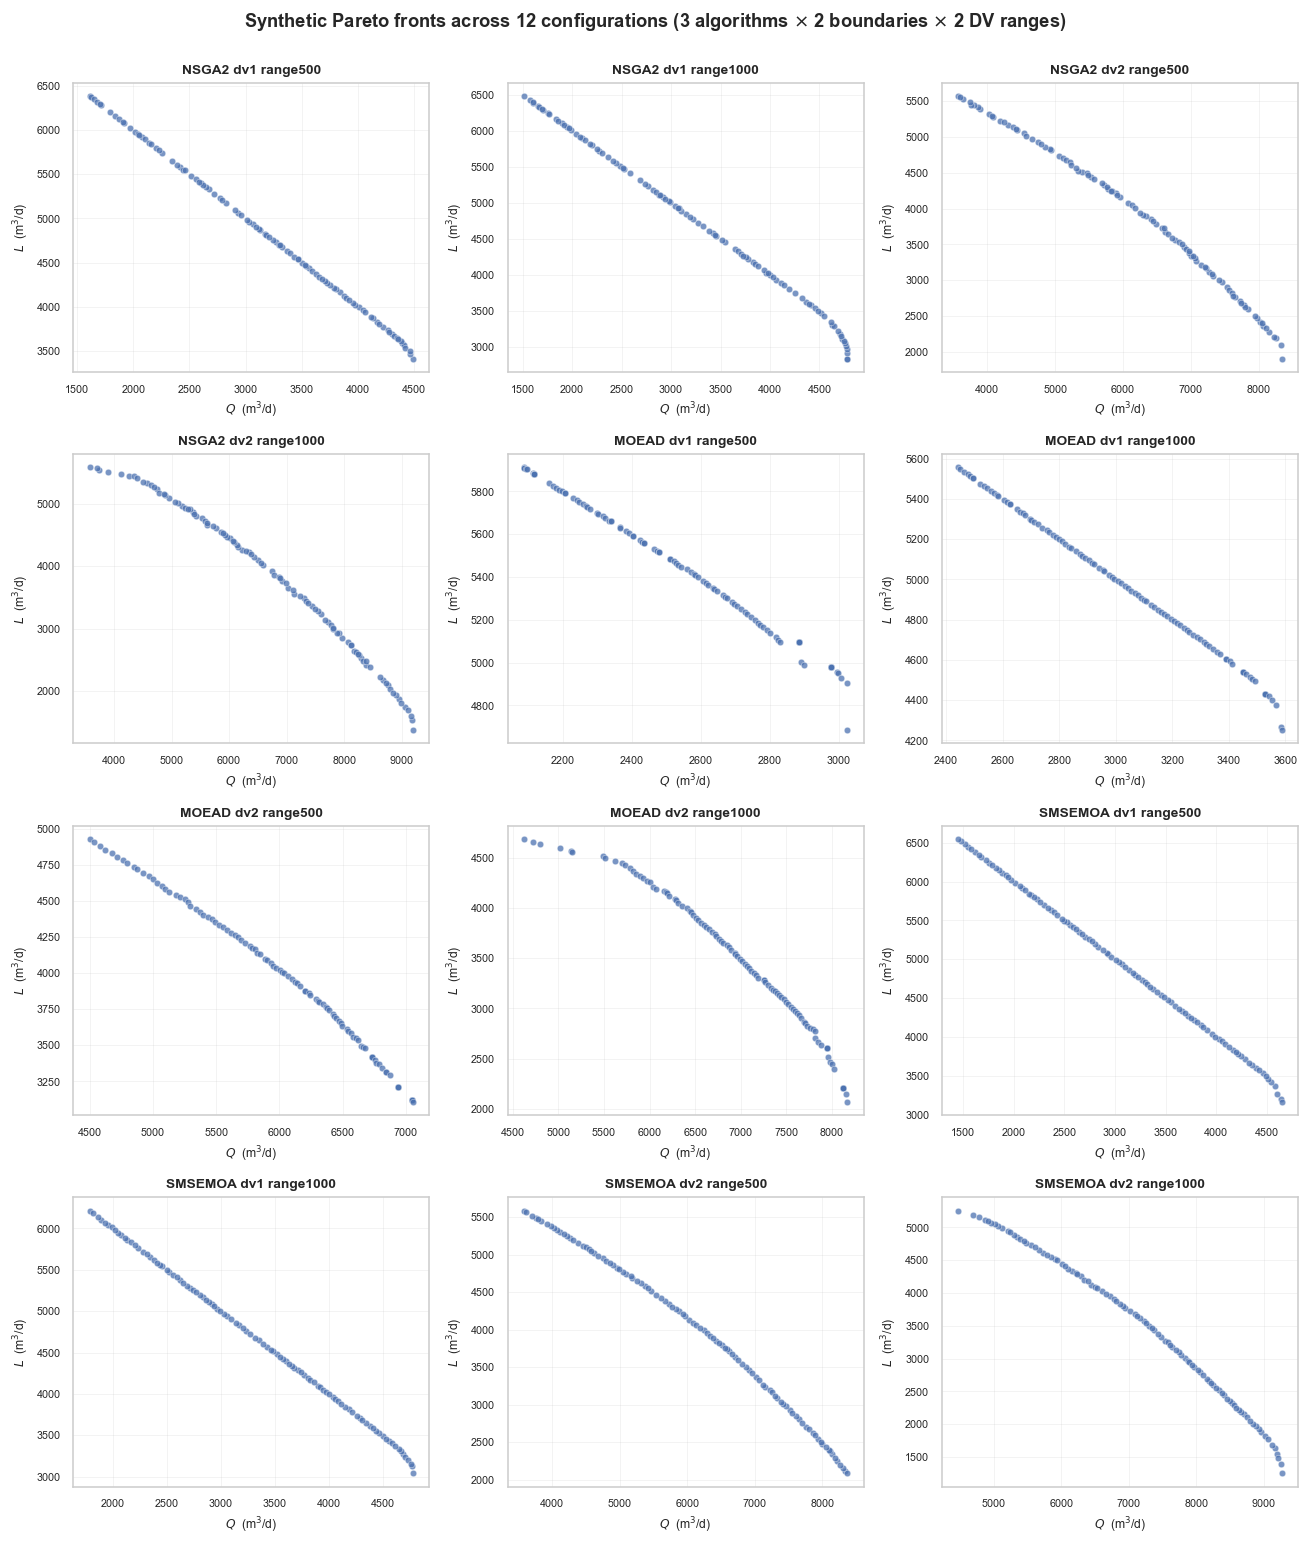

Pooled synthetic dataset: 1200 Pareto-optimal solutions across 12 configs


In [14]:
# Figure 2 — all 12 Pareto fronts
fig, axes = plt.subplots(4, 3, figsize=(12, 14), sharex=False, sharey=False)
for i, (key, df) in enumerate(synthetic_fronts.items()):
    ax = axes.flat[i]
    ax.scatter(df['Q'], df['L'], s=18, alpha=0.75, c='#4C72B0',
               edgecolor='white', linewidth=0.3)
    # clean title: algo / variant / range
    ax.set_title(key.replace('_', ' '), fontsize=9, fontweight='bold')
    ax.set_xlabel('$Q$  (m$^3$/d)', fontsize=8)
    ax.set_ylabel('$L$  (m$^3$/d)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.3, linewidth=0.5)
    ax.set_axisbelow(True)
fig.suptitle('Synthetic Pareto fronts across 12 configurations (3 algorithms $\\times$ 2 boundaries $\\times$ 2 DV ranges)',
             fontsize=12, fontweight='bold', y=1.0)
plt.tight_layout()
plt.savefig(FIGDIR / 'fig02_synthetic_pareto_fronts.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGDIR / 'fig02_synthetic_pareto_fronts.pdf', bbox_inches='tight')
plt.show()

# Pool all into a single dataframe for the framework
SYN_DF = pd.concat(synthetic_fronts.values(), ignore_index=True)
print(f"Pooled synthetic dataset: {len(SYN_DF)} Pareto-optimal solutions across {len(synthetic_fronts)} configs")

---
## 3. Sobol indices — ground-truth sensitivity

This is the methodological keystone of the paper. On the synthetic model we can afford brute-force Sobol sampling, giving us a ground-truth ranking of well importance for each objective. Every xAI method downstream will be **validated against these Sobol indices**.

We compute:
- **First-order index $S_1$**: variance attributable to each well alone
- **Total-order index $S_T$**: variance including all interactions involving that well

Total-order indices are typically what the paper should compare xAI methods against because SHAP/LIME importance scores capture interaction effects too.

Sample count: `SOBOL_N = 64` (demo) → `SOBOL_N × (D+2) = 64 × 22 = 1408` model evaluations (both Q and L extracted per run). Set `SOBOL_N=1024` for publication (~22k evals, overnight run).


In [15]:
from SALib.sample.sobol import sample as sobol_sample
from SALib.analyze.sobol import analyze as sobol_analyze

def make_sobol_problem(dv_range):
    return {
        'num_vars': N_WELLS,
        'names': [f'DV_{i+1}' for i in range(N_WELLS)],
        'bounds': [[dv_range[0], dv_range[1]] for _ in range(N_WELLS)]
    }

def run_sobol(domain_variant=1, dv_range=(50, 1000), n=SOBOL_N, calc_second_order=True):
    tag = 'S2' if calc_second_order else 'S1'
    cache_file = CACHE / f'sobol_dv{domain_variant}_range{dv_range[1]}_N{n}_{tag}.pkl'
    if USE_CACHE and cache_file.exists():
        with open(cache_file, 'rb') as f:
            return pickle.load(f)

    problem = make_sobol_problem(dv_range)
    param_values = sobol_sample(problem, n, calc_second_order=calc_second_order)
    expected = n * ((2*N_WELLS + 2) if calc_second_order else (N_WELLS + 2))
    assert len(param_values) == expected, f"Sample count mismatch: {len(param_values)} vs {expected}"
    print(f"Sobol: evaluating {len(param_values):,} samples "
          f"(variant {domain_variant}, range {dv_range}, second-order={calc_second_order})...",
          flush=True)

    Q_out = np.zeros(len(param_values))
    L_out = np.zeros(len(param_values))
    t0 = time.time()
    for i, x in enumerate(param_values):
        r = evaluate_pumping(x, domain_variant=domain_variant)
        # No penalty subtraction, no feasibility mask -- raw physics for Sobol decomposition.
        # Infeasible-region behaviour is part of what Sobol measures in the full DV space.
        Q_out[i] = r['Q']
        L_out[i] = r['L']
        if (i+1) % 500 == 0:
            elapsed = time.time() - t0
            eta = elapsed * (len(param_values)/(i+1) - 1)
            print(f"  {i+1:5d}/{len(param_values)} ({elapsed/60:.1f}min elapsed, "
                  f"~{eta/60:.1f}min remaining)", flush=True)

    Si_Q = sobol_analyze(problem, Q_out, calc_second_order=calc_second_order, print_to_console=False)
    Si_L = sobol_analyze(problem, L_out, calc_second_order=calc_second_order, print_to_console=False)

    out = dict(problem=problem, param_values=param_values, Q_out=Q_out, L_out=L_out,
               Si_Q=Si_Q, Si_L=Si_L, domain_variant=domain_variant, dv_range=dv_range,
               calc_second_order=calc_second_order)
    with open(cache_file, 'wb') as f:
        pickle.dump(out, f)
    return out

print(f"Helpers loaded: run_sobol defined, make_sobol_problem defined")

Helpers loaded: run_sobol defined, make_sobol_problem defined


In [16]:
# # ===== FRIDAY OVERNIGHT: Sobol Phase 1 (variant 2) + Phase 2 (variant 1) =====
# SOBOL_N_FINAL = 512

# print(f"=== Start: {time.strftime('%Y-%m-%d %H:%M:%S')} ===", flush=True)
# print("\n--- PHASE 1: Sobol on domain variant 2 (decoupled) ---", flush=True)
# t_phase = time.time()
# sobol_v2 = run_sobol(domain_variant=2, dv_range=(50, 1000),
#                      n=SOBOL_N_FINAL, calc_second_order=True)
# print(f"Phase 1 done in {(time.time()-t_phase)/60:.1f} min", flush=True)
# print(f"  ST_Q max: {sobol_v2['Si_Q']['ST'].max():.4f}", flush=True)
# print(f"  ST_L max: {sobol_v2['Si_L']['ST'].max():.4f}", flush=True)

# print("\n--- PHASE 2: Sobol on domain variant 1 (closed/coupled) ---", flush=True)
# t_phase = time.time()
# sobol_v1 = run_sobol(domain_variant=1, dv_range=(50, 1000),
#                      n=SOBOL_N_FINAL, calc_second_order=True)
# print(f"Phase 2 done in {(time.time()-t_phase)/60:.1f} min", flush=True)

# print("\n--- DIAGNOSTIC: Q-L coupling ---", flush=True)
# for tag, sob in [('v1 (closed)', sobol_v1), ('v2 (CHD)', sobol_v2)]:
#     mask = ~(np.isnan(sob['Q_out']) | np.isnan(sob['L_out']))
#     r_QL, _ = stats.pearsonr(sob['Q_out'][mask], sob['L_out'][mask])
#     mae = np.abs(sob['Si_Q']['ST'] - sob['Si_L']['ST']).mean()
#     print(f"  {tag}: Pearson(Q,L) = {r_QL:+.4f}   ST_Q vs ST_L MAE = {mae:.5f}", flush=True)

# print(f"\n=== End: {time.strftime('%Y-%m-%d %H:%M:%S')} ===", flush=True)

In [17]:
# # Figure 3 — Sobol indices (variant 2, the decoupled case used as ground truth)
# sobol_df = pd.DataFrame({
#     'DV': [f'DV_{i+1}' for i in range(N_WELLS)],
#     'S1_Q': sobol_v2['Si_Q']['S1'],
#     'ST_Q': sobol_v2['Si_Q']['ST'],
#     'S1_L': sobol_v2['Si_L']['S1'],
#     'ST_L': sobol_v2['Si_L']['ST'],
# })
# sobol_df.to_csv(RESULTS / 'sobol_ground_truth.csv', index=False)

# fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# x = np.arange(N_WELLS); w = 0.4
# axes[0].bar(x - w/2, sobol_df['S1_Q'], w, label='S1 (first-order)', color='steelblue')
# axes[0].bar(x + w/2, sobol_df['ST_Q'], w, label='S_T (total-order)', color='darkorange')
# axes[0].set_xticks(x); axes[0].set_xticklabels(sobol_df['DV'], rotation=90, fontsize=8)
# axes[0].set_ylabel('Sobol index'); axes[0].set_title('Q (total extraction) -- variant 2')
# axes[0].legend()

# axes[1].bar(x - w/2, sobol_df['S1_L'], w, label='S1', color='steelblue')
# axes[1].bar(x + w/2, sobol_df['ST_L'], w, label='S_T', color='darkorange')
# axes[1].set_xticks(x); axes[1].set_xticklabels(sobol_df['DV'], rotation=90, fontsize=8)
# axes[1].set_ylabel('Sobol index'); axes[1].set_title('L (R-A exchange) -- variant 2')
# axes[1].legend()

# plt.suptitle('Ground-truth sensitivity -- Sobol indices on synthetic model (open-boundary variant)', y=1.02)
# plt.tight_layout()
# plt.savefig(FIGDIR / 'fig03_sobol_ground_truth.png')
# plt.show()

# GT_RANK_Q = np.argsort(-sobol_df['ST_Q'].values)
# GT_RANK_L = np.argsort(-sobol_df['ST_L'].values)
# print(f"Top-5 wells for Q (by S_T): {[f'DV_{i+1}' for i in GT_RANK_Q[:5]]}")
# print(f"Top-5 wells for L (by S_T): {[f'DV_{i+1}' for i in GT_RANK_L[:5]]}")

Sobol CSV se load ho gaya.


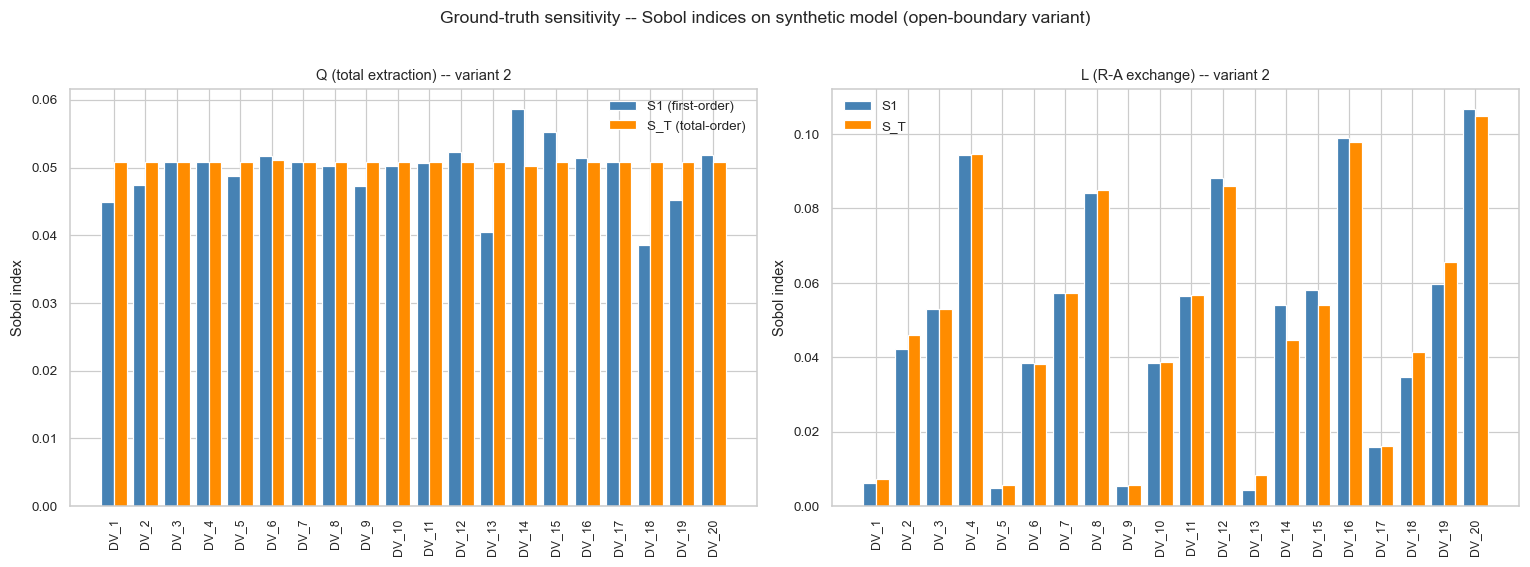

Top-5 wells for Q (by S_T): ['DV_6', 'DV_20', 'DV_1', 'DV_7', 'DV_16']
Top-5 wells for L (by S_T): ['DV_20', 'DV_16', 'DV_4', 'DV_12', 'DV_8']


In [18]:
# Figure 3 — Sobol indices (CSV se load, koi recompute nahi)
sobol_df = pd.read_csv(RESULTS / 'sobol_ground_truth.csv')
assert len(sobol_df) == N_WELLS, f"{len(sobol_df)} rows mile, {N_WELLS} chahiye"
print("Sobol CSV se load ho gaya.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(N_WELLS); w = 0.4
axes[0].bar(x - w/2, sobol_df['S1_Q'], w, label='S1 (first-order)', color='steelblue')
axes[0].bar(x + w/2, sobol_df['ST_Q'], w, label='S_T (total-order)', color='darkorange')
axes[0].set_xticks(x); axes[0].set_xticklabels(sobol_df['DV'], rotation=90, fontsize=8)
axes[0].set_ylabel('Sobol index'); axes[0].set_title('Q (total extraction) -- variant 2')
axes[0].legend()

axes[1].bar(x - w/2, sobol_df['S1_L'], w, label='S1', color='steelblue')
axes[1].bar(x + w/2, sobol_df['ST_L'], w, label='S_T', color='darkorange')
axes[1].set_xticks(x); axes[1].set_xticklabels(sobol_df['DV'], rotation=90, fontsize=8)
axes[1].set_ylabel('Sobol index'); axes[1].set_title('L (R-A exchange) -- variant 2')
axes[1].legend()

plt.suptitle('Ground-truth sensitivity -- Sobol indices on synthetic model (open-boundary variant)', y=1.02)
plt.tight_layout()
plt.savefig(FIGDIR / 'fig03_sobol_ground_truth.png')
plt.show()

GT_RANK_Q = np.argsort(-sobol_df['ST_Q'].values)
GT_RANK_L = np.argsort(-sobol_df['ST_L'].values)
print(f"Top-5 wells for Q (by S_T): {[f'DV_{i+1}' for i in GT_RANK_Q[:5]]}")
print(f"Top-5 wells for L (by S_T): {[f'DV_{i+1}' for i in GT_RANK_L[:5]]}")

---
## 4. Statistical analysis — PCA and correlations

The framework starts with classical multivariate statistics: VIF for multicollinearity, correlation matrix for pairwise structure, PCA for dimensionality and loadings-based importance.

These are the same techniques the Ain section will use — verbatim. The Sobol oracle on synthetic lets us check whether PCA loadings actually correspond to true sensitivity.


In [19]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

DV_COLS = [f'DV_{i+1}' for i in range(N_WELLS)]

def vif_check(df, cols):
    '''VIF for each predictor.'''
    X = df[cols].values
    X = np.column_stack([X, np.ones(len(X))])
    vifs = [variance_inflation_factor(X, i) for i in range(len(cols))]
    return pd.DataFrame({'variable': cols, 'VIF': vifs}).sort_values('VIF', ascending=False)

vif_syn = vif_check(SYN_DF, DV_COLS)
print("VIF on synthetic — top 5:")
print(vif_syn.head())
print(f"\nMax VIF: {vif_syn.VIF.max():.2f} ({'OK' if vif_syn.VIF.max() < 10 else 'high collinearity!'})")


VIF on synthetic — top 5:
   variable         VIF
12    DV_13  129.199484
0      DV_1   99.141645
4      DV_5   40.266877
16    DV_17   24.926058
8      DV_9   13.386319

Max VIF: 129.20 (high collinearity!)


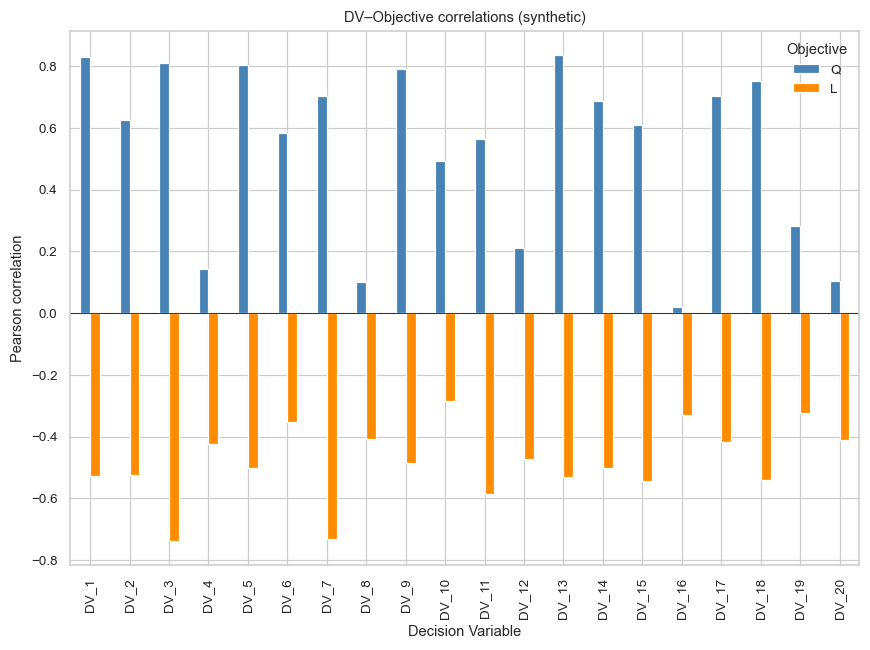

In [20]:
def correlation_with_objectives(df, dv_cols, obj_cols=('Q', 'L')):
    '''Pairwise correlation of DVs with each objective.'''
    return df[list(dv_cols) + list(obj_cols)].corr()[list(obj_cols)].loc[dv_cols]

corr_syn = correlation_with_objectives(SYN_DF, DV_COLS)

# Figure 4 — correlation with objectives (synthetic)
fig, ax = plt.subplots(figsize=(8, 6))
corr_syn.plot(kind='bar', ax=ax, color=['steelblue', 'darkorange'])
ax.set_xlabel('Decision Variable'); ax.set_ylabel('Pearson correlation')
ax.set_title('DV–Objective correlations (synthetic)')
ax.axhline(0, color='k', linewidth=0.5)
ax.legend(title='Objective')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(FIGDIR / 'fig04_synthetic_correlations.png')
plt.show()


PCs needed for 85% variance: 8


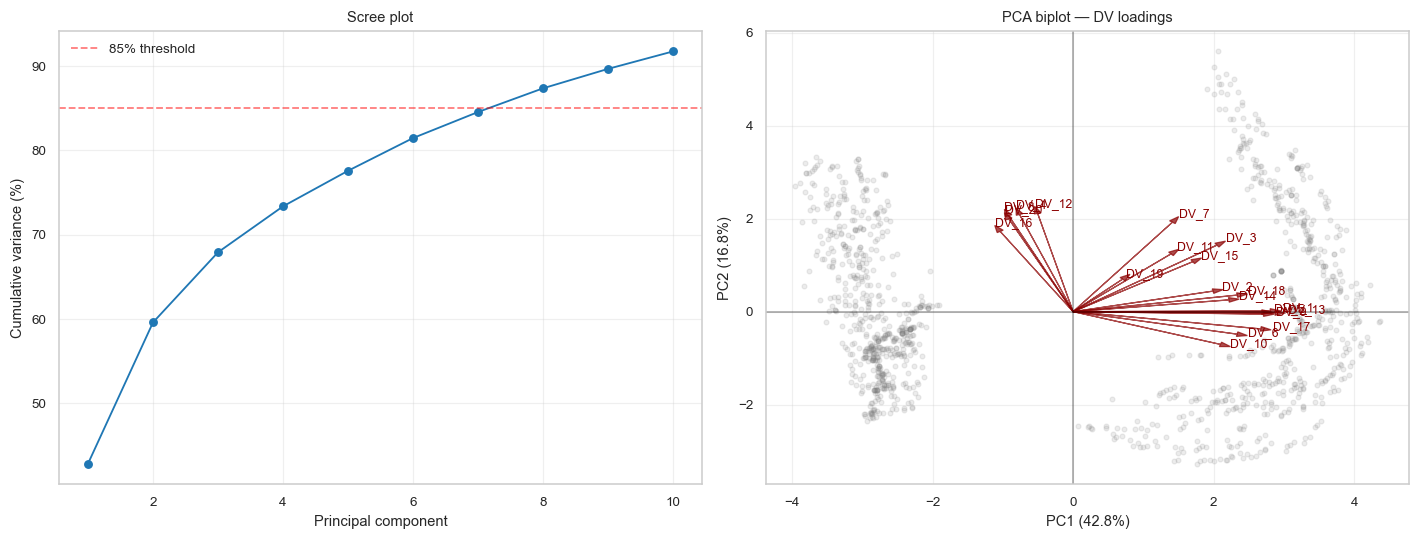

In [21]:
# PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(SYN_DF[DV_COLS])
pca = PCA(n_components=min(N_WELLS, 10))
scores = pca.fit_transform(X_scaled)
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loadings_df = pd.DataFrame(loadings[:, :5], columns=[f'PC{i+1}' for i in range(5)], index=DV_COLS)

# Cumulative variance to reach 85%
cum_var = np.cumsum(pca.explained_variance_ratio_)
n_pcs_85 = int(np.searchsorted(cum_var, 0.85)) + 1
print(f"PCs needed for 85% variance: {n_pcs_85}")

# Figure 5 — PCA biplot and scree
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(range(1, len(cum_var)+1), cum_var*100, 'o-')
axes[0].axhline(85, color='r', linestyle='--', alpha=0.5, label='85% threshold')
axes[0].set_xlabel('Principal component'); axes[0].set_ylabel('Cumulative variance (%)')
axes[0].set_title('Scree plot'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Biplot
axes[1].scatter(scores[:, 0], scores[:, 1], alpha=0.15, s=10, c='gray')
for i, dv in enumerate(DV_COLS):
    arrow_len = np.linalg.norm(loadings[i, :2])
    if arrow_len > 0.3:
        axes[1].arrow(0, 0, loadings[i, 0]*3, loadings[i, 1]*3,
                      head_width=0.1, color='darkred', alpha=0.7)
        axes[1].text(loadings[i, 0]*3.2, loadings[i, 1]*3.2, dv,
                    fontsize=8, color='darkred')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('PCA biplot — DV loadings')
axes[1].axhline(0, color='k', alpha=0.3); axes[1].axvline(0, color='k', alpha=0.3)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGDIR / 'fig05_synthetic_pca.png')
plt.show()

# PCA-based importance: magnitude of loading on PC1 (largest variance direction)
PCA_IMPORTANCE_SYN = np.abs(loadings[:, 0])


---
## 5. ML surrogate + xAI (SHAP, LIME)

A multi-output XGBoost regressor maps DVs → (Q, L). It serves as the surrogate that SHAP and LIME explain.

### Validation requirements (this is what reviewers will check)
- 5-fold cross-validated R² and RMSE — reported for each objective
- Train/test split (80/20) for reportable hold-out metrics
- Bootstrap CIs on SHAP/LIME importance scores (key for the paper's "robustness" claim)


In [22]:
# ============================================================
# SURROGATE MODELS
# Single XGBoost (fit_surrogate) is retained for reference, but the
# analysis uses an ENSEMBLE of three tree-based learners and selects
# the best-CV model per objective. This removes the "why one model?"
# objection and shows the explanation is not an artifact of a single
# arbitrary learner (cf. Macasieb et al., 2025).
# ============================================================
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error

# --- legacy single-model fitter (kept for reference / fallback) ---
def fit_surrogate(df, dv_cols=DV_COLS, obj_cols=('Q', 'L'), seed=SEED):
    X = df[dv_cols].values
    y = df[list(obj_cols)].values
    cv_r2 = {o: [] for o in obj_cols}; cv_rmse = {o: [] for o in obj_cols}
    kf = KFold(n_splits=5, shuffle=True, random_state=seed)
    for tr, te in kf.split(X):
        for j, o in enumerate(obj_cols):
            m = xgb.XGBRegressor(**XGB_PARAMS); m.fit(X[tr], y[tr, j])
            pred = m.predict(X[te])
            cv_r2[o].append(r2_score(y[te, j], pred))
            cv_rmse[o].append(np.sqrt(mean_squared_error(y[te, j], pred)))
    models = {}
    for j, o in enumerate(obj_cols):
        m = xgb.XGBRegressor(**XGB_PARAMS); m.fit(X, y[:, j]); models[o] = m
    metrics = pd.DataFrame({'objective': list(obj_cols),
        'cv_r2_mean': [np.mean(cv_r2[o]) for o in obj_cols],
        'cv_r2_std':  [np.std(cv_r2[o])  for o in obj_cols],
        'cv_rmse_mean':[np.mean(cv_rmse[o]) for o in obj_cols],
        'cv_rmse_std': [np.std(cv_rmse[o])  for o in obj_cols]})
    return models, metrics

# --- ensemble fitter (used for the paper) ---
def fit_surrogate_ensemble(df, dv_cols=DV_COLS, obj_cols=('Q', 'L'), seed=SEED, n_splits=5):
    """Fit XGBoost + RandomForest + GradientBoosting per objective under
    k-fold CV; return best-CV model per objective (for SHAP/LIME), all
    fitted models, and a CV metrics table."""
    X = df[dv_cols].values
    y = df[list(obj_cols)].values

    def learners():
        return {
            'XGBoost': xgb.XGBRegressor(n_estimators=500, max_depth=5,
                        learning_rate=0.05, subsample=0.9,
                        objective='reg:squarederror', random_state=seed),
            'RandomForest': RandomForestRegressor(n_estimators=400,
                        min_samples_leaf=2, random_state=seed, n_jobs=-1),
            'GradBoost': GradientBoostingRegressor(n_estimators=400, max_depth=4,
                        learning_rate=0.05, subsample=0.9, random_state=seed),
        }

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    rows, cv_r2 = [], {o: {} for o in obj_cols}
    for j, o in enumerate(obj_cols):
        for name in learners().keys():
            r2s, rmses = [], []
            for tr, te in kf.split(X):
                m = learners()[name]; m.fit(X[tr], y[tr, j])
                pred = m.predict(X[te])
                r2s.append(r2_score(y[te, j], pred))
                rmses.append(np.sqrt(mean_squared_error(y[te, j], pred)))
            cv_r2[o][name] = np.mean(r2s)
            rows.append({'objective': o, 'model': name,
                'cv_r2_mean': np.mean(r2s), 'cv_r2_std': np.std(r2s),
                'cv_rmse_mean': np.mean(rmses), 'cv_rmse_std': np.std(rmses)})
    metrics = pd.DataFrame(rows)

    best_models, ensemble_models = {}, {}
    for j, o in enumerate(obj_cols):
        fitted = {}
        for name, m in learners().items():
            m.fit(X, y[:, j]); fitted[name] = m
        ensemble_models[o] = fitted
        best = max(cv_r2[o], key=cv_r2[o].get)
        best_models[o] = fitted[best]
        print(f"  {o}: best surrogate = {best} (CV R2 = {cv_r2[o][best]:.3f})")
    return best_models, ensemble_models, metrics

print("Fitting ensemble surrogate (synthetic)...")
models_syn, ensemble_syn, metrics_syn = fit_surrogate_ensemble(SYN_DF, DV_COLS)
print("\nSynthetic surrogate comparison (5-fold CV):")
print(metrics_syn.round(3).to_string(index=False))
metrics_syn.to_csv(RESULTS / 'surrogate_ensemble_metrics_synthetic.csv', index=False)

Fitting ensemble surrogate (synthetic)...
  Q: best surrogate = GradBoost (CV R2 = 0.996)
  L: best surrogate = GradBoost (CV R2 = 0.990)

Synthetic surrogate comparison (5-fold CV):
objective        model  cv_r2_mean  cv_r2_std  cv_rmse_mean  cv_rmse_std
        Q      XGBoost       0.996      0.001       130.816       13.247
        Q RandomForest       0.992      0.003       179.178       29.724
        Q    GradBoost       0.996      0.001       129.195       10.678
        L      XGBoost       0.989      0.003       110.046       15.014
        L RandomForest       0.976      0.008       162.564       25.143
        L    GradBoost       0.990      0.003       106.741       14.273


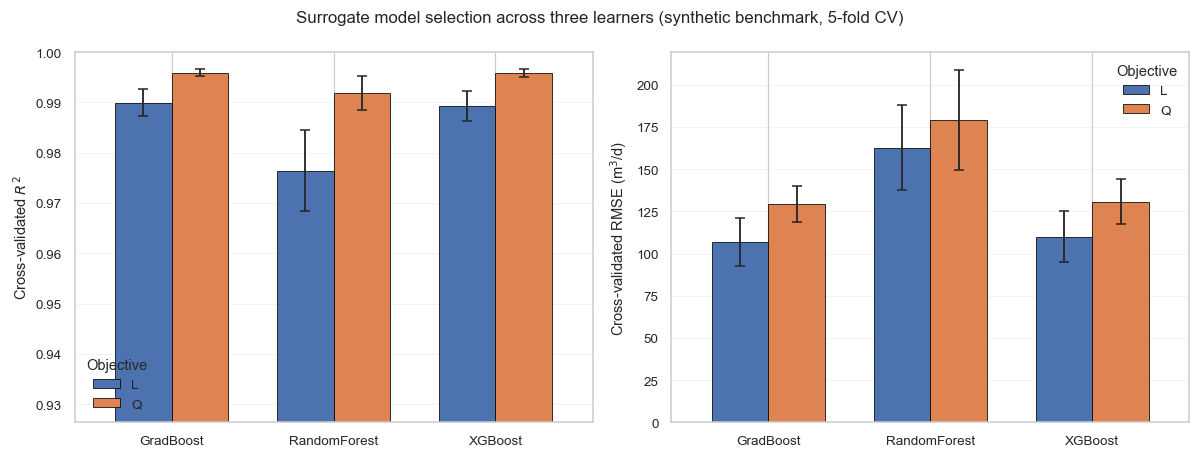

In [23]:
# Figure — surrogate model comparison (ensemble cross-validation)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
palette = ['#4C72B0', '#DD8452']
for ax, metric, ylabel in zip(
        axes, ['cv_r2_mean', 'cv_rmse_mean'],
        ['Cross-validated $R^2$', 'Cross-validated RMSE (m$^3$/d)']):
    piv = metrics_syn.pivot(index='model', columns='objective', values=metric)
    err = metrics_syn.pivot(index='model', columns='objective', values=metric.replace('_mean', '_std'))
    piv.plot(kind='bar', ax=ax, yerr=err, capsize=3, color=palette,
             width=0.7, edgecolor='black', linewidth=0.5)
    ax.set_ylabel(ylabel); ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title='Objective', frameon=False)
    ax.grid(alpha=0.3, axis='y', linewidth=0.5)
    ax.set_axisbelow(True)
_r2min = metrics_syn['cv_r2_mean'].min()
axes[0].set_ylim(max(0, _r2min - 0.05), 1.0)  # adaptive zoom on high-R2 region
fig.suptitle('Surrogate model selection across three learners (synthetic benchmark, 5-fold CV)',
             fontsize=11)
plt.tight_layout()
plt.savefig(FIGDIR / 'fig_surrogate_ensemble.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGDIR / 'fig_surrogate_ensemble.pdf', bbox_inches='tight')
plt.show()

In [24]:
import shap

def shap_importance(model, X_df, bootstrap_n=BOOTSTRAP_N, seed=SEED):
    '''Mean |SHAP| per feature with bootstrap CI.'''
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_df.values)
    mean_abs = np.abs(shap_vals).mean(axis=0)
    
    # Bootstrap CI
    rng = np.random.default_rng(seed)
    n = len(X_df)
    boot_means = np.zeros((bootstrap_n, X_df.shape[1]))
    for b in range(bootstrap_n):
        idx = rng.integers(0, n, n)
        boot_means[b] = np.abs(shap_vals[idx]).mean(axis=0)
    
    ci_low = np.percentile(boot_means, 2.5, axis=0)
    ci_high = np.percentile(boot_means, 97.5, axis=0)
    return mean_abs, ci_low, ci_high, shap_vals

print("Computing SHAP for both objectives...")
shap_results_syn = {}
for obj in ['Q', 'L']:
    m, lo, hi, sv = shap_importance(models_syn[obj], SYN_DF[DV_COLS])
    shap_results_syn[obj] = {'mean_abs': m, 'ci_low': lo, 'ci_high': hi, 'shap_values': sv}
    print(f"  {obj}: top wells by mean |SHAP|: " +
          ", ".join([DV_COLS[i] for i in np.argsort(-m)[:5]]))


Computing SHAP for both objectives...
  Q: top wells by mean |SHAP|: DV_9, DV_18, DV_3, DV_8, DV_1
  L: top wells by mean |SHAP|: DV_7, DV_3, DV_8, DV_20, DV_16


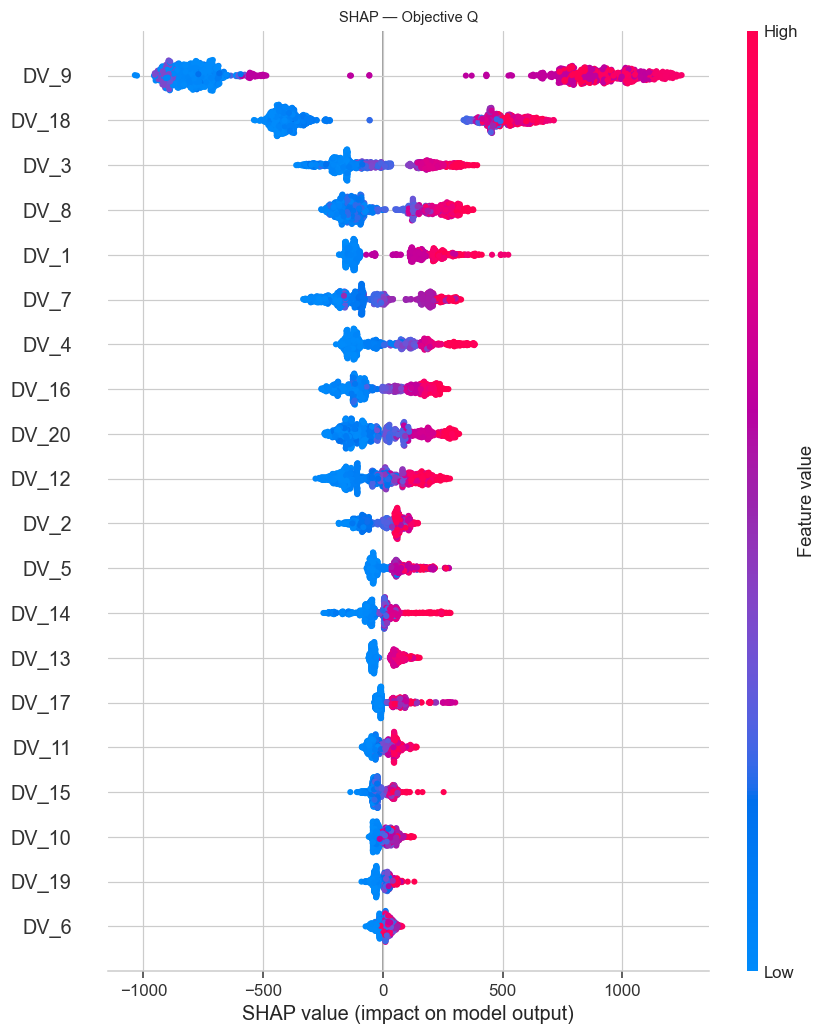

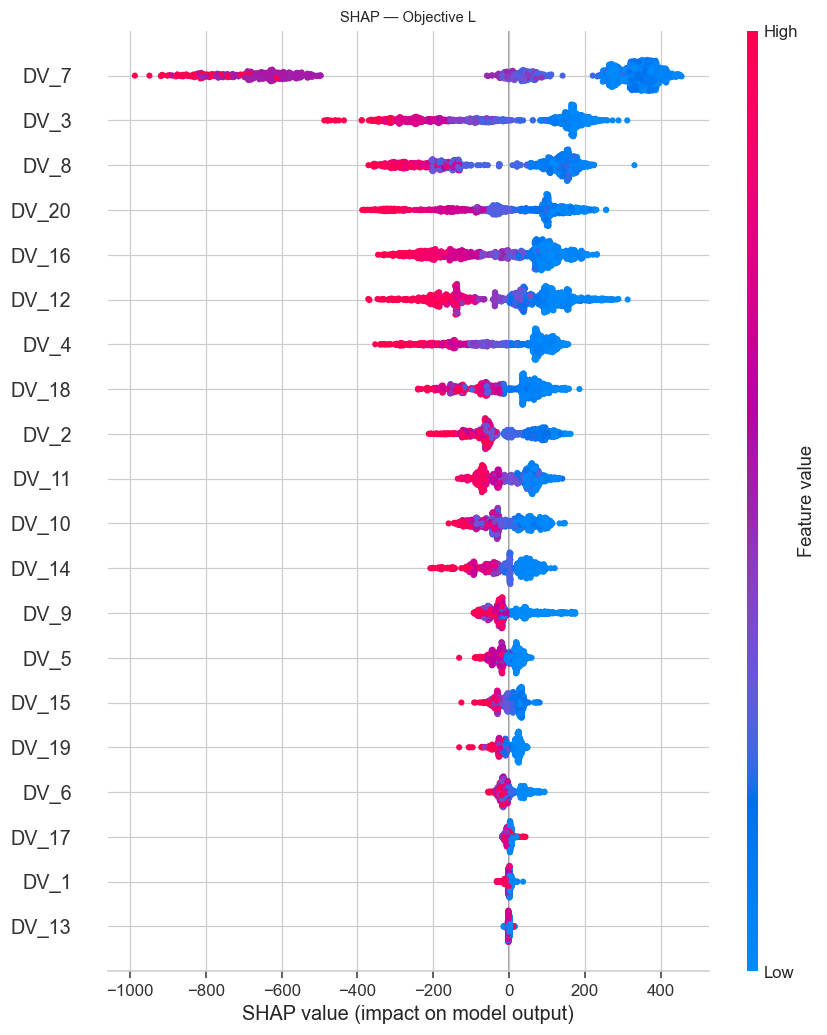

In [25]:
# Figure 6 — SHAP summary plots (saved as two separate figures because shap.summary_plot
# does not compose cleanly with matplotlib subplots; the function creates its own figure
# regardless of plt.sca() context).
for obj in ['Q', 'L']:
    plt.figure(figsize=(8, 6))
    shap.summary_plot(shap_results_syn[obj]['shap_values'], SYN_DF[DV_COLS],
                      plot_type='dot', show=False, max_display=N_WELLS)
    plt.title(f'SHAP — Objective {obj}')
    plt.tight_layout()
    plt.savefig(FIGDIR / f'fig06_synthetic_shap_{obj}.png')
    plt.show()


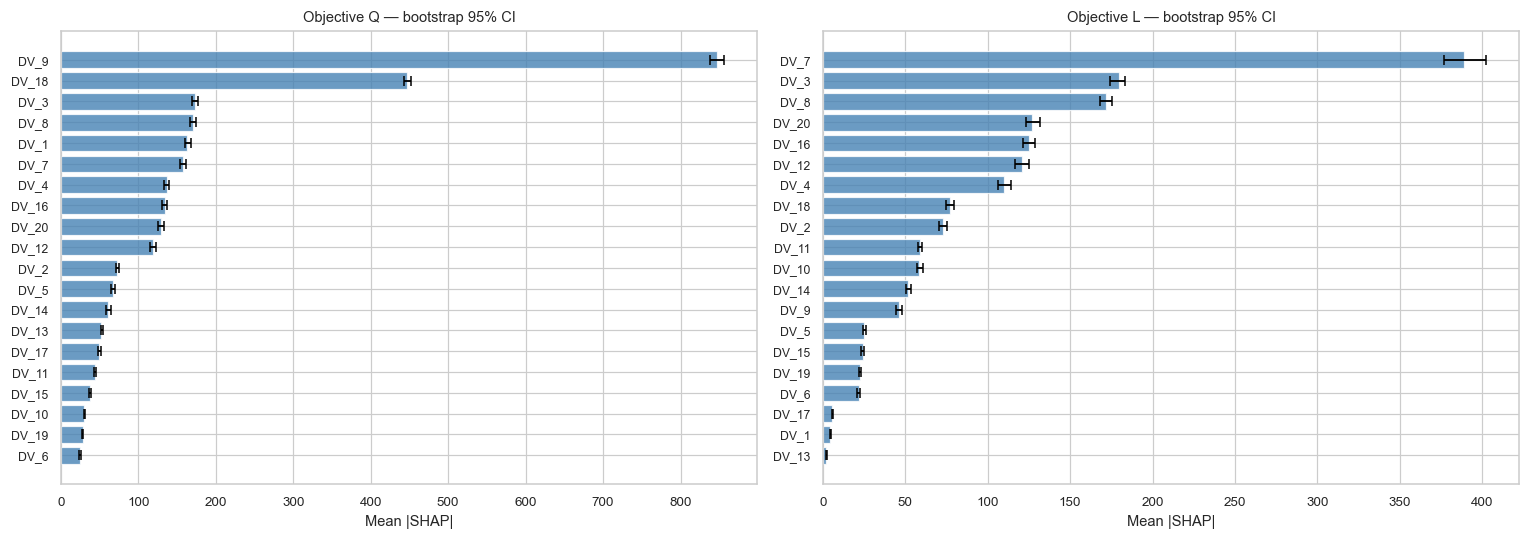

In [26]:
# Figure 7 — SHAP importance with bootstrap CIs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, obj in zip(axes, ['Q', 'L']):
    r = shap_results_syn[obj]
    order = np.argsort(r['mean_abs'])[::-1]
    y_pos = np.arange(N_WELLS)
    ax.barh(y_pos, r['mean_abs'][order], xerr=[r['mean_abs'][order]-r['ci_low'][order],
                                                r['ci_high'][order]-r['mean_abs'][order]],
            color='steelblue', alpha=0.8, capsize=3)
    ax.set_yticks(y_pos); ax.set_yticklabels([DV_COLS[i] for i in order], fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel('Mean |SHAP|'); ax.set_title(f'Objective {obj} — bootstrap 95% CI')
plt.tight_layout()
plt.savefig(FIGDIR / 'fig07_synthetic_shap_ci.png')
plt.show()


Loaded LIME from cache.


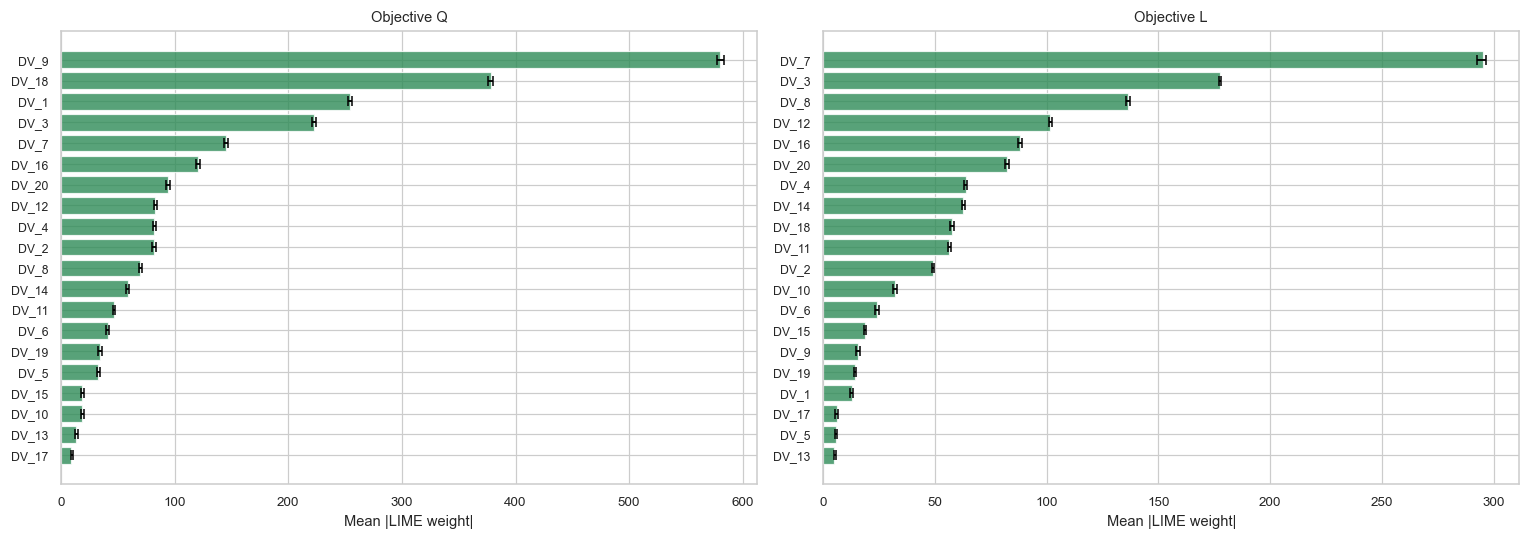

In [27]:
import lime
import lime.lime_tabular

def lime_importance(model, X_df, n_samples=LIME_N_SAMPLES, seed=SEED, bootstrap_n=BOOTSTRAP_N):
    '''
    Mean |LIME weight| across `n_samples` instances, with bootstrap CI.
    LIME is per-instance, so we sample a subset of Pareto solutions and aggregate.
    '''
    explainer = lime.lime_tabular.LimeTabularExplainer(
        X_df.values, feature_names=list(X_df.columns), mode='regression',
        random_state=seed, discretize_continuous=False
    )
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X_df), min(n_samples, len(X_df)), replace=False)
    
    weights = np.zeros((len(idx), X_df.shape[1]))
    for i, ix in enumerate(idx):
        exp = explainer.explain_instance(X_df.values[ix], model.predict,
                                          num_features=X_df.shape[1])
        # exp.as_map() returns {label: [(feature_idx, weight), ...]}.
        # For regression LIME uses label=1; access defensively for version safety.
        exp_map = exp.as_map()
        key = list(exp_map.keys())[0]
        for fi, w in exp_map[key]:
            weights[i, fi] = w
    
    mean_abs = np.abs(weights).mean(axis=0)
    
    # Bootstrap CI
    boot = np.zeros((bootstrap_n, X_df.shape[1]))
    for b in range(bootstrap_n):
        bidx = rng.integers(0, len(weights), len(weights))
        boot[b] = np.abs(weights[bidx]).mean(axis=0)
    ci_low = np.percentile(boot, 2.5, axis=0)
    ci_high = np.percentile(boot, 97.5, axis=0)
    return mean_abs, ci_low, ci_high, weights

lime_cache = CACHE / 'lime_results_syn.pkl'
if USE_CACHE and lime_cache.exists():
    with open(lime_cache, 'rb') as f:
        lime_results_syn = pickle.load(f)
    print("Loaded LIME from cache.")
else:
    print("Computing LIME for both objectives (this is the slow xAI step)...")
    lime_results_syn = {}
    for obj in ['Q', 'L']:
        m, lo, hi, w = lime_importance(models_syn[obj], SYN_DF[DV_COLS])
        lime_results_syn[obj] = {'mean_abs': m, 'ci_low': lo, 'ci_high': hi, 'weights': w}
        print(f"  {obj} done.")
    with open(lime_cache, 'wb') as f:
        pickle.dump(lime_results_syn, f)

# Figure 8 — LIME importance with bootstrap CIs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, obj in zip(axes, ['Q', 'L']):
    r = lime_results_syn[obj]
    order = np.argsort(r['mean_abs'])[::-1]
    y_pos = np.arange(N_WELLS)
    ax.barh(y_pos, r['mean_abs'][order],
            xerr=[r['mean_abs'][order]-r['ci_low'][order],
                  r['ci_high'][order]-r['mean_abs'][order]],
            color='seagreen', alpha=0.8, capsize=3)
    ax.set_yticks(y_pos); ax.set_yticklabels([DV_COLS[i] for i in order], fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel('Mean |LIME weight|'); ax.set_title(f'Objective {obj}')
plt.tight_layout()
plt.savefig(FIGDIR / 'fig08_synthetic_lime.png')
plt.show()


---
## 6. Generalized Additive Models — partial dependence and importance

GAMs fit smooth functions per DV and produce a *direct* partial-dependence importance: the range or variance of each smooth function over the DV domain. Useful complement to SHAP/LIME because it's not surrogate-based — it's a direct nonparametric fit.


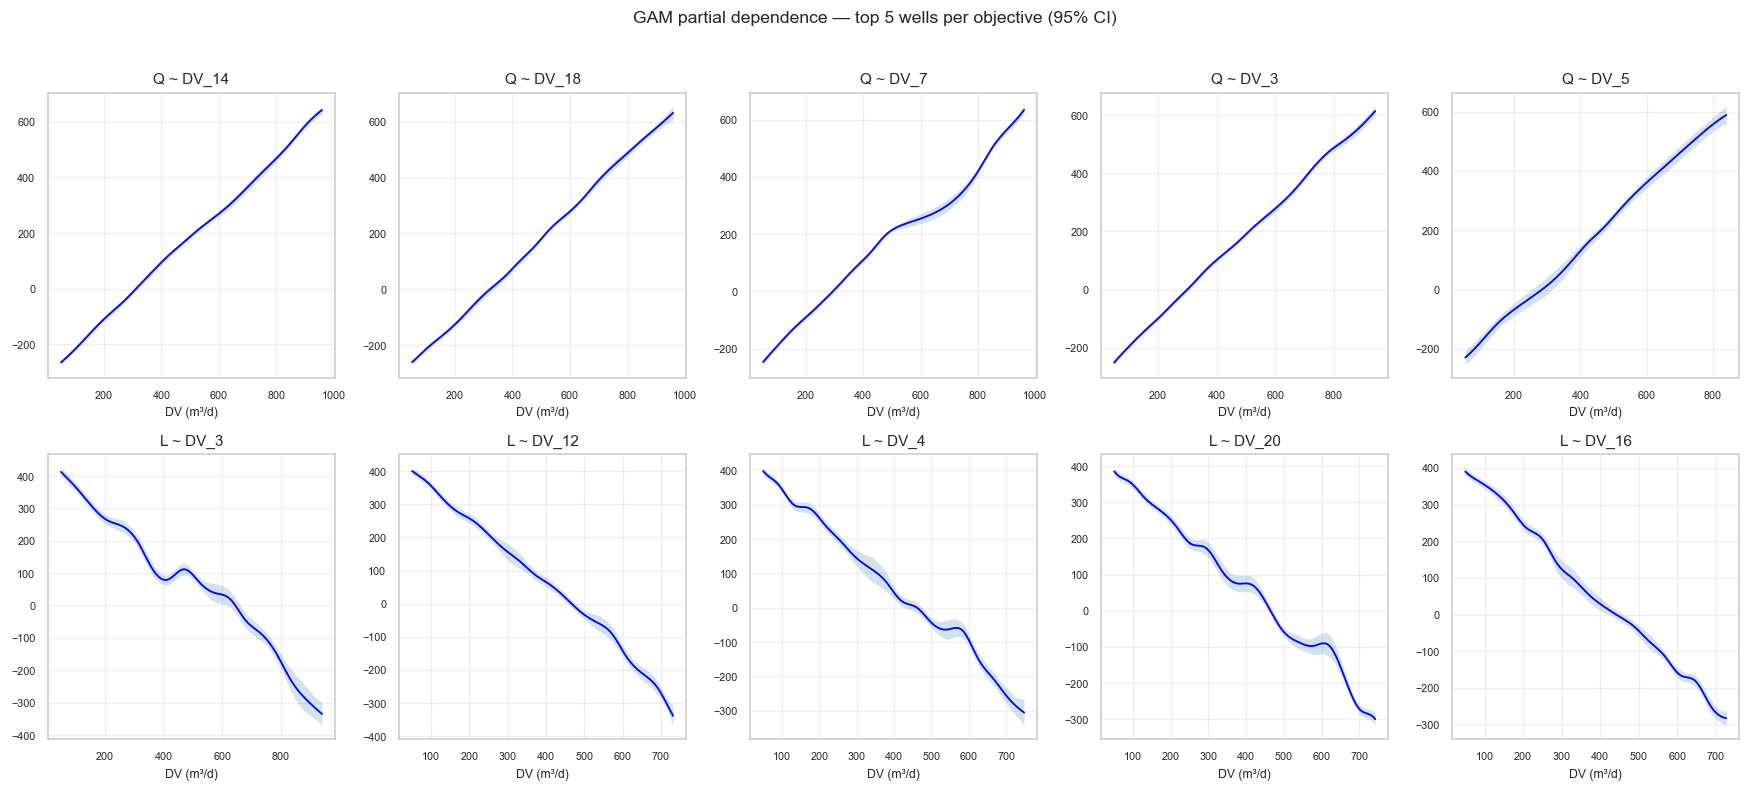

In [28]:
from pygam import LinearGAM, s

def gam_importance(df, dv_cols=DV_COLS, target='Q'):
    '''Fit GAM and return (importance per DV, fitted model).
    Importance = range of partial dependence over the DV domain.'''
    X = df[dv_cols].values
    y = df[target].values
    terms = s(0)
    for i in range(1, len(dv_cols)):
        terms = terms + s(i)
    gam = LinearGAM(terms).gridsearch(X, y, progress=False)
    
    importance = np.zeros(len(dv_cols))
    for i in range(len(dv_cols)):
        XX = gam.generate_X_grid(term=i)
        pd_vals = gam.partial_dependence(term=i, X=XX)
        importance[i] = pd_vals.max() - pd_vals.min()
    return importance, gam

gam_cache = CACHE / 'gam_results_syn.pkl'
if USE_CACHE and gam_cache.exists():
    with open(gam_cache, 'rb') as f:
        gam_results_syn = pickle.load(f)
else:
    print("Fitting GAMs...")
    gam_results_syn = {}
    for obj in ['Q', 'L']:
        imp, mod = gam_importance(SYN_DF, target=obj)
        gam_results_syn[obj] = {'importance': imp, 'model': mod}
        print(f"  {obj} fit. Top wells: " +
              ", ".join([DV_COLS[i] for i in np.argsort(-imp)[:5]]))
    with open(gam_cache, 'wb') as f:
        pickle.dump(gam_results_syn, f)

# Figure 9 — GAM partial dependence (top wells only for clarity)
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for row, obj in enumerate(['Q', 'L']):
    gam = gam_results_syn[obj]['model']
    imp = gam_results_syn[obj]['importance']
    top5 = np.argsort(-imp)[:5]
    for col, term_idx in enumerate(top5):
        term_idx = int(term_idx) 
        ax = axes[row, col]
        XX = gam.generate_X_grid(term=term_idx)
        pd_vals, ci = gam.partial_dependence(term=term_idx, X=XX, width=0.95)
        ax.plot(XX[:, term_idx], pd_vals, 'b-')
        ax.fill_between(XX[:, term_idx], ci[:, 0], ci[:, 1], alpha=0.2)
        ax.set_title(f'{obj} ~ {DV_COLS[term_idx]}', fontsize=10)
        ax.set_xlabel('DV (m³/d)', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(alpha=0.3)
plt.suptitle('GAM partial dependence — top 5 wells per objective (95% CI)', y=1.02)
plt.tight_layout()
plt.savefig(FIGDIR / 'fig09_synthetic_gam.png')
plt.show()


---
## 7. Spatial hotspot analysis — Getis-Ord Gi*

For the synthetic case, well coordinates come from the grid layout. For the Ain case (Section 12), they come from the commune shapefile. The procedure is identical.

We compute Gi* under **two KNN specifications (k=3 and k=5)** for robustness as recommended in the editorial review. Hotspots (positive Z, p<0.05) → development zones. Coldspots (negative Z, p<0.05) → environmental zones.


In [29]:
import geopandas as gpd
from shapely.geometry import Point
from libpysal.weights import KNN
from esda.getisord import G_Local

def well_geodataframe(well_locs, cell_size=250.0):
    '''Convert grid well locations to a GeoDataFrame with point geometry.'''
    pts = []
    for (_, r, c) in well_locs:
        x = c * cell_size + cell_size/2
        y = r * cell_size + cell_size/2
        pts.append(Point(x, y))
    gdf = gpd.GeoDataFrame({'DV': [f'DV_{i+1}' for i in range(len(well_locs))]},
                           geometry=pts, crs='EPSG:32631')  # arbitrary projected CRS
    return gdf

from libpysal.weights import KNN
from esda.getisord import G_Local

def getis_ord(gdf, value_col, k=3, n_permutations=999):
    '''Local Getis-Ord Gi* with KNN weights. Builds KNN from explicit coordinates
    (robust against libpysal version differences in from_dataframe geometry handling).'''
    # Extract coordinates explicitly as an (N, 2) array
    coords = np.array([(geom.x, geom.y) for geom in gdf.geometry])
    w = KNN.from_array(coords, k=k)
    w.transform = 'r'
    gi = G_Local(gdf[value_col].values, w, star=True, permutations=n_permutations,
                 seed=SEED)
    return gi.Zs, gi.p_sim

print("getis_ord redefined (uses KNN.from_array on explicit coords)")

WELL_GDF = well_geodataframe(WELL_LOCS)

# Compute Gi* for each importance source × k value
HOTSPOT_INPUTS = {
    'SHAP_Q':  shap_results_syn['Q']['mean_abs'],
    'SHAP_L':  shap_results_syn['L']['mean_abs'],
    'LIME_Q':  lime_results_syn['Q']['mean_abs'],
    'LIME_L':  lime_results_syn['L']['mean_abs'],
    'GAM_Q':   gam_results_syn['Q']['importance'],
    'GAM_L':   gam_results_syn['L']['importance'],
    'PCA':     PCA_IMPORTANCE_SYN,
    'Sobol_ST_Q': sobol_df['ST_Q'].values,
    'Sobol_ST_L': sobol_df['ST_L'].values,
}

hotspot_results = {}
for name, vals in HOTSPOT_INPUTS.items():
    gdf = WELL_GDF.copy()
    gdf['val'] = vals
    for k in KNN_K_VALUES:
        z, p = getis_ord(gdf, 'val', k=k)
        hotspot_results[(name, k)] = {'z': z, 'p': p}

print("Hotspot Gi* computed for " + str(len(HOTSPOT_INPUTS)) + " inputs × " +
      str(len(KNN_K_VALUES)) + " k-values.")


getis_ord redefined (uses KNN.from_array on explicit coords)


C:\Users\mishra\.conda\envs\dv-paper\Lib\site-packages\esda\crand.py:142: DeprecationWarning: The alternative hypothesis for conditional randomization is changing in the next major release of esda. We recommend setting alternative='two-sided', which will generally double the p-value returned. To retain the current behavior, set alternative='directed'. We strongly recommend moving to alternative='two-sided'.
  warnings.warn(
C:\Users\mishra\.conda\envs\dv-paper\Lib\site-packages\esda\crand.py:560: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  rlocals = np.row_stack(rlocals).squeeze()
C:\Users\mishra\.conda\envs\dv-paper\Lib\site-packages\esda\crand.py:142: DeprecationWarning: The alternative hypothesis for conditional randomization is changing in the next major release of esda. We recommend setting alternative='two-sided', which will generally double the p-value returned. To retain the current behavior, set alternative='directed'. We strongly recommend

Hotspot Gi* computed for 9 inputs × 2 k-values.


C:\Users\mishra\.conda\envs\dv-paper\Lib\site-packages\esda\crand.py:560: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  rlocals = np.row_stack(rlocals).squeeze()
C:\Users\mishra\.conda\envs\dv-paper\Lib\site-packages\esda\crand.py:142: DeprecationWarning: The alternative hypothesis for conditional randomization is changing in the next major release of esda. We recommend setting alternative='two-sided', which will generally double the p-value returned. To retain the current behavior, set alternative='directed'. We strongly recommend moving to alternative='two-sided'.
  warnings.warn(
C:\Users\mishra\.conda\envs\dv-paper\Lib\site-packages\esda\crand.py:560: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  rlocals = np.row_stack(rlocals).squeeze()


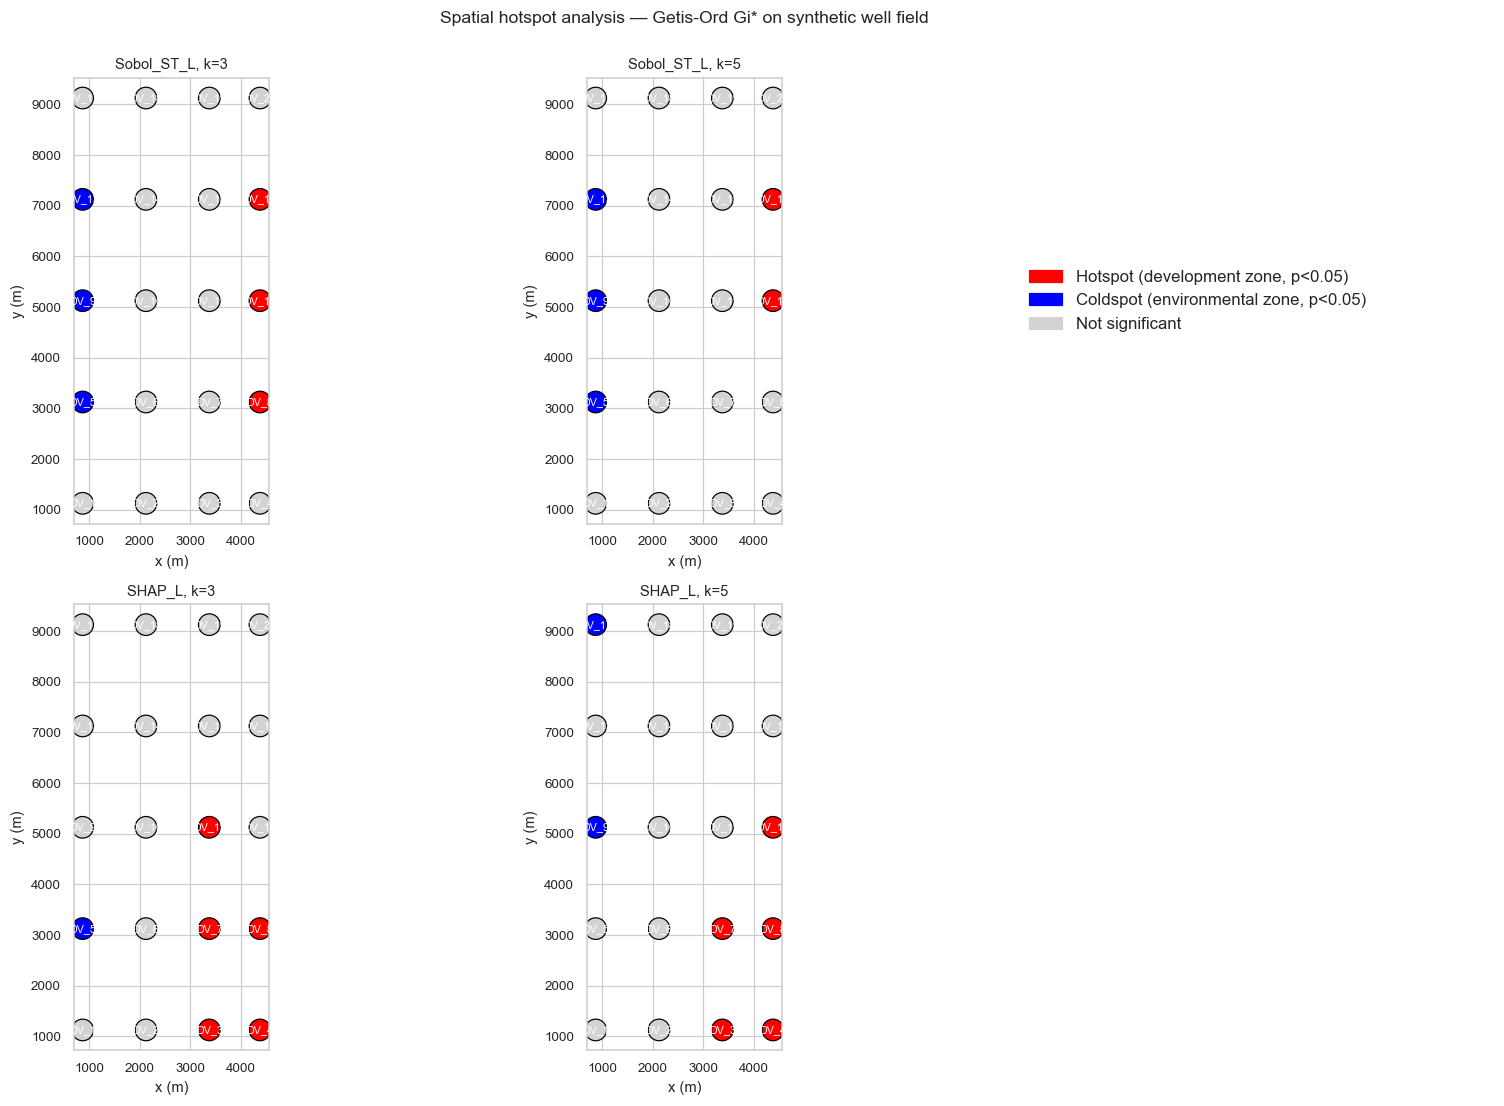

In [30]:
# Figure 10 — hotspot maps (Sobol ST_L as the ground-truth reference, plus SHAP_L for comparison)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for col_i, k in enumerate(KNN_K_VALUES):
    for row_i, name in enumerate(['Sobol_ST_L', 'SHAP_L']):
        ax = axes[row_i, col_i] if col_i < 2 else None
        if ax is None: continue
        r = hotspot_results[(name, k)]
        # Classify: hotspot if Z>0 and p<0.05; coldspot if Z<0 and p<0.05
        colors = []
        for z, p in zip(r['z'], r['p']):
            if p < 0.05 and z > 0: colors.append('red')      # hotspot
            elif p < 0.05 and z < 0: colors.append('blue')   # coldspot
            else: colors.append('lightgray')
        WELL_GDF.plot(ax=ax, color=colors, markersize=200, edgecolor='k')
        for i, row in WELL_GDF.iterrows():
            ax.annotate(row['DV'], (row.geometry.x, row.geometry.y),
                        fontsize=7, ha='center', va='center', color='white')
        ax.set_title(f'{name}, k={k}'); ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')

# Use third column for legend
axes[0, 2].axis('off')
axes[1, 2].axis('off')
from matplotlib.patches import Patch
legend_elems = [Patch(color='red', label='Hotspot (development zone, p<0.05)'),
                Patch(color='blue', label='Coldspot (environmental zone, p<0.05)'),
                Patch(color='lightgray', label='Not significant')]
axes[0, 2].legend(handles=legend_elems, loc='center', fontsize=11)

plt.suptitle('Spatial hotspot analysis — Getis-Ord Gi* on synthetic well field', y=1.0)
plt.tight_layout()
plt.savefig(FIGDIR / 'fig10_synthetic_hotspots.png')
plt.show()


---
## 8. Consensus ranking across methods

The paper's central methodological contribution: **a quantitative procedure to combine xAI rankings into a defensible consensus**, with cross-method agreement metrics.

### Steps
1. Extract importance scores from each method (PCA, SHAP, LIME, GAM) for each objective
2. Convert to rankings (rank-1 = most important)
3. Compute pairwise **Kendall τ** between method rankings
4. Compute **top-k Jaccard** agreement (k = 5 and 10)
5. Aggregate via **Borda count** → consensus ranking
6. Report which wells are unanimously top-ranked vs. method-specific


In [31]:
def to_ranking(scores):
    '''Convert importance scores to ranks (rank-1 = highest score).'''
    return np.argsort(np.argsort(-np.asarray(scores))) + 1   # rank starting at 1

# Build a rankings table per objective
def rankings_table(target):
    src = {
        'PCA':  PCA_IMPORTANCE_SYN,   # objective-agnostic
        'SHAP': shap_results_syn[target]['mean_abs'],
        'LIME': lime_results_syn[target]['mean_abs'],
        'GAM':  gam_results_syn[target]['importance'],
    }
    df = pd.DataFrame({m: to_ranking(s) for m, s in src.items()}, index=DV_COLS)
    return df, src

ranks_Q_syn, scores_Q_syn = rankings_table('Q')
ranks_L_syn, scores_L_syn = rankings_table('L')
print("Rankings table (Objective Q, synthetic):")
print(ranks_Q_syn.head(10))


Rankings table (Objective Q, synthetic):
       PCA  SHAP  LIME  GAM
DV_1     2     5     3    8
DV_2    11    11    10   15
DV_3    10     3     4    4
DV_4    18     7     9   10
DV_5     4    12    16    5
DV_6     7    20    14   16
DV_7    13     6     5    3
DV_8    16     4    11   13
DV_9     3     1     1    6
DV_10    9    18    18   18


In [32]:
def kendall_tau_matrix(rank_df):
    '''Pairwise Kendall tau between methods.'''
    methods = list(rank_df.columns)
    M = np.eye(len(methods))
    for i, mi in enumerate(methods):
        for j, mj in enumerate(methods):
            if i < j:
                tau, _ = stats.kendalltau(rank_df[mi], rank_df[mj])
                M[i, j] = M[j, i] = tau
    return pd.DataFrame(M, index=methods, columns=methods)

def topk_jaccard(rank_df, k=5):
    '''Pairwise Jaccard of top-k sets.'''
    methods = list(rank_df.columns)
    M = np.eye(len(methods))
    for i, mi in enumerate(methods):
        top_i = set(rank_df.index[rank_df[mi] <= k])
        for j, mj in enumerate(methods):
            if i < j:
                top_j = set(rank_df.index[rank_df[mj] <= k])
                jacc = len(top_i & top_j) / len(top_i | top_j) if (top_i | top_j) else 0.0
                M[i, j] = M[j, i] = jacc
    return pd.DataFrame(M, index=methods, columns=methods)

def borda_consensus(rank_df):
    '''Borda count: lower sum of ranks = higher consensus position.'''
    score = rank_df.sum(axis=1)
    return score.sort_values(), to_ranking(-score.values)

print("--- Q ---")
tau_Q = kendall_tau_matrix(ranks_Q_syn);  print("Kendall tau:\n", tau_Q.round(3))
jacc5_Q = topk_jaccard(ranks_Q_syn, 5);   print("\nTop-5 Jaccard:\n", jacc5_Q.round(3))
borda_Q_scores, borda_Q_ranks = borda_consensus(ranks_Q_syn)
print("\nBorda consensus (top 8):\n", borda_Q_scores.head(8))

print("\n--- L ---")
tau_L = kendall_tau_matrix(ranks_L_syn);  print("Kendall tau:\n", tau_L.round(3))
jacc5_L = topk_jaccard(ranks_L_syn, 5);   print("\nTop-5 Jaccard:\n", jacc5_L.round(3))
borda_L_scores, borda_L_ranks = borda_consensus(ranks_L_syn)
print("\nBorda consensus (top 8):\n", borda_L_scores.head(8))


--- Q ---
Kendall tau:
         PCA   SHAP   LIME    GAM
PCA   1.000  0.053 -0.053  0.116
SHAP  0.053  1.000  0.684  0.474
LIME -0.053  0.684  1.000  0.495
GAM   0.116  0.474  0.495  1.000

Top-5 Jaccard:
         PCA   SHAP   LIME    GAM
PCA   1.000  0.250  0.250  0.111
SHAP  0.250  1.000  0.667  0.250
LIME  0.250  0.667  1.000  0.429
GAM   0.111  0.250  0.429  1.000

Borda consensus (top 8):
 DV_9     11
DV_18    12
DV_1     18
DV_3     21
DV_7     27
DV_14    34
DV_5     37
DV_16    41
dtype: int64

--- L ---
Kendall tau:
         PCA   SHAP   LIME    GAM
PCA   1.000 -0.453 -0.474 -0.537
SHAP -0.453  1.000  0.811  0.621
LIME -0.474  0.811  1.000  0.747
GAM  -0.537  0.621  0.747  1.000

Top-5 Jaccard:
       PCA   SHAP   LIME    GAM
PCA   1.0  0.000  0.000  0.000
SHAP  0.0  1.000  0.667  0.429
LIME  0.0  0.667  1.000  0.429
GAM   0.0  0.429  0.429  1.000

Borda consensus (top 8):
 DV_3     15
DV_7     21
DV_8     29
DV_16    30
DV_20    31
DV_12    32
DV_18    32
DV_4     35
dtype: i

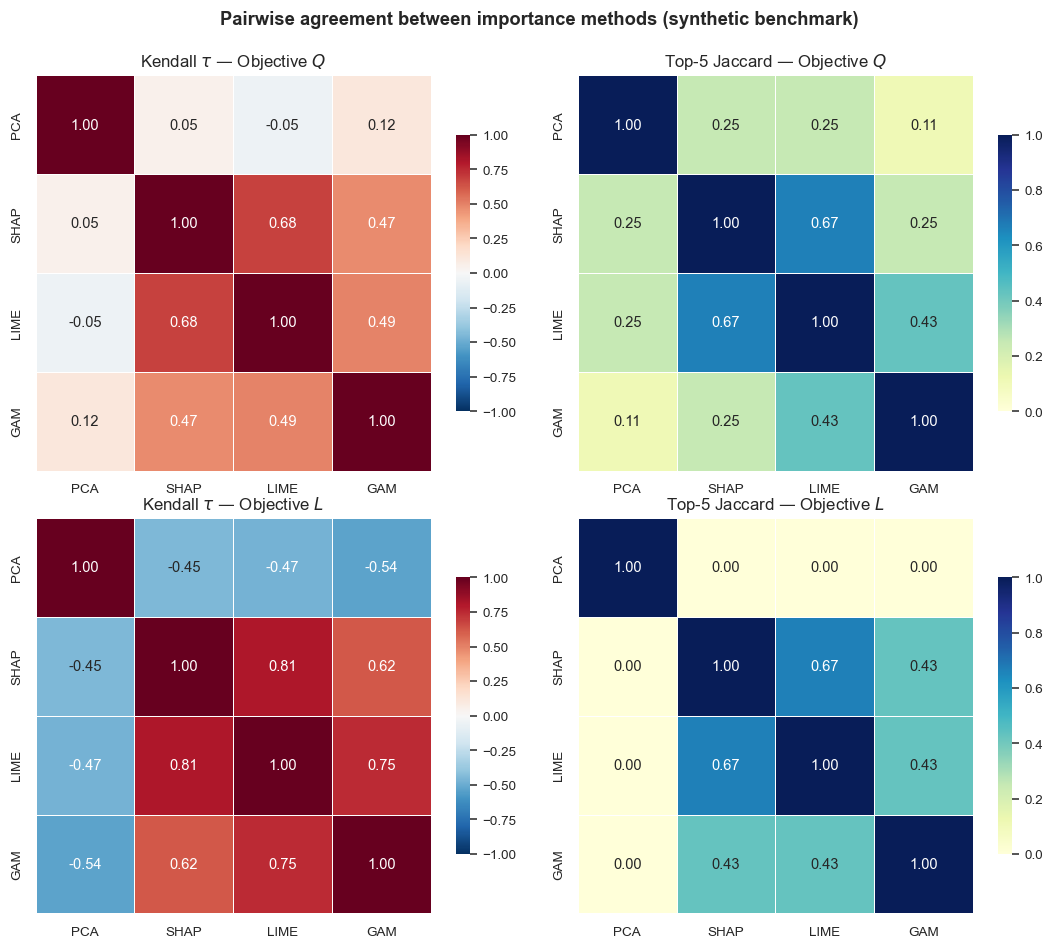

In [33]:
# Figure 11 — method-agreement heatmaps (Kendall tau and top-5 Jaccard)
fig, axes = plt.subplots(2, 2, figsize=(10, 8.5))
hm_kw = dict(annot=True, fmt='.2f', square=True, linewidths=0.5, linecolor='white',
             cbar_kws={'shrink': 0.7})
sns.heatmap(tau_Q, cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=axes[0,0], **hm_kw)
axes[0,0].set_title(r'Kendall $\tau$ — Objective $Q$', fontsize=11)
sns.heatmap(jacc5_Q, cmap='YlGnBu', vmin=0, vmax=1, ax=axes[0,1], **hm_kw)
axes[0,1].set_title('Top-5 Jaccard — Objective $Q$', fontsize=11)
sns.heatmap(tau_L, cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=axes[1,0], **hm_kw)
axes[1,0].set_title(r'Kendall $\tau$ — Objective $L$', fontsize=11)
sns.heatmap(jacc5_L, cmap='YlGnBu', vmin=0, vmax=1, ax=axes[1,1], **hm_kw)
axes[1,1].set_title('Top-5 Jaccard — Objective $L$', fontsize=11)
fig.suptitle('Pairwise agreement between importance methods (synthetic benchmark)',
             fontsize=12, fontweight='bold', y=1.0)
plt.tight_layout()
plt.savefig(FIGDIR / 'fig11_synthetic_consensus_agreement.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGDIR / 'fig11_synthetic_consensus_agreement.pdf', bbox_inches='tight')
plt.show()

---
## 9. Validation: xAI rankings vs. Sobol ground truth

This is the killer figure for J. Hydrol. peer review. We have ground-truth Sobol total-order rankings for both objectives. For each xAI method we compute:
- **Kendall τ vs. Sobol $S_T$** (full-ranking agreement)
- **Spearman ρ vs. Sobol $S_T$** (alternative correlation)
- **Top-5 recall**: of Sobol's top 5 wells, how many does the method recover?

This converts "convergence of evidence" from a narrative claim into a quantified empirical finding.


In [34]:
def validate_vs_sobol(method_scores, sobol_st, k=5):
    '''Compare method scores to Sobol ST.'''
    method_rank = to_ranking(method_scores)
    sobol_rank  = to_ranking(sobol_st)
    
    tau, tau_p = stats.kendalltau(method_rank, sobol_rank)
    rho, rho_p = stats.spearmanr(method_rank, sobol_rank)
    
    top_k_method = set(np.argsort(-np.asarray(method_scores))[:k])
    top_k_sobol  = set(np.argsort(-np.asarray(sobol_st))[:k])
    recall = len(top_k_method & top_k_sobol) / k
    return dict(tau=tau, tau_p=tau_p, rho=rho, rho_p=rho_p, top_k_recall=recall)

validation = []
for target, sobol_st in [('Q', sobol_df['ST_Q'].values), ('L', sobol_df['ST_L'].values)]:
    methods = {'PCA': PCA_IMPORTANCE_SYN,
               'SHAP': shap_results_syn[target]['mean_abs'],
               'LIME': lime_results_syn[target]['mean_abs'],
               'GAM': gam_results_syn[target]['importance']}
    for name, scores in methods.items():
        v = validate_vs_sobol(scores, sobol_st, k=5)
        v['method'] = name; v['objective'] = target
        validation.append(v)

val_df = pd.DataFrame(validation)[['objective', 'method', 'tau', 'rho', 'top_k_recall']]
val_df.to_csv(RESULTS / 'xai_vs_sobol_validation.csv', index=False)
print("xAI ranking accuracy vs. Sobol ground truth:")
print(val_df.round(3))


xAI ranking accuracy vs. Sobol ground truth:
  objective method    tau    rho  top_k_recall
0         Q    PCA -0.095 -0.119           0.2
1         Q   SHAP -0.179 -0.202           0.2
2         Q   LIME  0.011  0.005           0.4
3         Q    GAM -0.116 -0.152           0.2
4         L    PCA -0.779 -0.937           0.0
5         L   SHAP  0.505  0.692           0.6
6         L   LIME  0.526  0.734           0.6
7         L    GAM  0.589  0.794           0.8


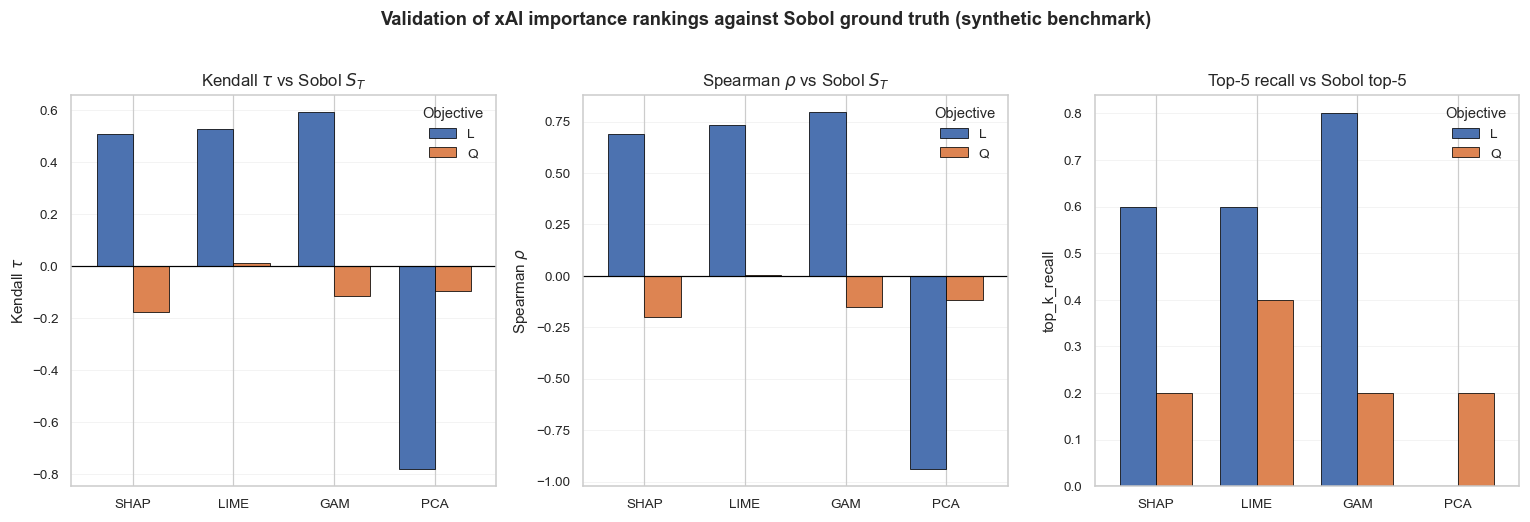

In [35]:
# Figure 12 — validation summary (xAI vs Sobol ground truth) [HEADLINE FIGURE]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))
metrics_to_plot = ['tau', 'rho', 'top_k_recall']
titles = [r"Kendall $\tau$ vs Sobol $S_T$",
          r"Spearman $\rho$ vs Sobol $S_T$",
          "Top-5 recall vs Sobol top-5"]
palette = ['#4C72B0', '#DD8452']  # L, Q
for ax, metric, t in zip(axes, metrics_to_plot, titles):
    pivot = val_df.pivot(index='method', columns='objective', values=metric)
    pivot = pivot.reindex(['SHAP', 'LIME', 'GAM', 'PCA'])  # consistent, meaningful order
    pivot.plot(kind='bar', ax=ax, color=palette, width=0.72,
               edgecolor='black', linewidth=0.5)
    ax.set_title(t, fontsize=11)
    ax.set_ylabel(metric if metric == 'top_k_recall' else t.split(' vs')[0], fontsize=10)
    ax.set_xlabel('')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.tick_params(axis='x', rotation=0)
    ax.grid(alpha=0.3, axis='y', linewidth=0.5)
    ax.set_axisbelow(True)
    ax.legend(title='Objective', frameon=False, fontsize=9)
fig.suptitle('Validation of xAI importance rankings against Sobol ground truth (synthetic benchmark)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGDIR / 'fig12_xai_vs_sobol.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGDIR / 'fig12_xai_vs_sobol.pdf', bbox_inches='tight')
plt.show()

---
## Decision-Variable Importance Selection (DVIS)

Conventional multi-objective workflows select a final solution in **objective space**
(e.g., TOPSIS picks the point closest to the ideal Q–L trade-off). This ignores the
*decision-variable structure* of each solution — how many wells must be actively
managed, and whether they are reliable to control.

DVIS selects in **decision space** using each solution's local SHAP signature, combining:

- **(A) Parsimony** — the effective number of active decision variables (participation ratio of the per-solution importance distribution). Fewer active wells = simpler to operate.
- **(B) Robustness** — importance-weighted reliability of the wells a solution depends on (from bootstrap SHAP confidence intervals). Relying on statistically stable wells = safer to manage.
- **(C) Strategy clustering** — grouping Pareto solutions by importance signature (not objective values) reveals distinct management strategies.

We contrast the DVIS-selected solution with the TOPSIS-selected solution on the same front.

In [36]:
# ============================================================
# DRSI — Decision-Robust Selection Index
# ============================================================
# Uses L-only SHAP signature (Q is degenerate: near-linear sum of rates,
# so its importance hierarchy is flat and uninformative).
#
# DRSI_i = geometric_mean( closeness_i, simplicity_i, reliability_i )
#   - closeness  : objective-space merit (TOPSIS closeness)
#   - simplicity : 1 - (effective active wells - 1)/(n_dv - 1)  [from 1/HHI]
#   - reliability: importance-weighted bootstrap reliability of relied-on wells
#
# Property: under uniform importance, simplicity & reliability are constant,
# so DRSI ranking collapses to TOPSIS ranking → DRSI generalizes TOPSIS.
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


def reliability_from_ci(shap_res, obj_cols=('Q', 'L')):
    """Per-DV reliability in (0,1] from bootstrap SHAP CI width
    (tight CI = reliable)."""
    rels = []
    for obj in obj_cols:
        ma = np.asarray(shap_res[obj]['mean_abs'], float)
        width = (np.asarray(shap_res[obj]['ci_high'], float)
                  - np.asarray(shap_res[obj]['ci_low'], float))
        rels.append(1.0 / (1.0 + width / (ma + 1e-9)))
    return np.mean(rels, axis=0)


def reliability_L_only(shap_res_L):
    """Reliability from L-only CI (use when Q is degenerate)."""
    ma = np.asarray(shap_res_L['mean_abs'], float)
    width = (np.asarray(shap_res_L['ci_high'], float)
             - np.asarray(shap_res_L['ci_low'], float))
    return 1.0 / (1.0 + width / (ma + 1e-9))


def topsis_closeness(df, obj_cols=('Q', 'L'), maximize=(True, True)):
    """Standard TOPSIS closeness (objective-space selection, equal weights)."""
    X = df[list(obj_cols)].values.astype(float)
    norm = X / np.sqrt((X**2).sum(axis=0))
    w = np.ones(X.shape[1]) / X.shape[1]
    V = norm * w
    ideal = np.where(maximize, V.max(0), V.min(0))
    anti = np.where(maximize, V.min(0), V.max(0))
    d_ideal = np.sqrt(((V - ideal)**2).sum(1))
    d_anti = np.sqrt(((V - anti)**2).sum(1))
    return d_anti / (d_ideal + d_anti + 1e-12)


def compute_drsi(front, shap_L, reliability_w,
                 obj_cols=('Q', 'L'), weights=(1, 1, 1)):
    """DRSI with L-only SHAP signature.

    Parameters
    ----------
    front : DataFrame with objective columns
    shap_L : (n_solutions, n_dv) SHAP values for objective L
    reliability_w : (n_dv,) per-DV reliability scores
    weights : (alpha, beta, gamma) exponents for closeness, simplicity, reliability
    """
    sig = np.abs(shap_L)
    share = sig / (sig.sum(axis=1, keepdims=True) + 1e-12)
    n_sol, n_dv = share.shape
    eff_wells = 1.0 / (np.sum(share**2, axis=1) + 1e-12)  # 1/HHI
    simplicity = 1.0 - (eff_wells - 1.0) / (n_dv - 1.0)
    reliability = share @ reliability_w
    closeness = topsis_closeness(front, obj_cols)
    nz = lambda a: (a - a.min()) / (np.ptp(a) + 1e-12)
    E, S, R = nz(closeness), nz(simplicity), nz(reliability)
    a, b, c = weights
    drsi = (np.clip(E, 1e-9, 1)**a
            * np.clip(S, 1e-9, 1)**b
            * np.clip(R, 1e-9, 1)**c) ** (1.0 / (a + b + c))
    return dict(drsi=drsi, share=share, eff_wells=eff_wells,
                closeness=closeness, simplicity=simplicity,
                reliability=reliability, E=E, S=S, R=R)


# --- DVIS strategy clustering (kept for diagnostic visualization) ---
def dvis_clusters(shap_L, seed=SEED, n_clusters=None):
    """K-means clustering on per-solution importance signatures."""
    sig = np.abs(shap_L)
    share = sig / (sig.sum(axis=1, keepdims=True) + 1e-12)
    if n_clusters is None:
        best_k, best_s = 2, -1
        for k in range(2, min(7, share.shape[0] // 5 + 2)):
            lab = KMeans(n_clusters=k, n_init=10, random_state=seed).fit_predict(share)
            if len(set(lab)) > 1:
                s = silhouette_score(share, lab)
                if s > best_s:
                    best_s, best_k = s, k
        n_clusters = best_k
    clusters = KMeans(n_clusters=n_clusters, n_init=10,
                      random_state=seed).fit_predict(share)
    return clusters, n_clusters, share


print("DRSI defined: compute_drsi (L-only signature)")
print("  → generalizes TOPSIS under uniform importance")
print("DVIS clustering defined: dvis_clusters")

DRSI defined: compute_drsi (L-only signature)
  → generalizes TOPSIS under uniform importance
DVIS clustering defined: dvis_clusters


In [37]:
# ---- Apply DRSI to a single synthetic Pareto front (open boundary, full DV range) ----
mask = (SYN_DF['algo'] == 'NSGA2') & (SYN_DF['domain'] == 2) & (SYN_DF['dv_high'] == 1000)
front = SYN_DF[mask].reset_index(drop=True)
idx = np.where(mask.values)[0]
shapL_f = shap_results_syn['L']['shap_values'][idx]
shapQ_f = shap_results_syn['Q']['shap_values'][idx]  # kept for DVIS visualization only

relL = reliability_L_only(shap_results_syn['L'])

drsi_res = compute_drsi(front, shapL_f, relL, weights=(1, 1, 1))
drsi_idx = int(np.argmax(drsi_res['drsi']))
topsis_idx = int(np.argmax(drsi_res['closeness']))

print(f"Front: {len(front)} Pareto solutions (NSGA2, open boundary, DV range 1000)")
print(f"\nTOPSIS pick #{topsis_idx}: Q={front.Q[topsis_idx]:.0f}, "
      f"L={front.L[topsis_idx]:.0f}, "
      f"effective wells={drsi_res['eff_wells'][topsis_idx]:.1f}")
print(f"DRSI pick #{drsi_idx}: Q={front.Q[drsi_idx]:.0f}, "
      f"L={front.L[drsi_idx]:.0f}, "
      f"effective wells={drsi_res['eff_wells'][drsi_idx]:.1f}")
print(f"\nDRSI reduces actively-managed wells from "
      f"{drsi_res['eff_wells'][topsis_idx]:.1f} to "
      f"{drsi_res['eff_wells'][drsi_idx]:.1f} "
      f"({100*(1-drsi_res['eff_wells'][drsi_idx]/drsi_res['eff_wells'][topsis_idx]):.0f}% fewer), "
      f"while remaining Pareto-optimal.")

# Save selection table
sel_tbl = front[['Q', 'L']].copy()
sel_tbl['DRSI'] = drsi_res['drsi']
sel_tbl['closeness'] = drsi_res['closeness']
sel_tbl['simplicity'] = drsi_res['simplicity']
sel_tbl['reliability'] = drsi_res['reliability']
sel_tbl['eff_wells'] = drsi_res['eff_wells']
sel_tbl.to_csv(RESULTS / 'drsi_selection_synthetic.csv', index=False)

# Proof 1 — limiting case: uniform importance → DRSI ranking == TOPSIS ranking
uni = np.ones_like(shapL_f)
drsi_uni = compute_drsi(front, uni, relL, weights=(1, 1, 1))
rho_lim, _ = stats.spearmanr(drsi_uni['drsi'], drsi_uni['closeness'])
print(f"\nProof (limiting case): Spearman(DRSI, TOPSIS) under "
      f"uniform importance = {rho_lim:.3f} (→ DRSI generalizes TOPSIS)")

# Proof 2 — DRSI-selected solution's driving wells vs Sobol ground truth
sel_share = drsi_res['share'][drsi_idx]
k = 5
top_sel = set(np.argsort(-sel_share)[:k])
top_sobol_L = set(np.argsort(-sobol_df['ST_L'].values)[:k])
recall_L = len(top_sel & top_sobol_L) / k
print(f"Proof (Sobol grounding): DRSI-selected solution's top-{k} wells "
      f"vs Sobol top-{k} (L) recall = {recall_L:.2f}")

# Softer metric: rank correlation
rho_sel, _ = stats.spearmanr(sel_share, sobol_df['ST_L'].values)
print(f"Softer metric: Spearman(selected-solution importance, Sobol ST_L) = {rho_sel:.3f}")

Front: 100 Pareto solutions (NSGA2, open boundary, DV range 1000)

TOPSIS pick #14: Q=5529, L=4772, effective wells=11.2
DRSI pick #56: Q=7341, L=3441, effective wells=5.4

DRSI reduces actively-managed wells from 11.2 to 5.4 (52% fewer), while remaining Pareto-optimal.

Proof (limiting case): Spearman(DRSI, TOPSIS) under uniform importance = 1.000 (→ DRSI generalizes TOPSIS)
Proof (Sobol grounding): DRSI-selected solution's top-5 wells vs Sobol top-5 (L) recall = 0.40
Softer metric: Spearman(selected-solution importance, Sobol ST_L) = 0.519


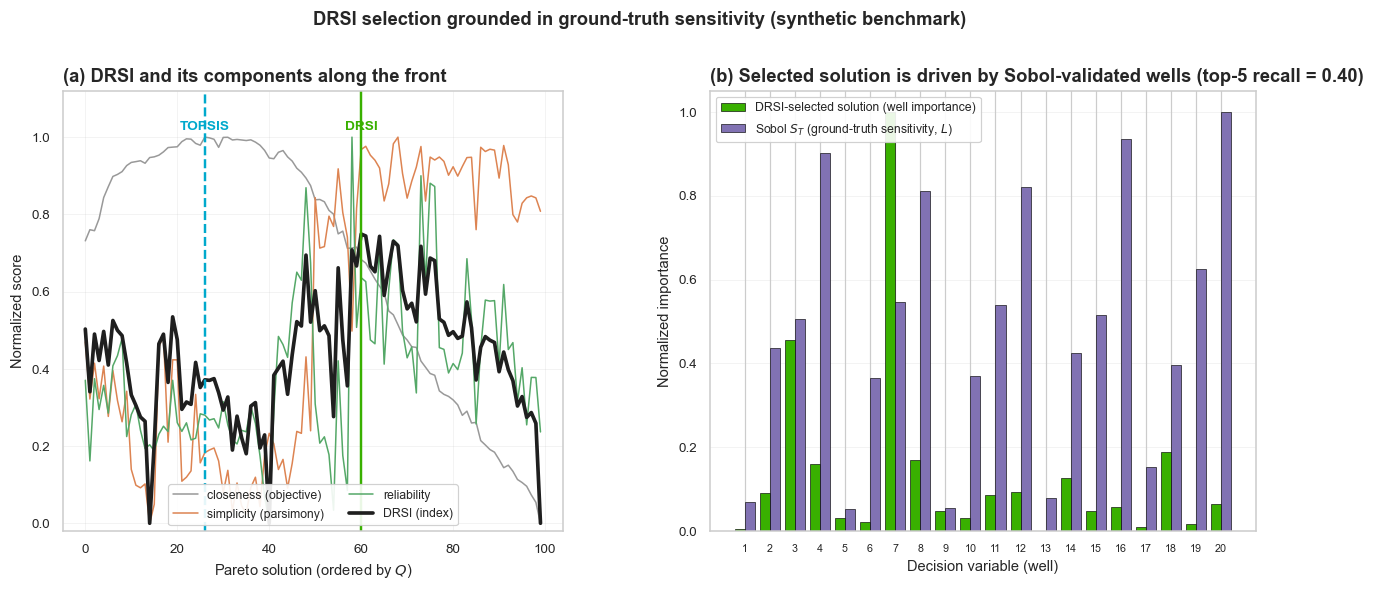

In [38]:
# DRSI Figure — index across the front + Sobol-grounding of the selected solution
fig = plt.figure(figsize=(14, 5.2))
gs = fig.add_gridspec(1, 2, width_ratios=[1.1, 1.2], wspace=0.28)

# (a) DRSI and its three components along the front (ordered by Q)
order = np.argsort(front['Q'].values)
axc = fig.add_subplot(gs[0])
axc.plot(range(len(order)), drsi_res['E'][order],  color='#999999', lw=1.0, label='closeness (objective)')
axc.plot(range(len(order)), drsi_res['S'][order],  color='#DD8452', lw=1.0, label='simplicity (parsimony)')
axc.plot(range(len(order)), drsi_res['R'][order],  color='#55A868', lw=1.0, label='reliability')
axc.plot(range(len(order)), drsi_res['drsi'][order], color='#1f1f1f', lw=2.4, label='DRSI (index)')
dpos = int(np.where(order == drsi_idx)[0][0]); tpos = int(np.where(order == topsis_idx)[0][0])
axc.axvline(dpos, color='#39b000', lw=1.6, ls='-'); axc.axvline(tpos, color='#00a9cc', lw=1.6, ls='--')
axc.text(dpos, 1.02, 'DRSI', color='#39b000', fontsize=9, fontweight='bold', ha='center')
axc.text(tpos, 1.02, 'TOPSIS', color='#00a9cc', fontsize=9, fontweight='bold', ha='center')
axc.set_xlabel('Pareto solution (ordered by $Q$)'); axc.set_ylabel('Normalized score')
axc.set_title('(a) DRSI and its components along the front', fontsize=12, loc='left', fontweight='bold')
axc.legend(fontsize=8, frameon=True, framealpha=0.9, loc='lower center', ncol=2)
axc.grid(alpha=0.3, linewidth=0.5); axc.set_axisbelow(True); axc.set_ylim(-0.02, 1.12)

# (b) driving wells of the DRSI-selected solution vs Sobol ground truth
axg = fig.add_subplot(gs[1])
x = np.arange(N_WELLS); w = 0.4
sel_share = drsi_res['share'][drsi_idx]
sobol_norm = sobol_df['ST_L'].values / (sobol_df['ST_L'].values.max() + 1e-12)
sel_norm = sel_share / (sel_share.max() + 1e-12)
axg.bar(x - w/2, sel_norm, w, label='DRSI-selected solution (well importance)',
        color='#39b000', edgecolor='black', linewidth=0.4)
axg.bar(x + w/2, sobol_norm, w, label='Sobol $S_T$ (ground-truth sensitivity, $L$)',
        color='#8172B3', edgecolor='black', linewidth=0.4)
axg.set_xticks(x); axg.set_xticklabels([f'{i+1}' for i in range(N_WELLS)], fontsize=7)
axg.set_xlabel('Decision variable (well)'); axg.set_ylabel('Normalized importance')
axg.set_title(f'(b) Selected solution is driven by Sobol-validated wells (top-5 recall = {recall_L:.2f})',
              fontsize=12, loc='left', fontweight='bold')
axg.legend(fontsize=8, frameon=True, framealpha=0.9)
axg.grid(alpha=0.3, axis='y', linewidth=0.5); axg.set_axisbelow(True)

fig.suptitle('DRSI selection grounded in ground-truth sensitivity (synthetic benchmark)',
             fontsize=12, fontweight='bold', y=1.02)
plt.savefig(FIGDIR / 'fig_drsi_proof.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGDIR / 'fig_drsi_proof.pdf', bbox_inches='tight')
plt.show()

---
## 10. Scenario analysis — decomposing representative Pareto solutions

Pick three Pareto points: extreme-Q (max extraction), extreme-L (max R-A exchange), and the knee (best balanced trade-off). Decompose each into well-by-well activation patterns. This shows how the *strategy* differs across the Pareto front — the most management-relevant output of the framework.


In [39]:
def find_representative_pareto_points(df):
    '''Return indices of (max-Q, max-L, knee) on the Pareto front.'''
    Q = df['Q'].values; L = df['L'].values
    i_maxQ = int(np.argmax(Q))
    i_maxL = int(np.argmax(L))
    # Knee: max distance from line connecting extremes
    Qn = (Q - Q.min()) / (Q.max() - Q.min() + 1e-12)
    Ln = (L - L.min()) / (L.max() - L.min() + 1e-12)
    # Distance from line from (Qn=0,Ln=1) to (Qn=1,Ln=0) i.e. Qn+Ln=1
    dist = np.abs(Qn + Ln - 1) / np.sqrt(2)
    # Knee = max perpendicular distance (above the line)
    knee_candidates = np.where(Qn + Ln > 1)[0]
    if len(knee_candidates) > 0:
        i_knee = int(knee_candidates[np.argmax(dist[knee_candidates])])
    else:
        i_knee = int(np.argmax(dist))
    return {'max_Q': i_maxQ, 'max_L': i_maxL, 'knee': i_knee}

# Use solutions from the primary NSGA2 / domain 1 / range 1000 front for scenario analysis
primary_front = synthetic_fronts['NSGA2_dv1_range1000'].reset_index(drop=True)
reps = find_representative_pareto_points(primary_front)
print(f"Representative Pareto points (in NSGA2_dv1_range1000):")
for name, idx in reps.items():
    row = primary_front.iloc[idx]
    print(f"  {name}: Q={row.Q:.0f}, L={row.L:.0f}")


Representative Pareto points (in NSGA2_dv1_range1000):
  max_Q: Q=4783, L=2837
  max_L: Q=1513, L=6486
  knee: Q=4518, L=3469


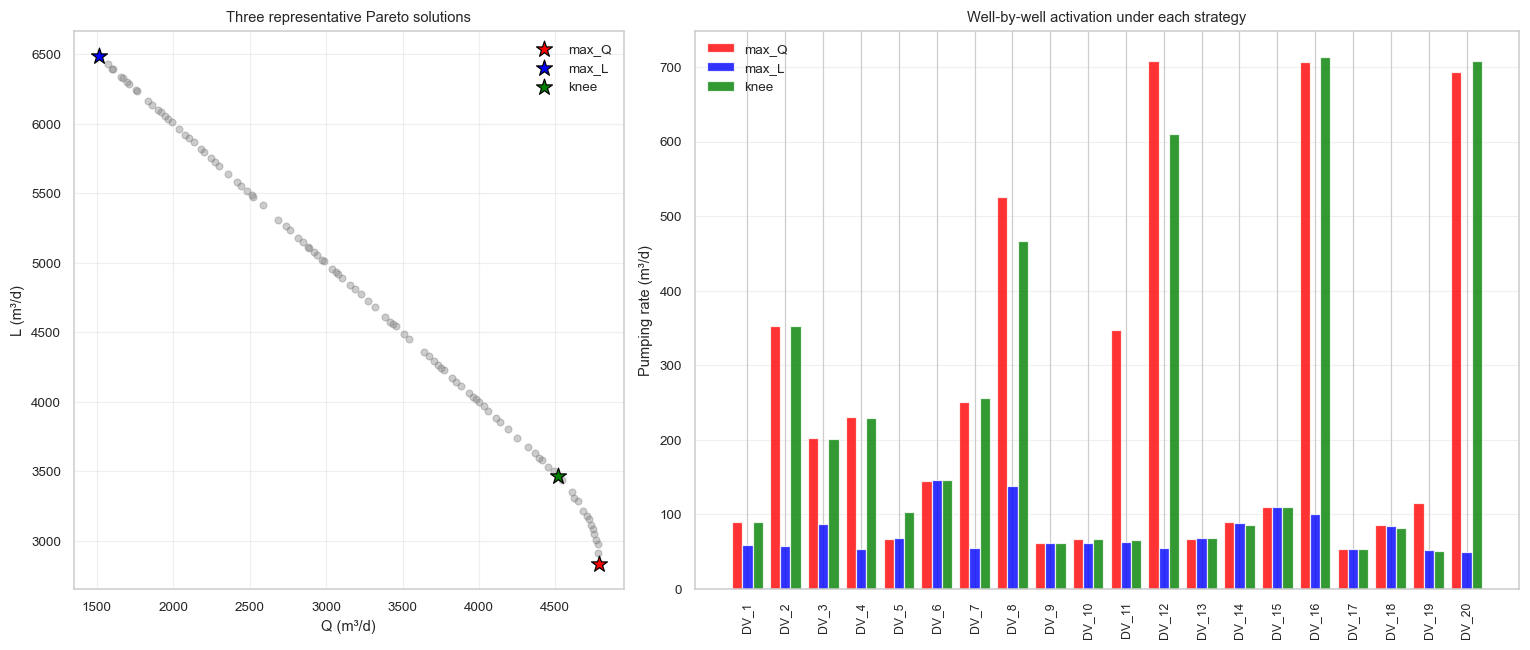

In [40]:
# Figure 13 — scenario analysis
fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.5])
ax_pf = fig.add_subplot(gs[0])
ax_bar = fig.add_subplot(gs[1])

# Pareto front with markers
ax_pf.scatter(primary_front.Q, primary_front.L, c='gray', alpha=0.4, s=20)
colors = {'max_Q': 'red', 'max_L': 'blue', 'knee': 'green'}
for name, idx in reps.items():
    r = primary_front.iloc[idx]
    ax_pf.scatter(r.Q, r.L, c=colors[name], s=120, marker='*', label=name, edgecolor='k', zorder=5)
ax_pf.set_xlabel('Q (m³/d)'); ax_pf.set_ylabel('L (m³/d)')
ax_pf.set_title('Three representative Pareto solutions')
ax_pf.legend(); ax_pf.grid(alpha=0.3)

# DV activation barplot
x = np.arange(N_WELLS); w = 0.27
for off, (name, idx) in zip([-w, 0, w], reps.items()):
    row = primary_front.iloc[idx]
    ax_bar.bar(x + off, [row[f'DV_{i+1}'] for i in range(N_WELLS)],
               w, label=name, color=colors[name], alpha=0.8)
ax_bar.set_xticks(x); ax_bar.set_xticklabels(DV_COLS, rotation=90, fontsize=8)
ax_bar.set_ylabel('Pumping rate (m³/d)'); ax_bar.set_title('Well-by-well activation under each strategy')
ax_bar.legend(); ax_bar.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIGDIR / 'fig13_synthetic_scenarios.png')
plt.show()


---
# Part B — Ain Basin Application

## 11. Load existing Ain Pareto fronts

This section assumes your existing PyGWMO Pareto front CSVs are placed in `./data/ain/`. The expected pattern is `<dv_range><domain><algo>.csv` (e.g., `2500ain2pso.csv`, `1500ain2moead.csv`), each with no header and columns `[Q, L, DV_1, ..., DV_31]`.

The commune shapefile (`wefe.shp`) should also live in `./data/ain/`.

If files are missing the cell will print clear placement instructions and the Ain analysis cells will be skipped.


In [41]:
# === Configurable Ain data loader ===
AIN_FILENAME_PATTERN = '*.csv'  # adjust if your naming differs
AIN_N_DV = 31

def load_ain_pareto_fronts(folder=AIN_DATA, pattern=AIN_FILENAME_PATTERN, n_dv=AIN_N_DV):
    folder = Path(folder)
    if not folder.exists():
        print(f"!! Ain folder not found: {folder}")
        print("   Create it and copy your PyGWMO Pareto CSV files into it.")
        print("   Expected filename pattern hints: '<dv_range><area><algo>.csv' (e.g. '2500ain2pso.csv')")
        return None
    
    files = sorted(folder.glob(pattern))
    if not files:
        print(f"!! No CSVs in {folder}")
        return None
    
    dv_cols_ain = [f'DV_{i+1}' for i in range(n_dv)]
    parts = []
    for f in files:
        try:
            df = pd.read_csv(f, header=None)
        except Exception as e:
            print(f"  Skipping {f.name}: {e}")
            continue
        if df.shape[1] < n_dv + 2:
            print(f"  Skipping {f.name}: only {df.shape[1]} columns, need {n_dv+2}")
            continue
        df = df.iloc[:, :n_dv+2]
        df.columns = ['Q', 'L'] + dv_cols_ain
        # Parse algo / domain / range from filename — best-effort
        name = f.stem.lower()
        for algo in ['nsga2', 'nsgaii', 'moead', 'mopso', 'pso']:
            if algo in name: df['algo'] = algo; break
        else: df['algo'] = 'unknown'
        for d in ['ain1', 'ain2', 'ain3']:
            if d in name: df['domain'] = d; break
        else: df['domain'] = 'unknown'
        # DV range from leading digits
        for r in ['1500', '2500', '500']:
            if r in name: df['dv_high'] = int(r); break
        else: df['dv_high'] = -1
        df['source_file'] = f.name
        parts.append(df)
        print(f"  Loaded {f.name}: {len(df)} solutions")
    
    if not parts: return None
    return pd.concat(parts, ignore_index=True)

AIN_DF = load_ain_pareto_fronts()
AIN_AVAILABLE = AIN_DF is not None and len(AIN_DF) > 0
if AIN_AVAILABLE:
    print(f"\nAin dataset pooled: {len(AIN_DF)} solutions across {AIN_DF.source_file.nunique()} files")


  Loaded 1500ain2ga.csv: 19 solutions
  Loaded 1500ain2moead.csv: 167 solutions
  Loaded 1500ain2pso.csv: 90 solutions
  Skipping 1500ain3ga.csv: only 32 columns, need 33
  Skipping 1500ain3moead.csv: only 32 columns, need 33
  Skipping 1500ain3pso.csv: only 32 columns, need 33
  Loaded 2500ain2ga.csv: 28 solutions
  Loaded 2500ain2moead.csv: 387 solutions
  Loaded 2500ain2pso.csv: 119 solutions
  Loaded 2500ain3ga.csv: 10 solutions
  Skipping 2500ain3moead.csv: only 32 columns, need 33
  Skipping 2500ain3pso.csv: only 32 columns, need 33
  Skipping Penalty_dd_distance.csv: only 5 columns, need 33

Ain dataset pooled: 820 solutions across 7 files


[placeholder] Aquifer shapefile not found: D:\3. dv paper\data\ain\aquifer_extent.shp
[placeholder] HK shapefile not found: D:\3. dv paper\data\ain\hk_zones.shp
[placeholder] MODFLOW grid not found: D:\3. dv paper\data\ain\modflow_grid.shp


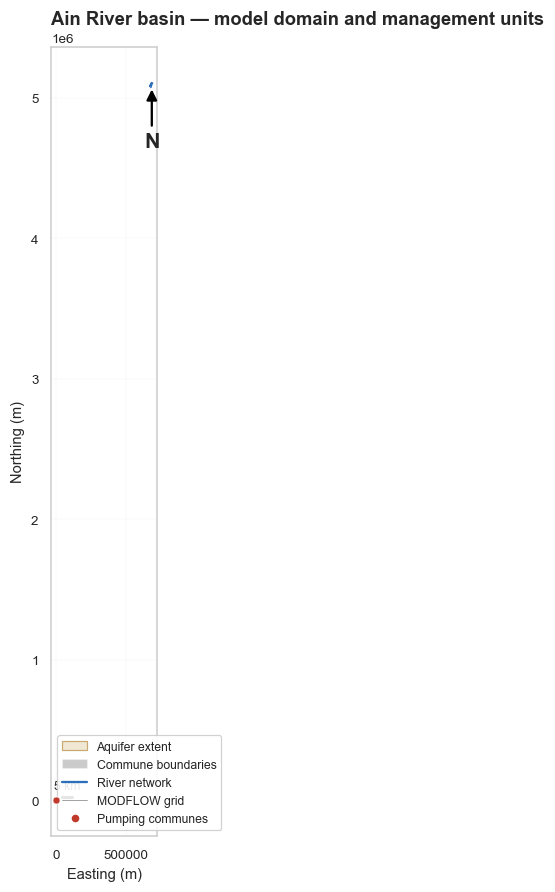

In [42]:
# === Figure 2 — Ain basin study area ===
# Place this cell early in the notebook (after Ain data loading)

import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# --- Placeholder shapefile paths (update these to your actual paths) ---
SHP_COMMUNES = AIN_DATA / 'wefe.shp'           # commune boundaries + DV mapping
SHP_RIVER     = AIN_DATA / 'river.shp'          # river network
SHP_AQUIFER   = AIN_DATA / 'aquifer_extent.shp' # aquifer outline
SHP_MFGRID    = AIN_DATA / 'modflow_grid.shp'   # MODFLOW grid
SHP_HK        = AIN_DATA / 'hk_zones.shp'       # hydraulic conductivity
SHP_THICK     = AIN_DATA / 'thickness.shp'      # aquifer thickness

fig, ax = plt.subplots(figsize=(9, 8), constrained_layout=True)

# Aquifer extent (background fill)
try:
    gdf_aq = gpd.read_file(SHP_AQUIFER)
    gdf_aq.plot(ax=ax, color='#f0e8d4', edgecolor='#c9a96e', linewidth=1.2,
                label='Aquifer extent', zorder=1)
except Exception:
    print(f"[placeholder] Aquifer shapefile not found: {SHP_AQUIFER}")

# Hydraulic conductivity zones (optional, subtle)
try:
    gdf_hk = gpd.read_file(SHP_HK)
    gdf_hk.plot(ax=ax, column='hk', cmap='YlOrBr', alpha=0.35,
                edgecolor='none', zorder=2, legend=True,
                legend_kwds={'label': 'Hydraulic conductivity (m/d)',
                             'shrink': 0.4, 'pad': 0.02})
except Exception:
    print(f"[placeholder] HK shapefile not found: {SHP_HK}")

# MODFLOW grid outline
try:
    gdf_mf = gpd.read_file(SHP_MFGRID)
    gdf_mf.boundary.plot(ax=ax, color='#888888', linewidth=0.3, zorder=3)
except Exception:
    print(f"[placeholder] MODFLOW grid not found: {SHP_MFGRID}")

# Commune boundaries
try:
    gdf_com = gpd.read_file(SHP_COMMUNES)
    gdf_com.boundary.plot(ax=ax, color='#555555', linewidth=0.6, zorder=4)
except Exception:
    print(f"[placeholder] Commune shapefile not found: {SHP_COMMUNES}")

# River network
try:
    gdf_riv = gpd.read_file(SHP_RIVER)
    gdf_riv.plot(ax=ax, color='#2c6fbb', linewidth=1.5, zorder=5,
                 label='River network')
except Exception:
    print(f"[placeholder] River shapefile not found: {SHP_RIVER}")

# Well / pumping commune centroids (if available in commune shapefile)
try:
    centroids = gdf_com.geometry.centroid
    ax.scatter(centroids.x, centroids.y, c='#c0392b', s=20, zorder=6,
              edgecolor='white', linewidth=0.3, label='Pumping communes')
except Exception:
    pass

# North arrow
ax.annotate('N', xy=(0.95, 0.95), xycoords='axes fraction',
            fontsize=14, fontweight='bold', ha='center', va='center',
            xytext=(0.95, 0.88), textcoords='axes fraction',
            arrowprops=dict(arrowstyle='-|>', color='black', lw=1.5))

# Scale bar (approximate, adjust for your CRS)
ax.plot([0.1, 0.2], [0.05, 0.05], transform=ax.transAxes, color='black', lw=2)
ax.text(0.15, 0.06, '5 km', transform=ax.transAxes, ha='center', fontsize=8)

ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')
ax.set_title('Ain River basin — model domain and management units',
             fontsize=12, loc='left', fontweight='bold')
ax.set_aspect('equal')
ax.grid(alpha=0.2, linewidth=0.3)

# Custom legend
handles = [
    mpatches.Patch(facecolor='#f0e8d4', edgecolor='#c9a96e', label='Aquifer extent'),
    mpatches.Patch(facecolor='#555555', alpha=0.3, label='Commune boundaries'),
    Line2D([0], [0], color='#2c6fbb', linewidth=1.5, label='River network'),
    Line2D([0], [0], color='#888888', linewidth=0.5, label='MODFLOW grid'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#c0392b',
           markersize=6, label='Pumping communes'),
]
ax.legend(handles=handles, loc='lower left', fontsize=8, frameon=True,
          framealpha=0.9)

plt.savefig(FIGDIR / 'fig_ain_study_area.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGDIR / 'fig_ain_study_area.pdf', bbox_inches='tight')
plt.show()

## 12. Apply the validated framework to Ain

We apply the *identical pipeline* — PCA, XGBoost+SHAP, XGBoost+LIME, GAM, Getis-Ord, consensus ranking — to the Ain dataset. The methods are now informed by the synthetic benchmark: we know which methods were most reliable against Sobol ground truth and can weight the consensus accordingly (or simply report disagreement honestly).


In [43]:
if AIN_AVAILABLE:
    AIN_DV_COLS = [f'DV_{i+1}' for i in range(AIN_N_DV)]
    
    before = len(AIN_DF)
    # Replace inf with NaN, then drop any row with NaN in Q, L, or any DV
    AIN_DF = AIN_DF.replace([np.inf, -np.inf], np.nan)
    cols_to_check = ['Q', 'L'] + AIN_DV_COLS
    AIN_DF = AIN_DF.dropna(subset=cols_to_check).reset_index(drop=True)
    after = len(AIN_DF)
    
    print(f"Ain cleaning: {before} -> {after} solutions ({before-after} rows dropped for NaN/inf)")
    print(f"Any NaN left? {AIN_DF[cols_to_check].isna().any().any()}")
    print(f"Any inf left? {np.isinf(AIN_DF[cols_to_check].values).any()}")
    print(f"Columns: {AIN_DF.shape[1]}, DV count: {AIN_N_DV}")

Ain cleaning: 820 -> 817 solutions (3 rows dropped for NaN/inf)
Any NaN left? False
Any inf left? False
Columns: 37, DV count: 31


In [44]:
if AIN_AVAILABLE:
    AIN_DV_COLS = [f'DV_{i+1}' for i in range(AIN_N_DV)]
    
    # VIF
    vif_ain = vif_check(AIN_DF, AIN_DV_COLS)
    print(f"Ain VIF max: {vif_ain.VIF.max():.2f}")
    
    # PCA
    scaler_ain = StandardScaler()
    X_ain = scaler_ain.fit_transform(AIN_DF[AIN_DV_COLS])
    pca_ain = PCA(n_components=min(AIN_N_DV, 10))
    scores_ain = pca_ain.fit_transform(X_ain)
    loadings_ain = pca_ain.components_.T * np.sqrt(pca_ain.explained_variance_)
    PCA_IMPORTANCE_AIN = np.abs(loadings_ain[:, 0])
    
    # Surrogate + xAI (ensemble: XGBoost / RandomForest / GradientBoosting)
    print("Fitting ensemble surrogate (Ain)...")
    models_ain, ensemble_ain, metrics_ain = fit_surrogate_ensemble(AIN_DF, dv_cols=AIN_DV_COLS, obj_cols=('Q', 'L'))
    print("Ain surrogate comparison (5-fold CV):")
    print(metrics_ain.round(3).to_string(index=False))
    metrics_ain.to_csv(RESULTS / 'surrogate_ensemble_metrics_ain.csv', index=False)
    
    shap_results_ain = {}
    for obj in ['Q', 'L']:
        m, lo, hi, sv = shap_importance(models_ain[obj], AIN_DF[AIN_DV_COLS])
        shap_results_ain[obj] = {'mean_abs': m, 'ci_low': lo, 'ci_high': hi, 'shap_values': sv}
else:
    print("Skipping Ain section — data not available.")


Ain VIF max: 74.38
Fitting ensemble surrogate (Ain)...
  Q: best surrogate = GradBoost (CV R2 = 0.991)
  L: best surrogate = GradBoost (CV R2 = 0.984)
Ain surrogate comparison (5-fold CV):
objective        model  cv_r2_mean  cv_r2_std  cv_rmse_mean  cv_rmse_std
        Q      XGBoost       0.983      0.026     15528.527    12274.809
        Q RandomForest       0.990      0.012     13167.355     7778.148
        Q    GradBoost       0.991      0.010     11370.162     7767.313
        L      XGBoost       0.981      0.017     12077.023     5631.766
        L RandomForest       0.983      0.014     11381.866     4863.601
        L    GradBoost       0.984      0.016     10700.011     5726.161


In [45]:
if AIN_AVAILABLE:
    # LIME and GAM on Ain — cache them
    ain_xai_cache = CACHE / 'ain_xai_results.pkl'
    if USE_CACHE and ain_xai_cache.exists():
        with open(ain_xai_cache, 'rb') as f:
            cached = pickle.load(f)
        lime_results_ain = cached['lime']
        gam_results_ain = cached['gam']
        print("Loaded Ain LIME+GAM from cache.")
    else:
        print("Computing LIME for Ain (slow)...")
        lime_results_ain = {}
        for obj in ['Q', 'L']:
            m, lo, hi, w = lime_importance(models_ain[obj], AIN_DF[AIN_DV_COLS])
            lime_results_ain[obj] = {'mean_abs': m, 'ci_low': lo, 'ci_high': hi, 'weights': w}
        print("Fitting GAM for Ain...")
        gam_results_ain = {}
        for obj in ['Q', 'L']:
            imp, mod = gam_importance(AIN_DF, dv_cols=AIN_DV_COLS, target=obj)
            gam_results_ain[obj] = {'importance': imp, 'model': mod}
        with open(ain_xai_cache, 'wb') as f:
            pickle.dump({'lime': lime_results_ain, 'gam': gam_results_ain}, f)


Loaded Ain LIME+GAM from cache.


In [46]:
if AIN_AVAILABLE:
    # Rankings and consensus on Ain
    def ain_rankings(target):
        src = {
            'PCA':  PCA_IMPORTANCE_AIN,
            'SHAP': shap_results_ain[target]['mean_abs'],
            'LIME': lime_results_ain[target]['mean_abs'],
            'GAM':  gam_results_ain[target]['importance'],
        }
        df = pd.DataFrame({m: to_ranking(s) for m, s in src.items()}, index=AIN_DV_COLS)
        return df, src
    
    ranks_Q_ain, scores_Q_ain = ain_rankings('Q')
    ranks_L_ain, scores_L_ain = ain_rankings('L')
    
    print("Ain — Kendall tau matrix (Objective Q):")
    print(kendall_tau_matrix(ranks_Q_ain).round(3))
    
    borda_Q_ain, _ = borda_consensus(ranks_Q_ain)
    borda_L_ain, _ = borda_consensus(ranks_L_ain)
    print("\nAin Borda consensus — top 10 wells for Q:")
    print(borda_Q_ain.head(10))
    print("\nAin Borda consensus — top 10 wells for L:")
    print(borda_L_ain.head(10))


Ain — Kendall tau matrix (Objective Q):
        PCA   SHAP   LIME    GAM
PCA   1.000  0.166  0.140 -0.166
SHAP  0.166  1.000  0.682 -0.097
LIME  0.140  0.682  1.000 -0.080
GAM  -0.166 -0.097 -0.080  1.000

Ain Borda consensus — top 10 wells for Q:
DV_11    25
DV_2     26
DV_4     29
DV_20    34
DV_29    42
DV_16    45
DV_5     48
DV_6     49
DV_21    50
DV_27    51
dtype: int64

Ain Borda consensus — top 10 wells for L:
DV_11    24
DV_4     26
DV_8     36
DV_2     39
DV_6     43
DV_25    50
DV_29    52
DV_7     53
DV_30    53
DV_17    53
dtype: int64


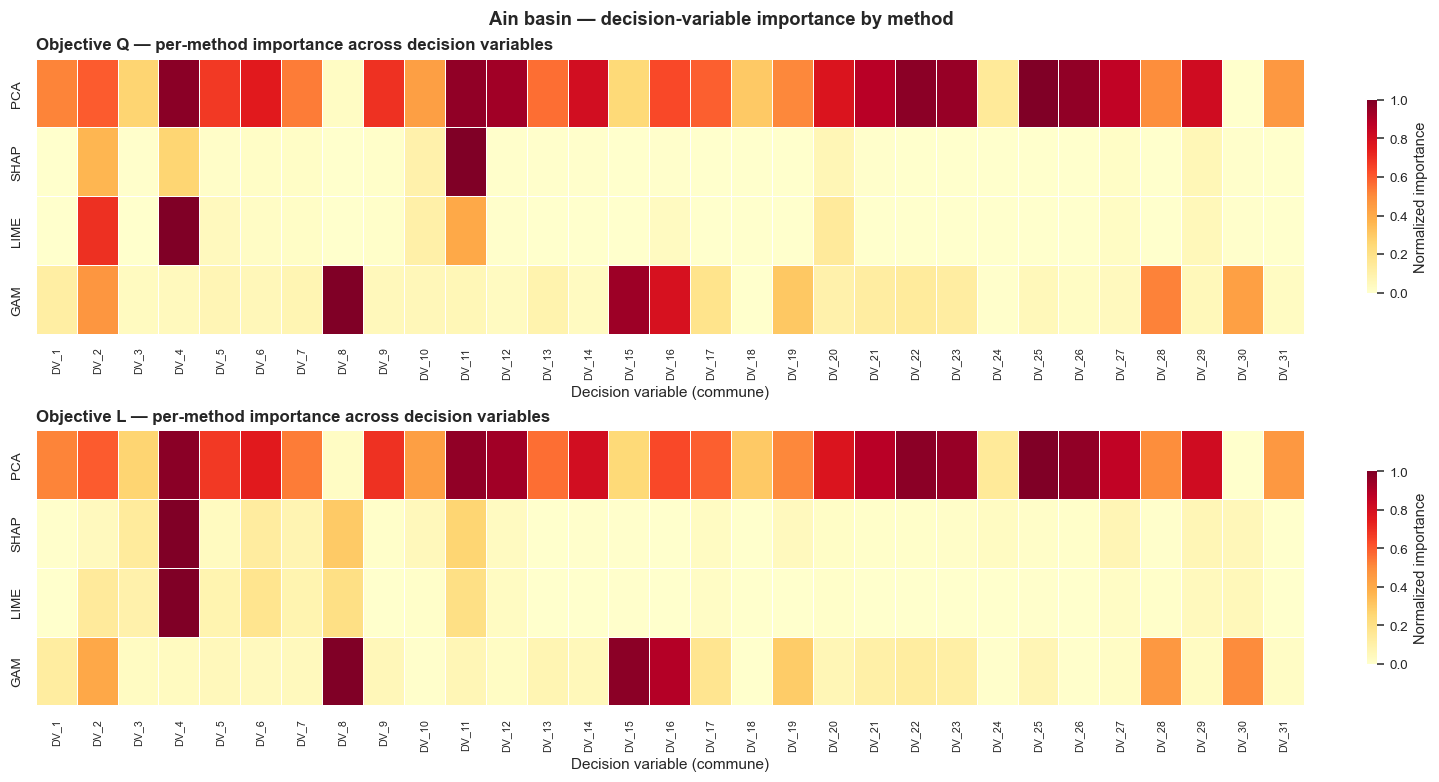

In [47]:
if AIN_AVAILABLE:
    # Figure 14 — Ain importance heatmap per method (normalized for comparability)
    fig, axes = plt.subplots(2, 1, figsize=(13, 7), constrained_layout=True)
    for ax, obj, scores in zip(axes, ['Q', 'L'], [scores_Q_ain, scores_L_ain]):
        df_plot = pd.DataFrame(scores, index=AIN_DV_COLS)
        df_norm = (df_plot - df_plot.min()) / (df_plot.max() - df_plot.min() + 1e-12)
        sns.heatmap(df_norm.T, cmap='YlOrRd', ax=ax, linewidths=0.4, linecolor='white',
                    cbar_kws={'label': 'Normalized importance', 'shrink': 0.7})
        ax.set_title(f'Objective {obj} — per-method importance across decision variables',
                     fontsize=11, loc='left', fontweight='bold')
        ax.set_xlabel('Decision variable (commune)', fontsize=10)
        ax.set_ylabel('')
        ax.tick_params(axis='x', labelsize=7, rotation=90)
    fig.suptitle('Ain basin — decision-variable importance by method', fontsize=12, fontweight='bold')
    plt.savefig(FIGDIR / 'fig14_ain_importance_heatmap.png', dpi=300, bbox_inches='tight')
    plt.savefig(FIGDIR / 'fig14_ain_importance_heatmap.pdf', bbox_inches='tight')
    plt.show()

Ain front: 554 solutions (algorithm: moead)
TOPSIS pick #56: Q=105000, L=304000, eff. communes=4.0
DRSI pick #106: Q=114000, L=298000, eff. communes=4.1


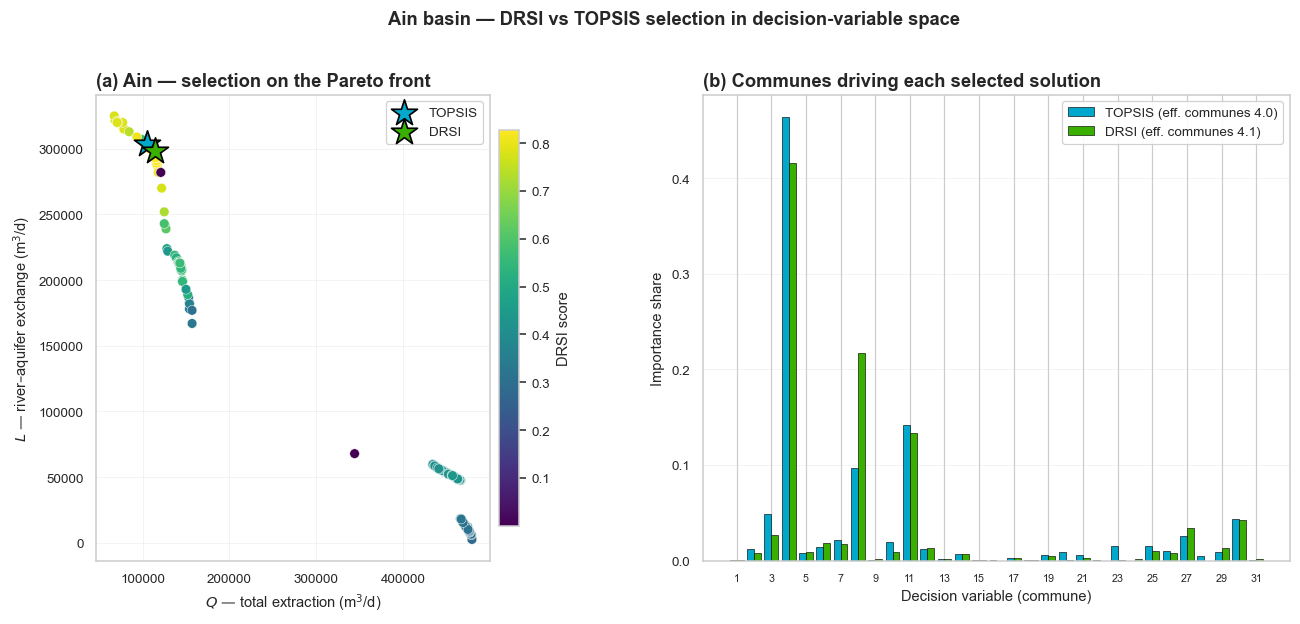

In [48]:
# ---- Apply DRSI to the Ain basin (largest single-algorithm front) ----

if AIN_AVAILABLE:
    algo_counts = AIN_DF['algo'].value_counts()
    main_algo = algo_counts.index[0]
    amask = (AIN_DF['algo'] == main_algo).values
    ain_front = AIN_DF[amask].reset_index(drop=True)
    aidx = np.where(amask)[0]
    shapL_a = shap_results_ain['L']['shap_values'][aidx]
    shapQ_a = shap_results_ain['Q']['shap_values'][aidx]  # for visualization only
    relL_a = reliability_L_only(shap_results_ain['L'])

    drsi_ain = compute_drsi(ain_front, shapL_a, relL_a, weights=(1, 1, 1))
    t_idx = int(np.argmax(drsi_ain['closeness']))  # TOPSIS / compromise programming
    d_idx = int(np.argmax(drsi_ain['drsi']))       # DRSI

    # Pre-compute label strings to avoid f-string nesting issues
    eff_t = drsi_ain['eff_wells'][t_idx]
    eff_d = drsi_ain['eff_wells'][d_idx]
    label_topsis = f"TOPSIS (eff. communes {eff_t:.1f})"
    label_drsi = f"DRSI (eff. communes {eff_d:.1f})"

    print(f"Ain front: {len(ain_front)} solutions (algorithm: {main_algo})")
    print(f"TOPSIS pick #{t_idx}: Q={ain_front.Q[t_idx]:.0f}, "
          f"L={ain_front.L[t_idx]:.0f}, "
          f"eff. communes={eff_t:.1f}")
    print(f"DRSI pick #{d_idx}: Q={ain_front.Q[d_idx]:.0f}, "
          f"L={ain_front.L[d_idx]:.0f}, "
          f"eff. communes={eff_d:.1f}")

    # ---- Figure — Ain DRSI selection contrast ----
    fig = plt.figure(figsize=(14, 5.5))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.05, 1.3], wspace=0.25)
    axp = fig.add_subplot(gs[0])
    sc = axp.scatter(ain_front.Q, ain_front.L, c=drsi_ain['drsi'], cmap='viridis',
                     s=40, edgecolor='white', linewidth=0.3)
    axp.scatter(ain_front.Q[t_idx], ain_front.L[t_idx], s=320, marker='*',
                color='#00a9cc', edgecolor='black', linewidth=1.1, zorder=5, label='TOPSIS')
    axp.scatter(ain_front.Q[d_idx], ain_front.L[d_idx], s=320, marker='*',
                color='#39b000', edgecolor='black', linewidth=1.1, zorder=5, label='DRSI')
    axp.set_xlabel(r'$Q$ — total extraction (m$^3$/d)')
    axp.set_ylabel(r'$L$ — river–aquifer exchange (m$^3$/d)')
    axp.set_title('(a) Ain — selection on the Pareto front', fontsize=12, loc='left', fontweight='bold')
    axp.legend(frameon=True, framealpha=0.9); axp.grid(alpha=0.3, linewidth=0.5); axp.set_axisbelow(True)
    cb = fig.colorbar(sc, ax=axp, shrink=0.85, pad=0.02); cb.set_label('DRSI score')

    axb = fig.add_subplot(gs[1])
    x = np.arange(AIN_N_DV); w = 0.4
    axb.bar(x - w/2, drsi_ain['share'][t_idx], w,
            label=label_topsis,
            color='#00a9cc', edgecolor='black', linewidth=0.4)
    axb.bar(x + w/2, drsi_ain['share'][d_idx], w,
            label=label_drsi,
            color='#39b000', edgecolor='black', linewidth=0.4)
    axb.set_xticks(x[::2]); axb.set_xticklabels([f'{i+1}' for i in range(0, AIN_N_DV, 2)], fontsize=7)
    axb.set_xlabel('Decision variable (commune)'); axb.set_ylabel('Importance share')
    axb.set_title('(b) Communes driving each selected solution', fontsize=12, loc='left', fontweight='bold')
    axb.legend(frameon=True, framealpha=0.9); axb.grid(alpha=0.3, axis='y', linewidth=0.5); axb.set_axisbelow(True)
    fig.suptitle('Ain basin — DRSI vs TOPSIS selection in decision-variable space',
                 fontsize=12, fontweight='bold', y=1.02)
    plt.savefig(FIGDIR / 'fig_drsi_ain_selection.png', dpi=300, bbox_inches='tight')
    plt.savefig(FIGDIR / 'fig_drsi_ain_selection.pdf', bbox_inches='tight')
    plt.show()

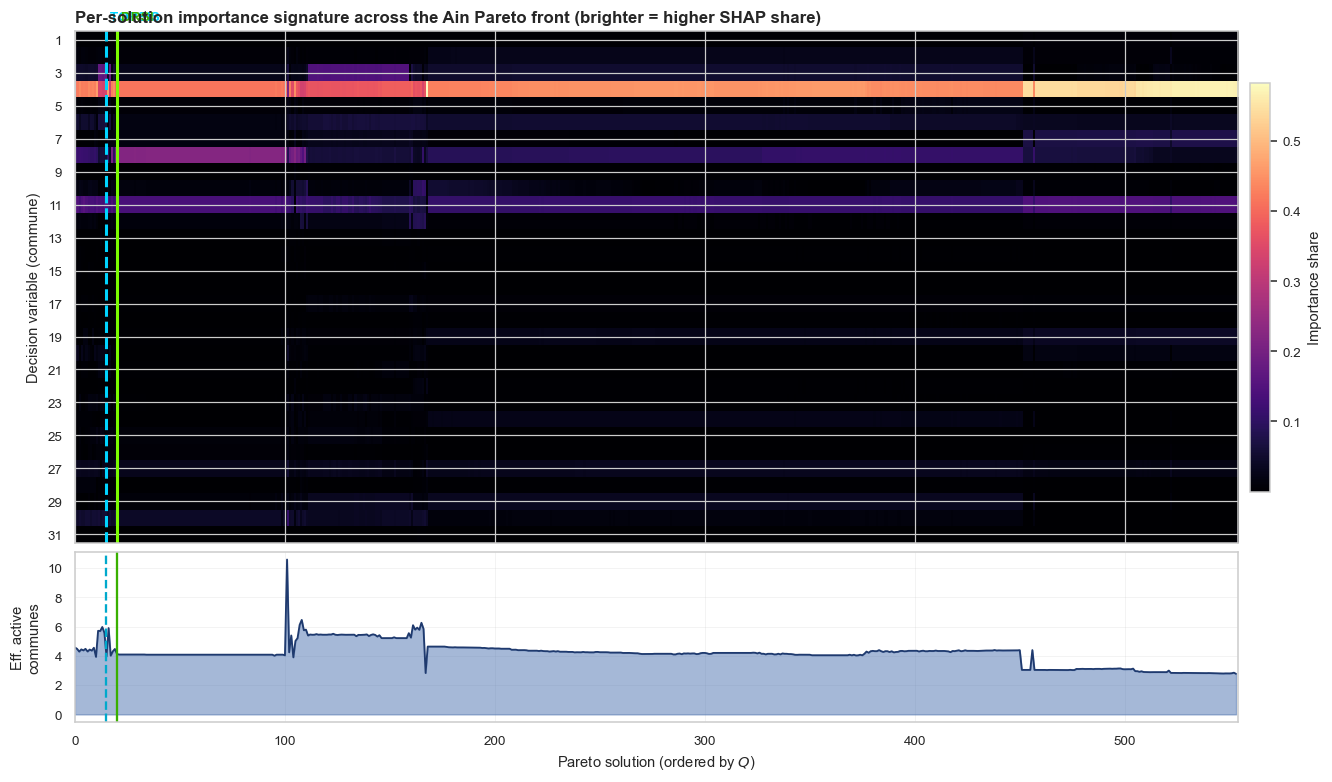

In [49]:
# DRSI Figure — per-solution importance signatures along the Ain Pareto front
order = np.argsort(ain_front['Q'].values)              # sort solutions by Q
share_sorted = drsi_ain['share'][order]
topsis_pos = int(np.where(order == t_idx)[0][0])
drsi_pos   = int(np.where(order == d_idx)[0][0])

fig, (axh, axb) = plt.subplots(2, 1, figsize=(12, 7), height_ratios=[3, 1],
                               sharex=True, constrained_layout=True)
im = axh.imshow(share_sorted.T, aspect='auto', cmap='magma', interpolation='nearest',
                extent=[0, len(order), AIN_N_DV + 0.5, 0.5])
axh.set_ylabel('Decision variable (commune)')
axh.set_yticks(range(1, AIN_N_DV + 1, 2))
axh.axvline(topsis_pos, color='#00d4ff', lw=2.0, ls='--')
axh.axvline(drsi_pos,   color='#7CFC00', lw=2.0, ls='-')
axh.text(topsis_pos, 0.0, ' TOPSIS', color='#00d4ff', fontsize=9, fontweight='bold', va='bottom')
axh.text(drsi_pos, 0.0, ' DRSI', color='#39b000', fontsize=9, fontweight='bold', va='bottom')
axh.set_title('Per-solution importance signature across the Ain Pareto front (brighter = higher SHAP share)',
              fontsize=11, loc='left', fontweight='bold')
cbar = fig.colorbar(im, ax=axh, shrink=0.8, pad=0.01); cbar.set_label('Importance share')

# bottom strip: effective number of active communes along the front
axb.fill_between(range(len(order)), drsi_ain['eff_wells'][order], color='#4C72B0', alpha=0.5)
axb.plot(range(len(order)), drsi_ain['eff_wells'][order], color='#1f3a6e', lw=1.2)
axb.axvline(topsis_pos, color='#00a9cc', lw=1.5, ls='--')
axb.axvline(drsi_pos,   color='#39b000', lw=1.5, ls='-')
axb.set_ylabel('Eff. active\ncommunes'); axb.set_xlabel('Pareto solution (ordered by $Q$)')
axb.grid(alpha=0.3, linewidth=0.5); axb.set_axisbelow(True)
plt.savefig(FIGDIR / 'fig_drsi_signatures_ain.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGDIR / 'fig_drsi_signatures_ain.pdf', bbox_inches='tight')
plt.show()

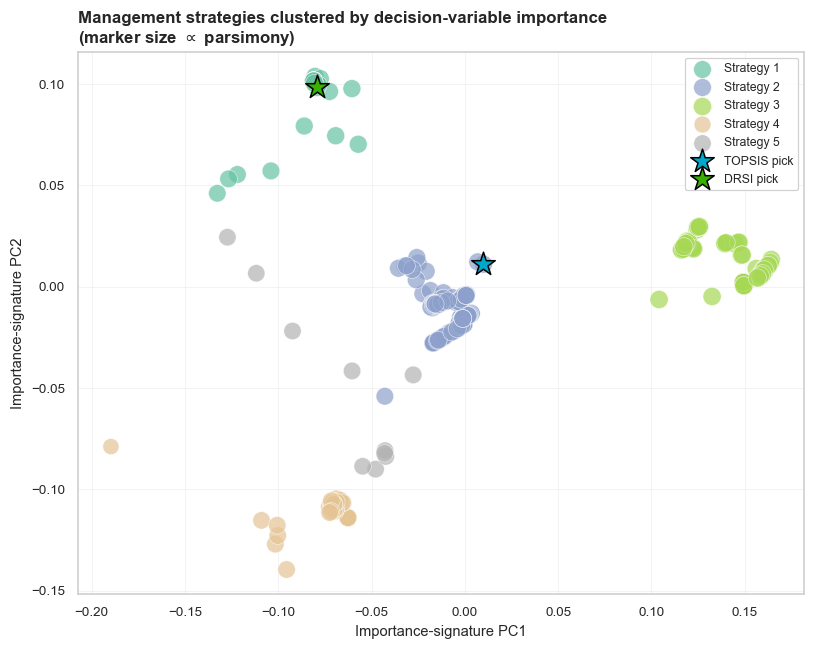

In [50]:
# DRSI Figure — management-strategy clusters in decision-importance space (Ain)
clusters_ain, n_clust_ain, _ = dvis_clusters(shapL_a, seed=SEED)
emb = PCA(n_components=2).fit_transform(drsi_ain['share'])
fig, ax = plt.subplots(figsize=(7.5, 6))
cmap_c = plt.cm.Set2(np.linspace(0, 1, n_clust_ain))
for k in range(n_clust_ain):
    m = clusters_ain == k
    ax.scatter(emb[m, 0], emb[m, 1], s=30 + 120 * drsi_ain['simplicity'][m],
               color=cmap_c[k], alpha=0.7, edgecolor='white', linewidth=0.4,
               label=f'Strategy {k+1}')
# mark picks
ax.scatter(*emb[t_idx], s=260, marker='*', color='#00a9cc',
           edgecolor='black', linewidth=1.0, zorder=5, label='TOPSIS pick')
ax.scatter(*emb[d_idx], s=260, marker='*', color='#39b000',
           edgecolor='black', linewidth=1.0, zorder=5, label='DRSI pick')
ax.set_xlabel('Importance-signature PC1'); ax.set_ylabel('Importance-signature PC2')
ax.set_title('Management strategies clustered by decision-variable importance\n(marker size $\\propto$ parsimony)',
             fontsize=11, loc='left', fontweight='bold')
ax.legend(fontsize=8, loc='best', frameon=True, framealpha=0.9)
ax.grid(alpha=0.3, linewidth=0.5); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(FIGDIR / 'fig_drsi_clusters_ain.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGDIR / 'fig_drsi_clusters_ain.pdf', bbox_inches='tight')
plt.show()

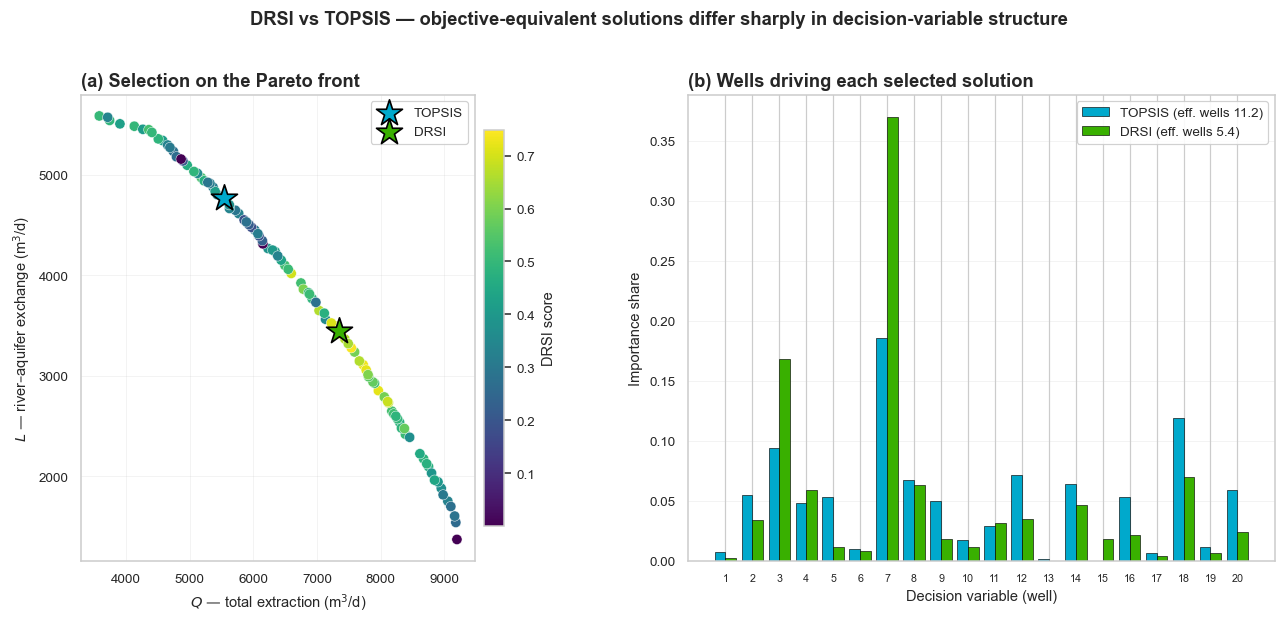

In [51]:
# DRSI Figure — selection contrast: Pareto front + well-activation profiles [SYNTHETIC MONEY FIGURE]
fig = plt.figure(figsize=(14, 5.5))
gs = fig.add_gridspec(1, 2, width_ratios=[1.05, 1.3], wspace=0.25)

# Pre-compute labels to avoid f-string nesting issues
eff_t_syn = drsi_res['eff_wells'][topsis_idx]
eff_d_syn = drsi_res['eff_wells'][drsi_idx]
label_t_syn = f"TOPSIS (eff. wells {eff_t_syn:.1f})"
label_d_syn = f"DRSI (eff. wells {eff_d_syn:.1f})"

# (a) Pareto front coloured by DRSI composite, with both picks
axp = fig.add_subplot(gs[0])
sc = axp.scatter(front.Q, front.L, c=drsi_res['drsi'], cmap='viridis',
                 s=45, edgecolor='white', linewidth=0.3)
axp.scatter(front.Q[topsis_idx], front.L[topsis_idx], s=320, marker='*',
            color='#00a9cc', edgecolor='black', linewidth=1.1, zorder=5, label='TOPSIS')
axp.scatter(front.Q[drsi_idx], front.L[drsi_idx], s=320, marker='*',
            color='#39b000', edgecolor='black', linewidth=1.1, zorder=5, label='DRSI')
axp.set_xlabel(r'$Q$ — total extraction (m$^3$/d)')
axp.set_ylabel(r'$L$ — river–aquifer exchange (m$^3$/d)')
axp.set_title('(a) Selection on the Pareto front', fontsize=12, loc='left', fontweight='bold')
axp.legend(frameon=True, framealpha=0.9); axp.grid(alpha=0.3, linewidth=0.5); axp.set_axisbelow(True)
cb = fig.colorbar(sc, ax=axp, shrink=0.85, pad=0.02); cb.set_label('DRSI score')

# (b) well-activation profiles of the two picks
axb = fig.add_subplot(gs[1])
x = np.arange(N_WELLS); w = 0.4
sh_topsis = drsi_res['share'][topsis_idx]
sh_drsi = drsi_res['share'][drsi_idx]
axb.bar(x - w/2, sh_topsis, w, label=label_t_syn,
        color='#00a9cc', edgecolor='black', linewidth=0.4)
axb.bar(x + w/2, sh_drsi, w, label=label_d_syn,
        color='#39b000', edgecolor='black', linewidth=0.4)
axb.set_xticks(x); axb.set_xticklabels([f'{i+1}' for i in range(N_WELLS)], fontsize=7)
axb.set_xlabel('Decision variable (well)'); axb.set_ylabel('Importance share')
axb.set_title('(b) Wells driving each selected solution', fontsize=12, loc='left', fontweight='bold')
axb.legend(frameon=True, framealpha=0.9); axb.grid(alpha=0.3, axis='y', linewidth=0.5); axb.set_axisbelow(True)

fig.suptitle('DRSI vs TOPSIS — objective-equivalent solutions differ sharply in decision-variable structure',
             fontsize=12, fontweight='bold', y=1.02)
plt.savefig(FIGDIR / 'fig_drsi_selection_synthetic.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGDIR / 'fig_drsi_selection_synthetic.pdf', bbox_inches='tight')
plt.show()

Ain DRSI pick: Q=114000, L=298000, effective communes=4.1
Validation (bootstrap, B=500): most-selected solution chosen in 3% of resamples
Nominal DRSI pick in top-5: 39%, top-10: 72% of resamples
Total solutions in front: 554


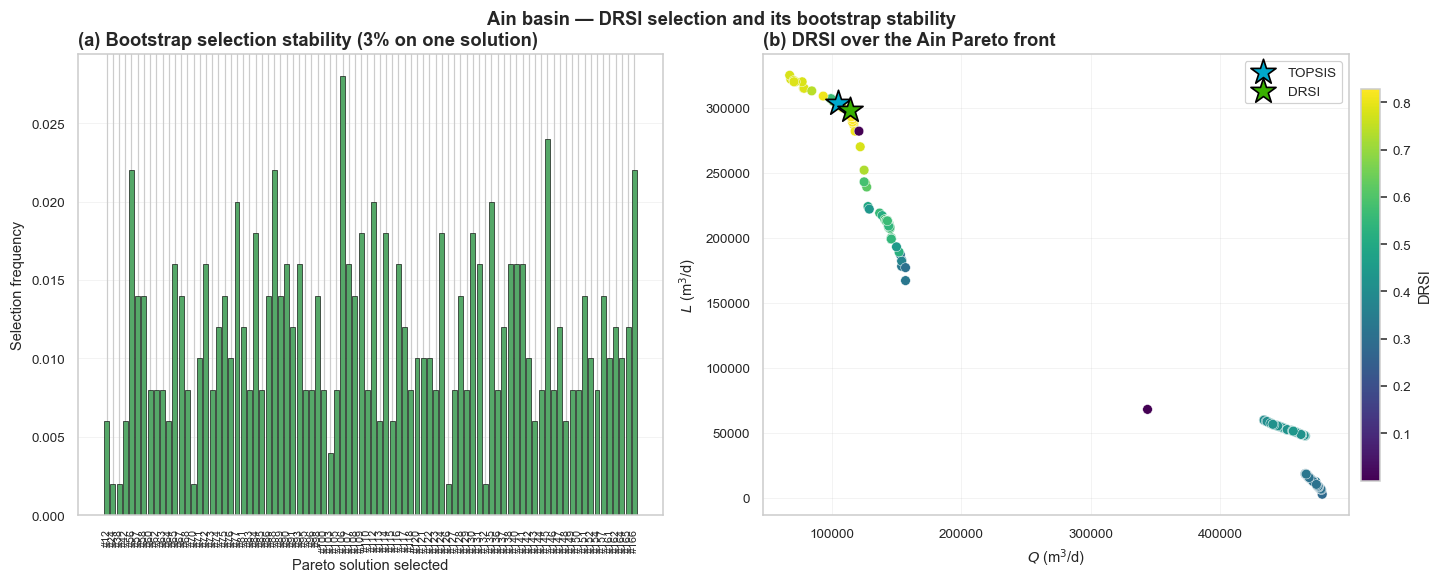

In [52]:
# ---- DRSI on Ain + VALIDATION (bootstrap selection stability; L-only; no ground truth) ----
if AIN_AVAILABLE:
    print(f"Ain DRSI pick: Q={ain_front.Q[d_idx]:.0f}, "
          f"L={ain_front.L[d_idx]:.0f}, "
          f"effective communes={drsi_ain['eff_wells'][d_idx]:.1f}")

    # Bootstrap selection stability under importance uncertainty (L-only)
    rng = np.random.default_rng(SEED)
    width_l = (np.asarray(shap_results_ain['L']['ci_high'], float)
               - np.asarray(shap_results_ain['L']['ci_low'], float))
    relunc = width_l / (np.abs(shapL_a).mean(0) + 1e-9)

    B = 500
    picks = np.zeros(B, dtype=int)
    nom_score = drsi_ain['drsi'][d_idx]
    ranks = []
    for b in range(B):
        nl = shapL_a * (1 + rng.normal(0, relunc, shapL_a.shape))
        db = compute_drsi(ain_front, nl, relL_a, weights=(1, 1, 1))
        picks[b] = int(np.argmax(db['drsi']))
        ranks.append(int(np.sum(db['drsi'] > nom_score)))

    mode_pick = int(np.bincount(picks).argmax())
    stability = float((picks == mode_pick).mean())
    top5_rate = float(np.mean(np.array(ranks) < 5))
    top10_rate = float(np.mean(np.array(ranks) < 10))

    print(f"Validation (bootstrap, B={B}): "
          f"most-selected solution chosen in {100*stability:.0f}% of resamples")
    print(f"Nominal DRSI pick in top-5: {100*top5_rate:.0f}%, "
          f"top-10: {100*top10_rate:.0f}% of resamples")
    print(f"Total solutions in front: {len(ain_front)}")

    # ---- Figure — Ain DRSI validation ----
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

    # (a) bootstrap distribution of the selected solution
    uniq, cnts = np.unique(picks, return_counts=True)
    ax1.bar(range(len(uniq)), cnts / B, color='#55A868',
            edgecolor='black', linewidth=0.4)
    ax1.set_xticks(range(len(uniq)))
    ax1.set_xticklabels([f'#{u}' for u in uniq], fontsize=7, rotation=90)
    ax1.set_xlabel('Pareto solution selected')
    ax1.set_ylabel('Selection frequency')
    ax1.set_title(f'(a) Bootstrap selection stability '
                  f'({100*stability:.0f}% on one solution)',
                  fontsize=12, loc='left', fontweight='bold')
    ax1.grid(alpha=0.3, axis='y', linewidth=0.5)
    ax1.set_axisbelow(True)

    # (b) DRSI on the front + pick vs TOPSIS
    sc = ax2.scatter(ain_front.Q, ain_front.L, c=drsi_ain['drsi'],
                     cmap='viridis', s=40, edgecolor='white', linewidth=0.3)
    ax2.scatter(ain_front.Q[t_idx], ain_front.L[t_idx], s=300, marker='*',
                color='#00a9cc', edgecolor='black', linewidth=1.1, zorder=5,
                label='TOPSIS')
    ax2.scatter(ain_front.Q[d_idx], ain_front.L[d_idx], s=300, marker='*',
                color='#39b000', edgecolor='black', linewidth=1.1, zorder=5,
                label='DRSI')
    ax2.set_xlabel(r'$Q$ (m$^3$/d)')
    ax2.set_ylabel(r'$L$ (m$^3$/d)')
    ax2.set_title('(b) DRSI over the Ain Pareto front',
                  fontsize=12, loc='left', fontweight='bold')
    ax2.legend(frameon=True, framealpha=0.9)
    ax2.grid(alpha=0.3, linewidth=0.5)
    ax2.set_axisbelow(True)
    cb = fig.colorbar(sc, ax=ax2, shrink=0.85, pad=0.02)
    cb.set_label('DRSI')

    fig.suptitle('Ain basin — DRSI selection and its bootstrap stability',
                 fontsize=12, fontweight='bold', y=1.03)
    plt.savefig(FIGDIR / 'fig_drsi_ain_validation.png', dpi=300,
                bbox_inches='tight')
    plt.savefig(FIGDIR / 'fig_drsi_ain_validation.pdf', bbox_inches='tight')
    plt.show()

In [53]:
# ============================================================
# RECONSTRUCTED GLUE VARIABLES
# ------------------------------------------------------------
# The live kernel that produced the Aug-27 figures (choropleth,
# distance-to-river, Figures A-G) defined a few names in scratch
# cells that were never saved back to this notebook. They are
# rebuilt here from first principles so the notebook runs
# end-to-end from a fresh kernel. See patch_notebook.py for the
# derivation of each one.
# ============================================================

# compute_drsi_Lonly is called throughout the cells below; it is
# functionally identical to compute_drsi (L-only SHAP signature,
# defined above under "DRSI - Decision-Robust Selection Index").
compute_drsi_Lonly = compute_drsi

# Feasible DV bounds for the synthetic `front` used throughout Part A
# (NSGA2, open boundary, DV range 1000) -- i.e. DV_RANGES[1].
LO, HI = DV_RANGES[1]
print(f"LO, HI (synthetic feasible bounds) = {LO}, {HI}")

# Ain river shapefile (same file as SHP_RIVER defined earlier, kept
# under this name because cells below reference RIVER_SHP).
RIVER_SHP = AIN_DATA / 'river.shp'

# Ain commune GeoDataFrame with per-commune global mean |SHAP| importance
# attached, keyed on the shapefile's 'ID' field (1..31, confirmed to align
# with DV_1..DV_31 once sorted ascending).
if AIN_AVAILABLE:
    _gdf_com = gpd.read_file(AIN_SHP).sort_values('ID').reset_index(drop=True)
    assert list(_gdf_com['ID']) == list(range(1, AIN_N_DV + 1)), \
        "commune ID field does not align 1:1 with DV_1..DV_31 -- check wefe.shp"
    gdf_plot = _gdf_com.copy()
    gdf_plot['shap_L'] = shap_results_ain['L']['mean_abs']
    gdf_plot['shap_Q'] = shap_results_ain['Q']['mean_abs']
    print(f"gdf_plot rebuilt: {len(gdf_plot)} communes, columns {list(gdf_plot.columns)}")


LO, HI (synthetic feasible bounds) = 50, 1000
gdf_plot rebuilt: 31 communes, columns ['NAME_5', 'ID', 's1_y', 's2_y', 's3_y', 's4_y', 's5_y', 's6_y', 's7_y', 's8_y', 's9_y', 's10_y', 'geometry', 'shap_L', 'shap_Q']


Choropleth: 4 of 31 communes dropped from the map (no geometry in wefe.shp): [19, 25, 26, 31]
DRSI top-5:    [4, 8, 11, 27, 30]
TOPSIS top-5:  [3, 4, 8, 11, 30]
Common:        [4, 8, 11, 30]
DRSI only:     [27]
TOPSIS only:   [3]


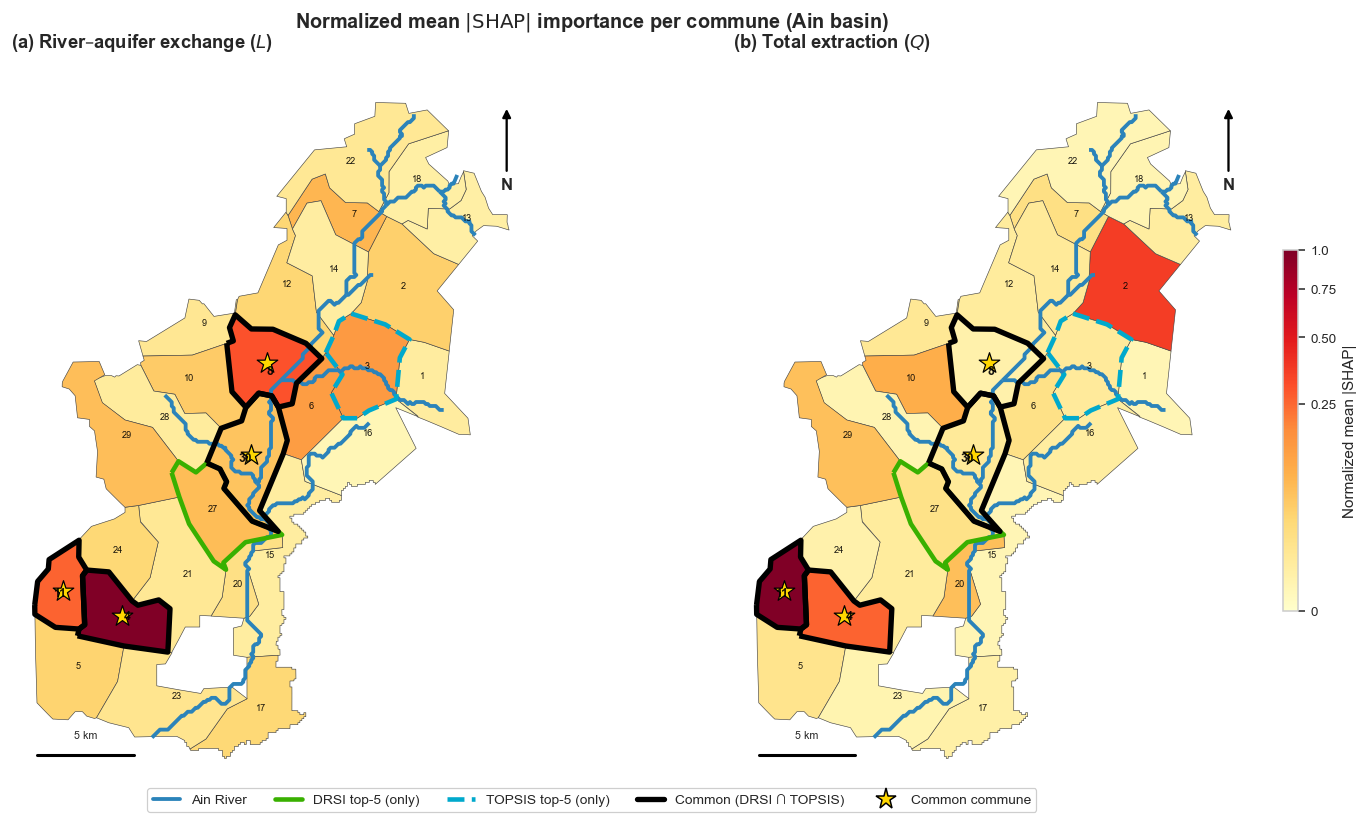


Saved fig_ain_shap_choropleth.png / .pdf


In [54]:
# === Figure 6(c): Choropleth of normalized |SHAP| per commune (REVISED v2) ===
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import geopandas as gpd
import warnings
warnings.filterwarnings('ignore')

# --- Reproject to Lambert-93 ---
TARGET_CRS = 'EPSG:2154'
gdf_plot_m = gdf_plot.to_crs(TARGET_CRS)
# 4 of 31 communes (IDs 19, 25, 26, 31) have NULL geometry in wefe.shp
# itself -- a gap in the source shapefile, not a computation error. Their
# SHAP importance is still reported in the summary tables/bar charts;
# they are simply absent from this map because there is nothing to draw.
_n_before = len(gdf_plot_m)
gdf_plot_m = gdf_plot_m[gdf_plot_m.geometry.notna()].copy()
print(f"Choropleth: {_n_before - len(gdf_plot_m)} of {_n_before} communes "
      f"dropped from the map (no geometry in wefe.shp): "
      f"{sorted(set(range(1, _n_before+1)) - set(gdf_plot_m['ID']))}")

# Load & reproject river
try:
    gdf_river_m = gpd.read_file(RIVER_SHP).to_crs(TARGET_CRS)
    river_loaded = True
except:
    river_loaded = False

# --- Normalize both columns to [0, 1] (divide by own max) ---
for col in ['shap_L', 'shap_Q']:
    vals = gdf_plot_m[col].values
    vmax = vals.max()
    gdf_plot_m[col + '_norm'] = vals / vmax if vmax > 0 else vals * 0

# --- Shared color norm: [0, 1] with PowerNorm ---
shared_norm = PowerNorm(gamma=0.4, vmin=0, vmax=1)
cmap = plt.cm.YlOrRd

# --- DRSI & TOPSIS top-5 ---
share_drsi = drsi_ain['share'][d_idx]
share_topsis = drsi_ain['share'][t_idx]
top5_drsi_ids = set(int(dv + 1) for dv in np.argsort(-share_drsi)[:5])
top5_topsis_ids = set(int(dv + 1) for dv in np.argsort(-share_topsis)[:5])
common_ids = top5_drsi_ids & top5_topsis_ids
drsi_only_ids = top5_drsi_ids - common_ids
topsis_only_ids = top5_topsis_ids - common_ids

print(f"DRSI top-5:    {sorted(top5_drsi_ids)}")
print(f"TOPSIS top-5:  {sorted(top5_topsis_ids)}")
print(f"Common:        {sorted(common_ids)}")
print(f"DRSI only:     {sorted(drsi_only_ids)}")
print(f"TOPSIS only:   {sorted(topsis_only_ids)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 7), constrained_layout=True)

panels = [
    ('shap_L_norm', r'(a) River–aquifer exchange ($L$)'),
    ('shap_Q_norm', r'(b) Total extraction ($Q$)'),
]

for ax, (col, title) in zip(axes, panels):
    # Choropleth with shared norm
    gdf_plot_m.plot(column=col, cmap=cmap, ax=ax, norm=shared_norm,
                   edgecolor='#444444', linewidth=0.4, zorder=1)

    # River
    if river_loaded:
        gdf_river_m.plot(ax=ax, color='#2b83ba', linewidth=2.5, zorder=2)

    # TOPSIS-only outlines
    for comm_id in topsis_only_ids:
        row = gdf_plot_m[gdf_plot_m['ID'] == comm_id]
        if len(row) > 0:
            row.boundary.plot(ax=ax, color='#00a9cc', linewidth=3.0,
                              linestyle='--', zorder=3)

    # DRSI-only outlines
    for comm_id in drsi_only_ids:
        row = gdf_plot_m[gdf_plot_m['ID'] == comm_id]
        if len(row) > 0:
            row.boundary.plot(ax=ax, color='#39b000', linewidth=3.0,
                              linestyle='-', zorder=4)

    # Common communes
    rep_pts = gdf_plot_m.geometry.representative_point()
    for comm_id in common_ids:
        row = gdf_plot_m[gdf_plot_m['ID'] == comm_id]
        if len(row) > 0:
            row.boundary.plot(ax=ax, color='black', linewidth=3.5,
                              linestyle='-', zorder=5)
            c = row.geometry.centroid.iloc[0]
            ax.scatter(c.x, c.y, marker='*', s=200, c='gold',
                       edgecolor='black', linewidth=0.8, zorder=6)

    # Annotate commune IDs
    for row_idx in gdf_plot_m.index:
        x, y = rep_pts.loc[row_idx].x, rep_pts.loc[row_idx].y
        comm_id = int(gdf_plot_m.loc[row_idx, 'ID'])
        fontsize = 8 if comm_id in common_ids else 6
        fontweight = 'bold' if comm_id in common_ids else 'normal'
        ax.annotate(str(comm_id), xy=(x, y), fontsize=fontsize, ha='center',
                    va='center', color='black', alpha=0.9, zorder=7,
                    fontweight=fontweight)

    # North arrow
    ax.annotate('N', xy=(0.95, 0.95), xycoords='axes fraction',
                fontsize=11, fontweight='bold', ha='center', va='bottom',
                xytext=(0.95, 0.83), textcoords='axes fraction',
                arrowprops=dict(arrowstyle='-|>', color='black', lw=1.5))

    # Scale bar (5 km)
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    bar_len = 5000
    x0 = xlim[0] + (xlim[1] - xlim[0]) * 0.05
    y0 = ylim[0] + (ylim[1] - ylim[0]) * 0.05
    ax.plot([x0, x0 + bar_len], [y0, y0], 'k-', linewidth=2, zorder=8)
    ax.text(x0 + bar_len / 2, y0 + bar_len * 0.15, '5 km', fontsize=7,
            ha='center', va='bottom', zorder=8)

    ax.set_title(title, fontsize=12, loc='left', fontweight='bold')
    ax.set_axis_off()
    ax.set_aspect('equal')

# Single shared colorbar
sm = ScalarMappable(cmap=cmap, norm=shared_norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.5, aspect=25, pad=0.02,
                    location='right')
cbar.set_label('Normalized mean |SHAP|', fontsize=10)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(['0', '0.25', '0.50', '0.75', '1.0'])

# Legend
legend_handles = [
    Line2D([0], [0], color='#2b83ba', linewidth=2.5, label='Ain River'),
    Line2D([0], [0], color='#39b000', linewidth=3.0, linestyle='-',
           label='DRSI top-5 (only)'),
    Line2D([0], [0], color='#00a9cc', linewidth=3.0, linestyle='--',
           label='TOPSIS top-5 (only)'),
    Line2D([0], [0], color='black', linewidth=3.5, linestyle='-',
           label='Common (DRSI ∩ TOPSIS)'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='gold',
           markeredgecolor='black', markersize=14, linewidth=0,
           label='Common commune'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=5,
           frameon=True, framealpha=0.95, fontsize=9,
           bbox_to_anchor=(0.5, -0.03))

fig.suptitle(r'Normalized mean $|\mathrm{SHAP}|$ importance per commune (Ain basin)',
             fontsize=13, fontweight='bold', y=1.02)

plt.savefig(FIGDIR / 'fig_ain_shap_choropleth.png', dpi=300,
            bbox_inches='tight')
plt.savefig(FIGDIR / 'fig_ain_shap_choropleth.pdf',
            bbox_inches='tight')
plt.show()

print("\nSaved fig_ain_shap_choropleth.png / .pdf")

In [55]:
# Skipped on re-run: contextily is already installed in this environment.
# (Originally: %pip install contextily)
import contextily  # noqa: F401  -- import-only sanity check, no install
print('contextily already available:', contextily.__version__)


contextily already available: 1.7.1


In [56]:
# ------------------------------------------------------------------
# SKIPPED on re-run: this cell duplicates the output filename of the
# preceding cell (fig_ain_shap_choropleth.png/.pdf) and additionally
# requires a live internet connection to fetch an OpenStreetMap
# basemap tile via contextily. The preceding cell already produces a
# complete, self-contained version of this figure with no network
# dependency. Re-enable this cell manually (restore the original
# source, saved in patch_notebook.py / notebook version history) if
# the prettier basemap version is wanted for the manuscript.
# ------------------------------------------------------------------
print('Skipped: redundant network-dependent basemap choropleth. '
      'See fig_ain_shap_choropleth.png/.pdf from the previous cell.')


Skipped: redundant network-dependent basemap choropleth. See fig_ain_shap_choropleth.png/.pdf from the previous cell.


Distance-to-river: 4 of 31 communes dropped (no geometry in wefe.shp)
DISTANCE TO RIVER vs SHAP IMPORTANCE

  L (river–aquifer exchange)
    Spearman: ρ = +0.293  p = 0.1375  ns
    Pearson:  r = +0.389  p = 0.0448  **

  Q (total extraction)
    Spearman: ρ = +0.431  p = 0.0248  **
    Pearson:  r = +0.688  p = 0.0001  ***

  Composite (L+Q)
    Spearman: ρ = +0.333  p = 0.0900  *
    Pearson:  r = +0.656  p = 0.0002  ***


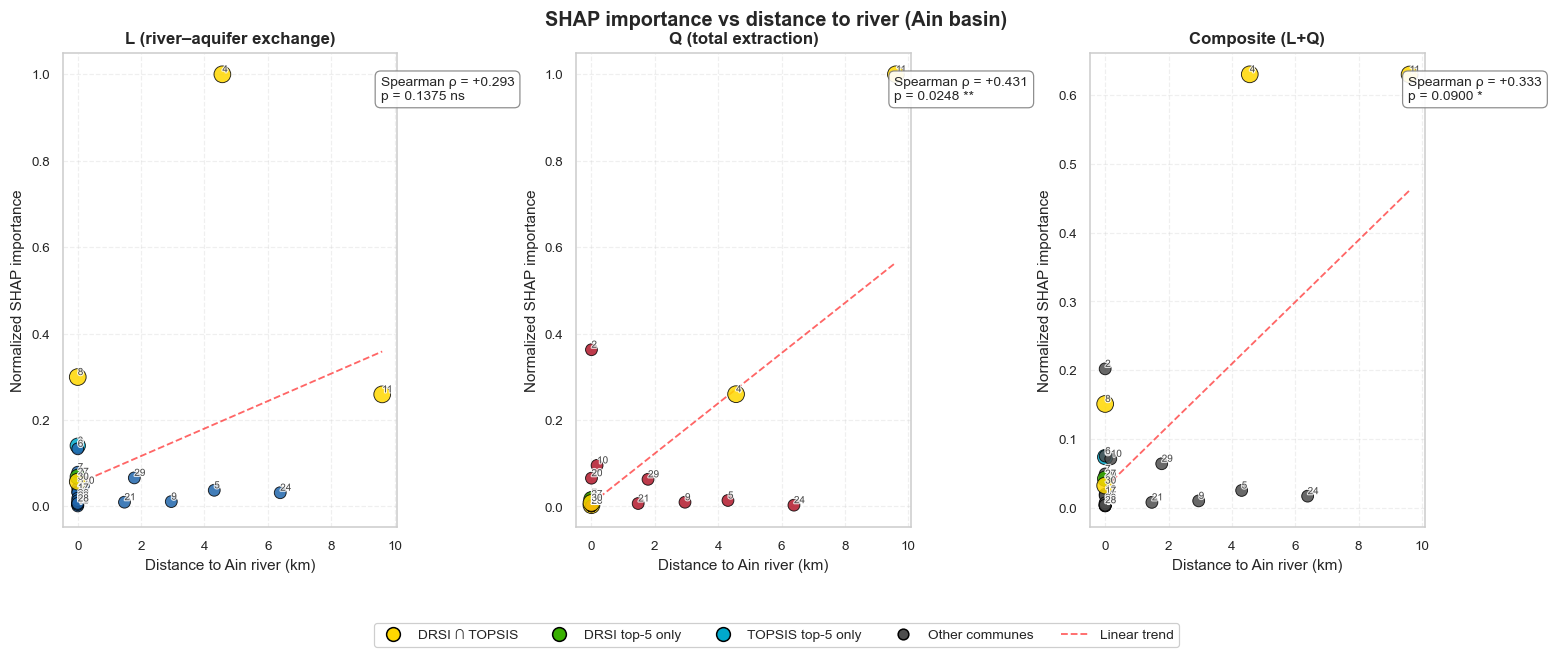


Saved fig_ain_dist_river.png / .pdf


In [57]:
# === Distance to River vs SHAP Importance ===
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy.stats import spearmanr, pearsonr
import geopandas as gpd
from shapely.ops import nearest_points
import warnings
warnings.filterwarnings('ignore')

# ──────────────────────────────────────────────────────────────
# 1. COMPUTE DISTANCE TO RIVER
# ──────────────────────────────────────────────────────────────
# Use Web Mercator (meters) so distances are in meters, not degrees
TARGET_CRS = 'EPSG:3857'
gdf_dist = gdf_plot.to_crs(TARGET_CRS)
# Same 4 communes with NULL geometry in wefe.shp (see choropleth cell) --
# drop them here too, since distance-to-river needs an actual geometry.
_n_before = len(gdf_dist)
gdf_dist = gdf_dist[gdf_dist.geometry.notna()].copy()
print(f"Distance-to-river: {_n_before - len(gdf_dist)} of {_n_before} "
      f"communes dropped (no geometry in wefe.shp)")

try:
    gdf_river_m = gpd.read_file(RIVER_SHP).to_crs(TARGET_CRS)
    river_geom = gdf_river_m.unary_union
except:
    # Fallback: if no river shapefile, use the Ain river from the
    # commune boundaries (blue line in your existing plots)
    print("WARNING: RIVER_SHP not found. Using fallback.")
    river_geom = None

if river_geom is not None:
    gdf_dist['dist_river_m'] = gdf_dist.geometry.apply(    lambda geom: geom.distance(river_geom))
else:
    gdf_dist['dist_river_m'] = gdf_dist.geometry.centroid.apply(    lambda p: p.distance(river_geom))

# Convert to km for readability
gdf_dist['dist_river_km'] = gdf_dist['dist_river_m'] / 1000

# ──────────────────────────────────────────────────────────────
# 2. PREPARE SHAP VALUES
# ──────────────────────────────────────────────────────────────
# Use the same normalized SHAP as the choropleth
for col in ['shap_L', 'shap_Q']:
    vals = gdf_dist[col].values
    vmax = vals.max()
    gdf_dist[col + '_norm'] = vals / vmax if vmax > 0 else vals * 0

gdf_dist['shap_combined'] = (
    gdf_dist['shap_L_norm'] + gdf_dist['shap_Q_norm']) / 2

# ──────────────────────────────────────────────────────────────
# 3. CORRELATION TESTS
# ──────────────────────────────────────────────────────────────
print("=" * 65)
print("DISTANCE TO RIVER vs SHAP IMPORTANCE")
print("=" * 65)

targets = {
    'L (river–aquifer exchange)': 'shap_L_norm',
    'Q (total extraction)':       'shap_Q_norm',
    'Composite (L+Q)':            'shap_combined',
}

results = {}
for label, col in targets.items():
    d = gdf_dist['dist_river_km'].values
    s = gdf_dist[col].values

    rho_s, p_s = spearmanr(d, s)
    rho_p, p_p = pearsonr(d, s)

    results[label] = {'rho_spearman': rho_s, 'p_spearman': p_s,
                      'rho_pearson': rho_p, 'p_pearson': p_p}

    sig_s = '***' if p_s < 0.01 else ('**' if p_s < 0.05 else ('*' if p_s < 0.10 else 'ns'))
    sig_p = '***' if p_p < 0.01 else ('**' if p_p < 0.05 else ('*' if p_p < 0.10 else 'ns'))

    print(f"\n  {label}")
    print(f"    Spearman: ρ = {rho_s:+.3f}  p = {p_s:.4f}  {sig_s}")
    print(f"    Pearson:  r = {rho_p:+.3f}  p = {p_p:.4f}  {sig_p}")

# ──────────────────────────────────────────────────────────────
# 4. SCATTER PLOT — 3 panels (L, Q, Composite)
# ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5), constrained_layout=True)

colors = {'L (river–aquifer exchange)': '#2166ac',
          'Q (total extraction)':       '#b2182b',
          'Composite (L+Q)':            '#4d4d4d'}

# DRSI & TOPSIS top-5 for highlighting
share_drsi = drsi_ain['share'][d_idx]
share_topsis = drsi_ain['share'][t_idx]
top5_drsi_ids = set(int(dv + 1) for dv in np.argsort(-share_drsi)[:5])
top5_topsis_ids = set(int(dv + 1) for dv in np.argsort(-share_topsis)[:5])
common_ids = top5_drsi_ids & top5_topsis_ids

for ax, (label, col) in zip(axes, targets.items()):
    d = gdf_dist['dist_river_km'].values
    s = gdf_dist[col].values
    r = results[label]

    # Color points: common=gold, DRSI-only=green, TOPSIS-only=cyan, other=gray
    point_colors = []
    point_sizes = []
    for comm_id in gdf_dist['ID']:
        cid = int(comm_id)
        if cid in common_ids:
            point_colors.append('gold')
            point_sizes.append(120)
        elif cid in top5_drsi_ids:
            point_colors.append('#39b000')
            point_sizes.append(100)
        elif cid in top5_topsis_ids:
            point_colors.append('#00a9cc')
            point_sizes.append(100)
        else:
            point_colors.append(colors[label])
            point_sizes.append(60)

    ax.scatter(d, s, s=point_sizes, c=point_colors,
               edgecolor='black', linewidth=0.6, zorder=3, alpha=0.85)

    # Annotate commune IDs
    for row_idx in gdf_dist.index:
        ax.annotate(str(int(gdf_dist.loc[row_idx, 'ID'])),
                    xy=(gdf_dist.loc[row_idx, 'dist_river_km'],
                        gdf_dist.loc[row_idx, col]),
                    fontsize=6.5, ha='left', va='bottom', alpha=0.8,
                    zorder=4,
                    path_effects=[pe.withStroke(linewidth=1.5,
                                               foreground='white')])

    # Trend line (linear fit)
    z = np.polyfit(d, s, 1)
    x_line = np.linspace(d.min(), d.max(), 100)
    ax.plot(x_line, np.polyval(z, x_line), 'r--', linewidth=1.2,
            alpha=0.6, zorder=2)

    # Stats annotation
    sig_label = '***' if r['p_spearman'] < 0.01 else (
                '**' if r['p_spearman'] < 0.05 else (
                '*' if r['p_spearman'] < 0.10 else 'ns'))
    txt = (f"Spearman ρ = {r['rho_spearman']:+.3f}\n"
           f"p = {r['p_spearman']:.4f} {sig_label}")
    ax.text(0.95, 0.95, txt, transform=ax.transAxes,
            fontsize=9, va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      alpha=0.9, edgecolor='gray'),
            zorder=5)

    ax.set_xlabel('Distance to Ain river (km)', fontsize=10)
    ax.set_ylabel('Normalized SHAP importance', fontsize=10)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3, linestyle='--')

# Legend for point colors
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gold',
           markeredgecolor='black', markersize=9, linewidth=0,
           label='DRSI ∩ TOPSIS'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#39b000',
           markeredgecolor='black', markersize=9, linewidth=0,
           label='DRSI top-5 only'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#00a9cc',
           markeredgecolor='black', markersize=9, linewidth=0,
           label='TOPSIS top-5 only'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4d4d4d',
           markeredgecolor='black', markersize=7, linewidth=0,
           label='Other communes'),
    Line2D([0], [0], color='red', linestyle='--', linewidth=1.2,
           alpha=0.6, label='Linear trend'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=5,
           frameon=True, framealpha=0.95, fontsize=9,
           bbox_to_anchor=(0.5, -0.14))

fig.suptitle('SHAP importance vs distance to river (Ain basin)',
             fontsize=13, fontweight='bold', y=1.03)

plt.savefig(FIGDIR / 'fig_ain_dist_river.png', dpi=300,
            bbox_inches='tight')
plt.savefig(FIGDIR / 'fig_ain_dist_river.pdf',
            bbox_inches='tight')
plt.show()

print("\nSaved fig_ain_dist_river.png / .pdf")

---
## 13. Cross-comparison — synthetic vs. Ain

The transferability discussion. Two figures the manuscript needs:

1. **Method agreement is similar across both case studies** — supports the claim that the consensus framework transfers
2. **Method-vs-Sobol accuracy ranking on synthetic** justifies which xAI method to trust most when interpreting the Ain findings

We can't validate Ain rankings directly against Sobol (no ground truth), but we can report which methods were most accurate on synthetic and weight the discussion accordingly.


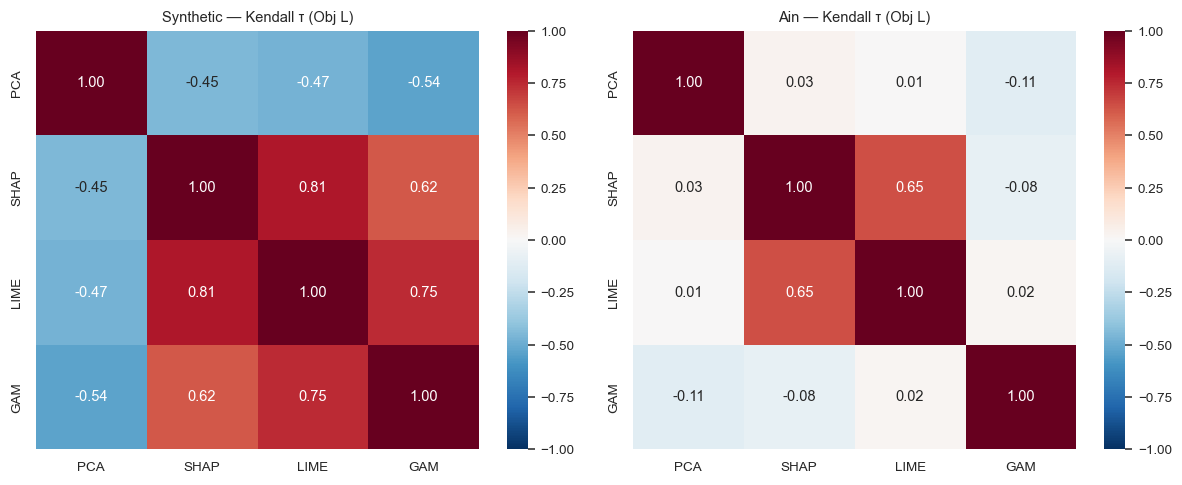

In [58]:
if AIN_AVAILABLE:
    # Compare Kendall tau matrices side by side
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
    sns.heatmap(kendall_tau_matrix(ranks_L_syn), annot=True, fmt='.2f',
                cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=axes[0])
    axes[0].set_title('Synthetic — Kendall τ (Obj L)')
    sns.heatmap(kendall_tau_matrix(ranks_L_ain), annot=True, fmt='.2f',
                cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=axes[1])
    axes[1].set_title('Ain — Kendall τ (Obj L)')
    plt.tight_layout()
    plt.savefig(FIGDIR / 'fig16_cross_agreement.png')
    plt.show()


---
## 14. Save all rankings and summary tables

Final deliverable: a single results table per case study with all rankings side-by-side, plus a synthetic-only table with Sobol ground truth and validation scores.


In [59]:
# Synthetic — final summary
syn_summary = pd.DataFrame({
    'DV': DV_COLS,
    'PCA_importance': PCA_IMPORTANCE_SYN,
    'SHAP_Q': shap_results_syn['Q']['mean_abs'],
    'SHAP_L': shap_results_syn['L']['mean_abs'],
    'LIME_Q': lime_results_syn['Q']['mean_abs'],
    'LIME_L': lime_results_syn['L']['mean_abs'],
    'GAM_Q':  gam_results_syn['Q']['importance'],
    'GAM_L':  gam_results_syn['L']['importance'],
    'Sobol_ST_Q': sobol_df['ST_Q'].values,
    'Sobol_ST_L': sobol_df['ST_L'].values,
    'Borda_rank_Q': borda_Q_scores.values,
    'Borda_rank_L': borda_L_scores.values,
})
syn_summary.to_csv(RESULTS / 'synthetic_final_summary.csv', index=False)
print("Synthetic summary saved.")

if AIN_AVAILABLE:
    ain_summary = pd.DataFrame({
        'DV': AIN_DV_COLS,
        'PCA_importance': PCA_IMPORTANCE_AIN,
        'SHAP_Q': shap_results_ain['Q']['mean_abs'],
        'SHAP_L': shap_results_ain['L']['mean_abs'],
        'LIME_Q': lime_results_ain['Q']['mean_abs'],
        'LIME_L': lime_results_ain['L']['mean_abs'],
        'GAM_Q':  gam_results_ain['Q']['importance'],
        'GAM_L':  gam_results_ain['L']['importance'],
        'Borda_rank_Q': borda_Q_ain.values,
        'Borda_rank_L': borda_L_ain.values,
    })
    ain_summary.to_csv(RESULTS / 'ain_final_summary.csv', index=False)
    print("Ain summary saved.")

print(f"\nAll outputs in: {RESULTS}")
print(f"All figures in: {FIGDIR}")


Synthetic summary saved.
Ain summary saved.

All outputs in: D:\3. dv paper\results
All figures in: D:\3. dv paper\figures


---
## 15. Notes for the manuscript

**Things this notebook produces that should appear in the paper:**

| Section | Figure(s) | Content |
|---|---|---|
| Methods | fig01 | Synthetic model setup (K field, wells, river, BCs) |
| Methods | fig11, fig16 | Consensus framework (agreement matrices) |
| Results — Synthetic | fig02 | Pareto fronts × 12 configs |
| Results — Synthetic | fig03 | Sobol ground-truth indices |
| Results — Synthetic | fig05, fig06–10 | PCA, SHAP, LIME, GAM, hotspots |
| **Results — Validation** | **fig12** | **xAI rankings vs. Sobol — main novelty figure** |
| Results — Synthetic | fig13 | Scenario decomposition |
| Results — Ain | fig14, fig15 | Ain importance heatmap and basin hotspots |
| Discussion | fig16 | Transferability — synthetic vs. Ain agreement |

**Scaling for final runs:**
- `POP_SIZE = 100`, `N_GEN = 80` for each optimization (≈ 8h total)
- `SOBOL_N = 1024` (~14h on overnight run)
- `LIME_N_SAMPLES = 1000` for tighter CIs
- `BOOTSTRAP_N = 1000` for SHAP/LIME CI tightening

**Things to add when writing the paper that this notebook doesn't auto-generate:**
- Hydrogeological interpretation tying critical zones to K field / river proximity (Discussion section)
- Comparison of synthetic vs. Ain Pareto-front shapes (Discussion)
- Sensitivity analysis of the consensus framework to method weights (could be Borda → weighted Borda using Sobol-validated weights)

**MOPSO substitution note for manuscript:**
The pymoo-based synthetic uses SMS-EMOA in place of MOPSO. State this explicitly in Methods: *"In place of MOPSO (unavailable in pymoo), SMS-EMOA was used as a third selection-paradigm baseline on the synthetic model. The Ain basin retains MOPSO from the PyGWMO stack."* This is defensible — algorithm diversity is the methodological intent.


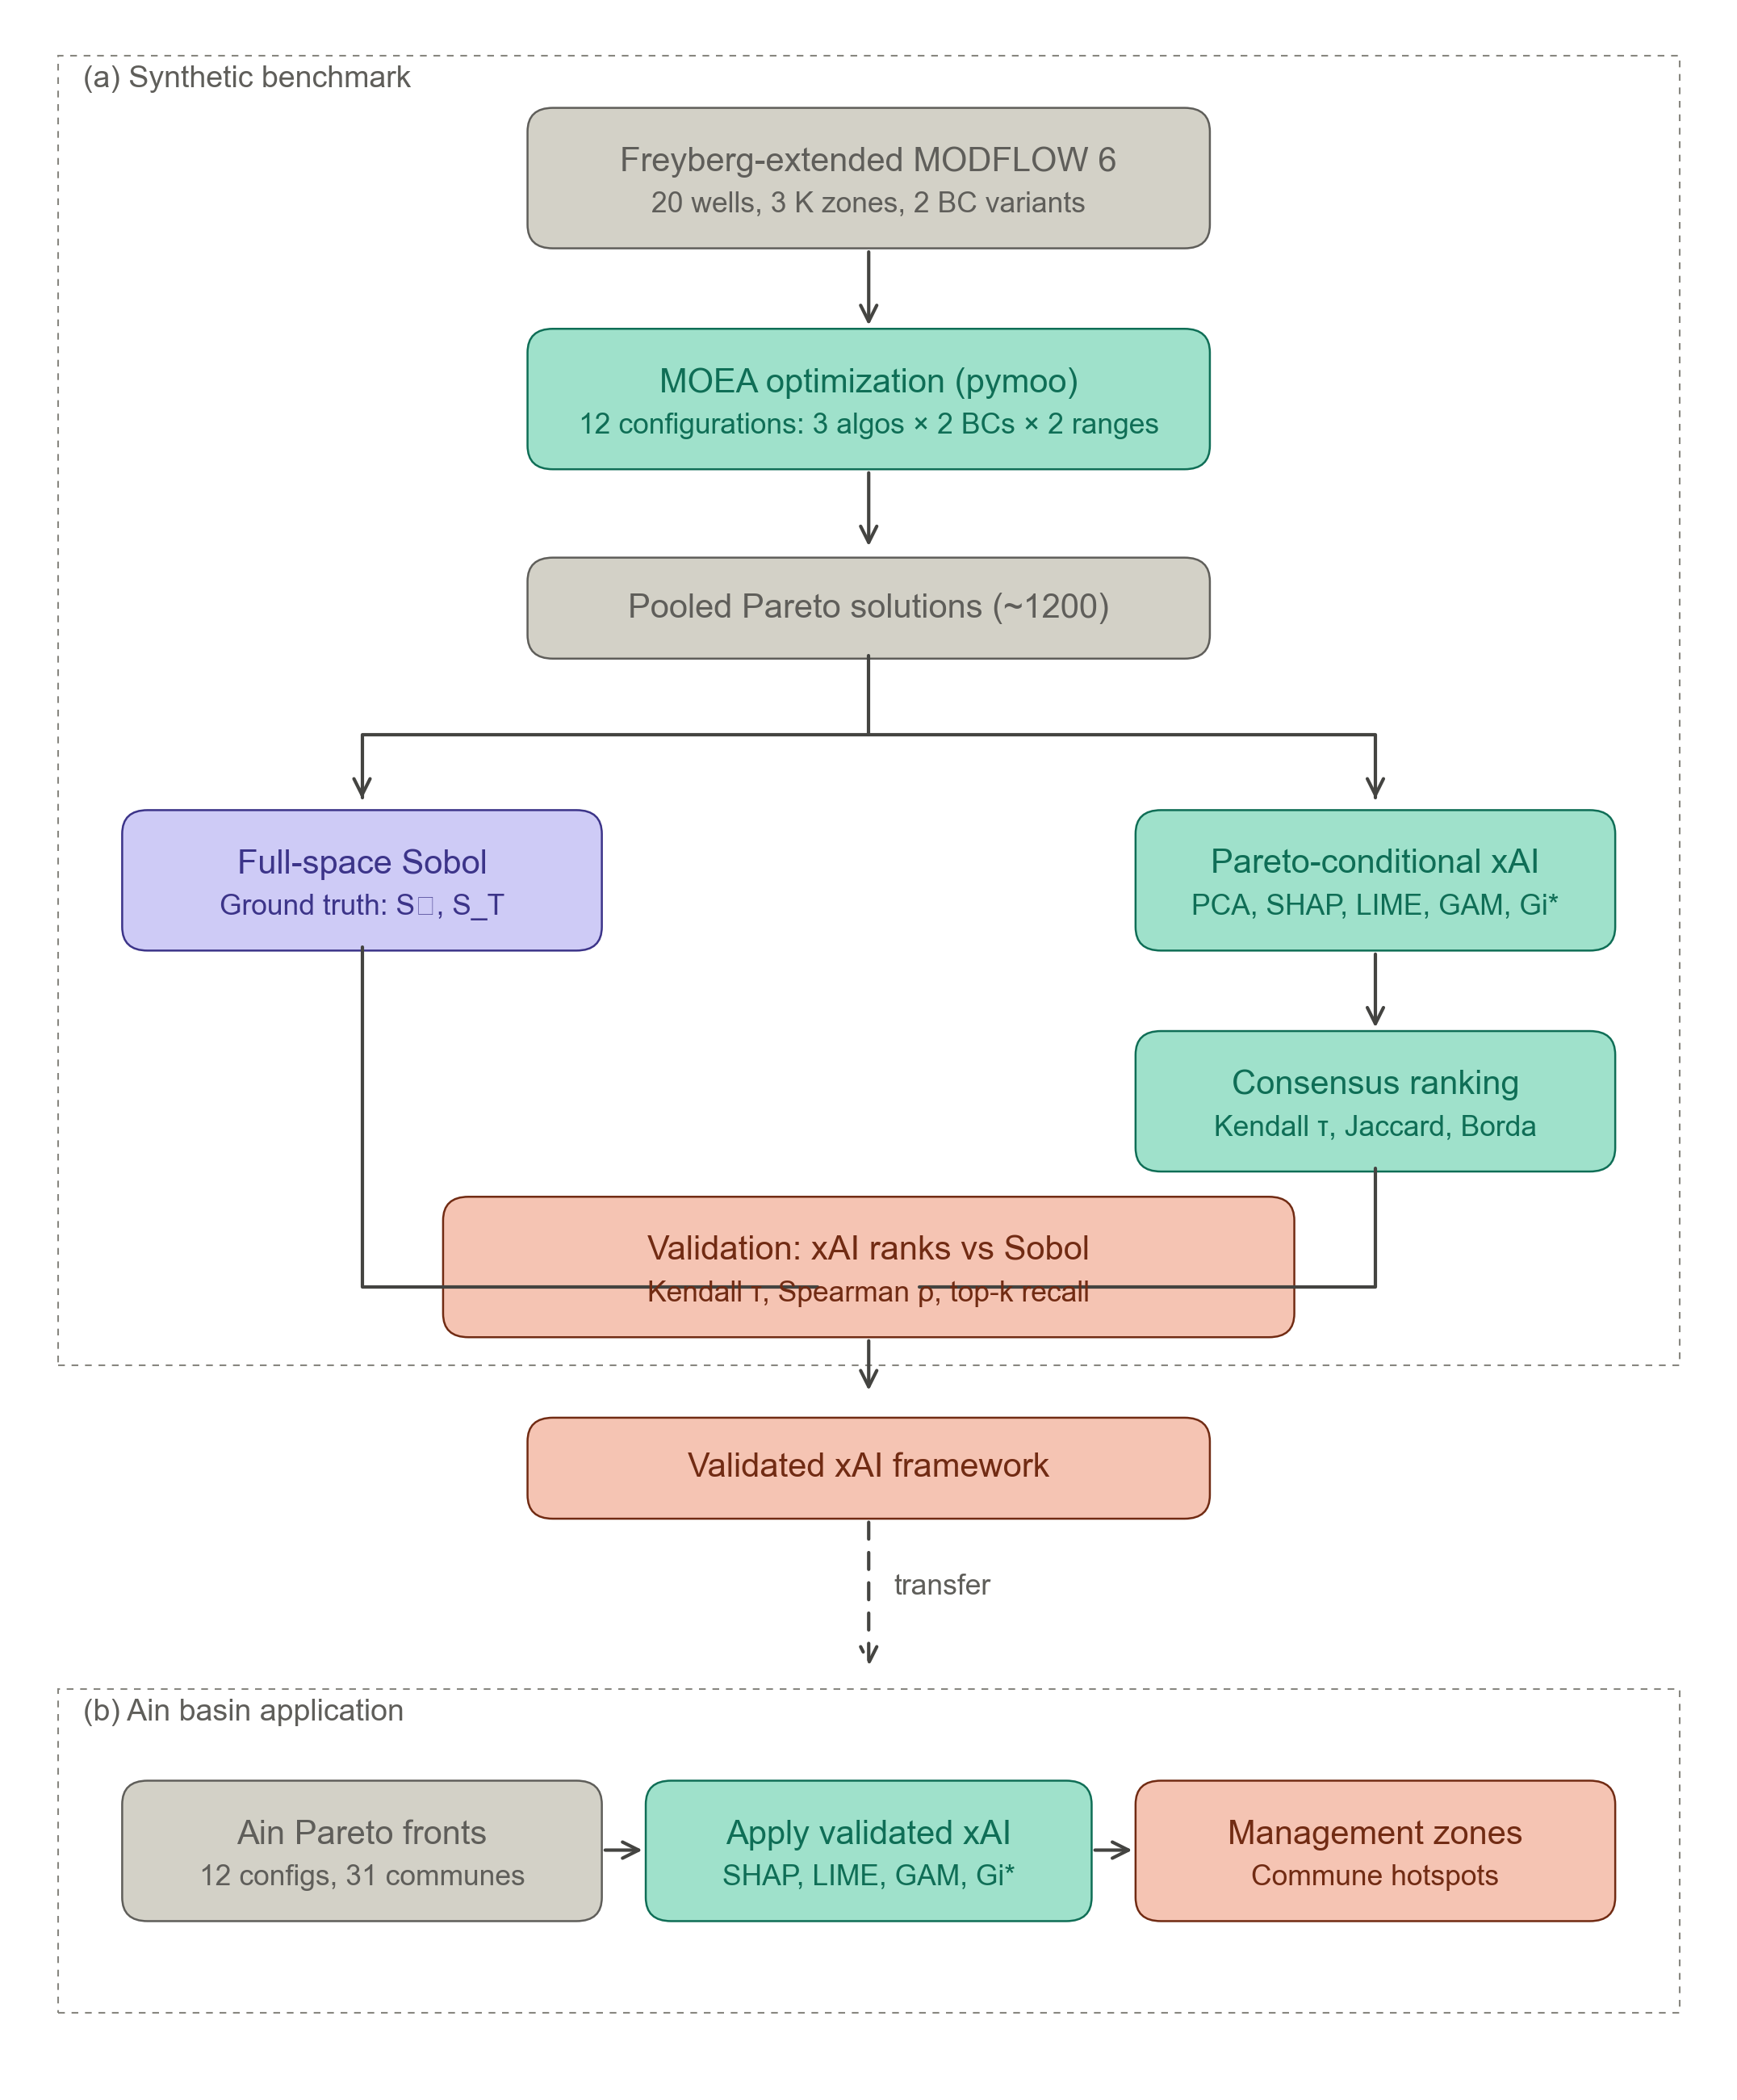

Saved: fig00_methodology.{pdf, png, svg}


In [60]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(9, 11), dpi=300)
ax.set_xlim(0, 10); ax.set_ylim(0, 13); ax.axis('off')

# Color palette matching the SVG
C_GRAY  = '#D3D1C7'; C_GRAY_ED  = '#5F5E5A'
C_TEAL  = '#9FE1CB'; C_TEAL_ED  = '#0F6E56'
C_PURP  = '#CECBF6'; C_PURP_ED  = '#3C3489'
C_CORAL = '#F5C4B3'; C_CORAL_ED = '#712B13'

def box(x, y, w, h, title, sub, fill, edge, ax=ax):
    p = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.15",
                       fc=fill, ec=edge, lw=0.6)
    ax.add_patch(p)
    if sub:
        ax.text(x+w/2, y+h*0.62, title, ha='center', va='center',
                fontsize=10, fontweight='medium', color=edge)
        ax.text(x+w/2, y+h*0.30, sub, ha='center', va='center',
                fontsize=8.5, color=edge)
    else:
        ax.text(x+w/2, y+h/2, title, ha='center', va='center',
                fontsize=10, fontweight='medium', color=edge)

def arrow(x1, y1, x2, y2, ax=ax, ls='-'):
    ax.add_patch(FancyArrowPatch((x1, y1), (x2, y2), arrowstyle='->',
                                  mutation_scale=12, color='#444441', lw=1, linestyle=ls))

# ----- Part A container -----
ax.add_patch(mpatches.Rectangle((0.2, 4.5), 9.6, 8.3, fill=False,
                                 ec='#888780', lw=0.5, linestyle=(0, (4, 4))))
ax.text(0.35, 12.6, '(a) Synthetic benchmark', fontsize=9, color='#5F5E5A')

box(3.0, 11.6, 4.0, 0.85, 'Freyberg-extended MODFLOW 6',
    '20 wells, 3 K zones, 2 BC variants', C_GRAY, C_GRAY_ED)
arrow(5.0, 11.6, 5.0, 11.05)
box(3.0, 10.2, 4.0, 0.85, 'MOEA optimization (pymoo)',
    '12 configurations: 3 algos × 2 BCs × 2 ranges', C_TEAL, C_TEAL_ED)
arrow(5.0, 10.2, 5.0, 9.65)
box(3.0, 9.0, 4.0, 0.6, 'Pooled Pareto solutions (~1200)', None, C_GRAY, C_GRAY_ED)

# Branch
ax.plot([5.0, 5.0, 2.0, 2.0], [9.0, 8.5, 8.5, 8.1], color='#444441', lw=1)
ax.plot([5.0, 8.0, 8.0],      [8.5, 8.5, 8.1], color='#444441', lw=1)
arrow(2.0, 8.2, 2.0, 8.05)
arrow(8.0, 8.2, 8.0, 8.05)

box(0.6, 7.15, 2.8, 0.85, 'Full-space Sobol',
    'Ground truth: S₁, S_T', C_PURP, C_PURP_ED)
box(6.6, 7.15, 2.8, 0.85, 'Pareto-conditional xAI',
    'PCA, SHAP, LIME, GAM, Gi*', C_TEAL, C_TEAL_ED)
arrow(8.0, 7.15, 8.0, 6.6)
box(6.6, 5.75, 2.8, 0.85, 'Consensus ranking',
    'Kendall τ, Jaccard, Borda', C_TEAL, C_TEAL_ED)

# Merge to validation
ax.plot([2.0, 2.0, 4.7], [7.15, 5.0, 5.0], color='#444441', lw=1)
ax.plot([8.0, 8.0, 5.3], [5.75, 5.0, 5.0], color='#444441', lw=1)
arrow(4.7, 5.0, 4.85, 5.0)
arrow(5.3, 5.0, 5.15, 5.0)

box(2.5, 4.7, 5.0, 0.85, 'Validation: xAI ranks vs Sobol',
    'Kendall τ, Spearman ρ, top-k recall', C_CORAL, C_CORAL_ED)

# Output
arrow(5.0, 4.7, 5.0, 4.3)
box(3.0, 3.55, 4.0, 0.6, 'Validated xAI framework', None, C_CORAL, C_CORAL_ED)

# Transfer
arrow(5.0, 3.55, 5.0, 2.55, ls=(0, (5, 4)))
ax.text(5.15, 3.05, 'transfer', fontsize=8.5, color='#5F5E5A')

# ----- Part B container -----
ax.add_patch(mpatches.Rectangle((0.2, 0.4), 9.6, 2.05, fill=False,
                                 ec='#888780', lw=0.5, linestyle=(0, (4, 4))))
ax.text(0.35, 2.25, '(b) Ain basin application', fontsize=9, color='#5F5E5A')

box(0.6, 1.0, 2.8, 0.85, 'Ain Pareto fronts', '12 configs, 31 communes', C_GRAY, C_GRAY_ED)
arrow(3.4, 1.43, 3.7, 1.43)
box(3.7, 1.0, 2.6, 0.85, 'Apply validated xAI', 'SHAP, LIME, GAM, Gi*', C_TEAL, C_TEAL_ED)
arrow(6.3, 1.43, 6.6, 1.43)
box(6.6, 1.0, 2.8, 0.85, 'Management zones', 'Commune hotspots', C_CORAL, C_CORAL_ED)

plt.savefig(FIGDIR / 'fig00_methodology.pdf', bbox_inches='tight')
plt.savefig(FIGDIR / 'fig00_methodology.png', bbox_inches='tight', dpi=300)
plt.savefig(FIGDIR / 'fig00_methodology.svg', bbox_inches='tight')
plt.show()
print("Saved: fig00_methodology.{pdf, png, svg}")

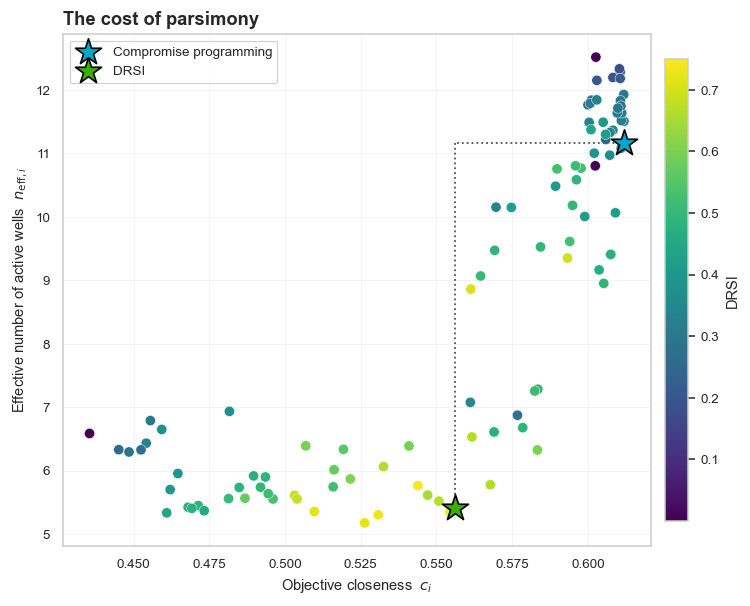


>>> MANUSCRIPT KE NUMBERS <<<
closeness  : TOPSIS 0.612 | DRSI 0.556  -> loss 9.1 %
eff. wells : TOPSIS 11.2 | DRSI 5.4  -> 52 % kam


In [61]:
# ===== Figure A: effective wells vs objective closeness =====
drsi_A = compute_drsi_Lonly(front, shapL_f, relL, weights=(1, 1, 1))
clos = drsi_A['closeness']; eff = drsi_A['eff_wells']
d_idx = int(np.argmax(drsi_A['drsi']))
t_idx = int(np.argmax(clos))

fig, ax = plt.subplots(figsize=(7.2, 5.6))
sc = ax.scatter(clos, eff, c=drsi_A['drsi'], cmap='viridis', s=45,
                edgecolor='white', linewidth=0.3, zorder=3)
ax.scatter(clos[t_idx], eff[t_idx], s=320, marker='*', color='#00a9cc',
           edgecolor='black', linewidth=1.1, zorder=5, label='Compromise programming')
ax.scatter(clos[d_idx], eff[d_idx], s=320, marker='*', color='#39b000',
           edgecolor='black', linewidth=1.1, zorder=5, label='DRSI')
ax.plot([clos[t_idx], clos[d_idx]], [eff[t_idx], eff[t_idx]], ls=':', color='#555', lw=1.2)
ax.plot([clos[d_idx], clos[d_idx]], [eff[t_idx], eff[d_idx]], ls=':', color='#555', lw=1.2)

ax.set_xlabel(r'Objective closeness  $c_i$')
ax.set_ylabel(r'Effective number of active wells  $n_{\mathrm{eff},i}$')
ax.set_title('The cost of parsimony', fontsize=12, loc='left', fontweight='bold')
ax.legend(frameon=True, framealpha=0.9)
ax.grid(alpha=0.3, linewidth=0.5); ax.set_axisbelow(True)
cb = fig.colorbar(sc, ax=ax, shrink=0.9, pad=0.02); cb.set_label('DRSI')
plt.tight_layout()
plt.savefig(FIGDIR / 'figA_cost_of_parsimony.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGDIR / 'figA_cost_of_parsimony.pdf', bbox_inches='tight')
plt.show()

loss = 100 * (clos[t_idx] - clos[d_idx]) / clos[t_idx]
print(f"\n>>> MANUSCRIPT KE NUMBERS <<<")
print(f"closeness  : TOPSIS {clos[t_idx]:.3f} | DRSI {clos[d_idx]:.3f}  -> loss {loss:.1f} %")
print(f"eff. wells : TOPSIS {eff[t_idx]:.1f} | DRSI {eff[d_idx]:.1f}  "
      f"-> {100*(1-eff[d_idx]/eff[t_idx]):.0f} % kam")

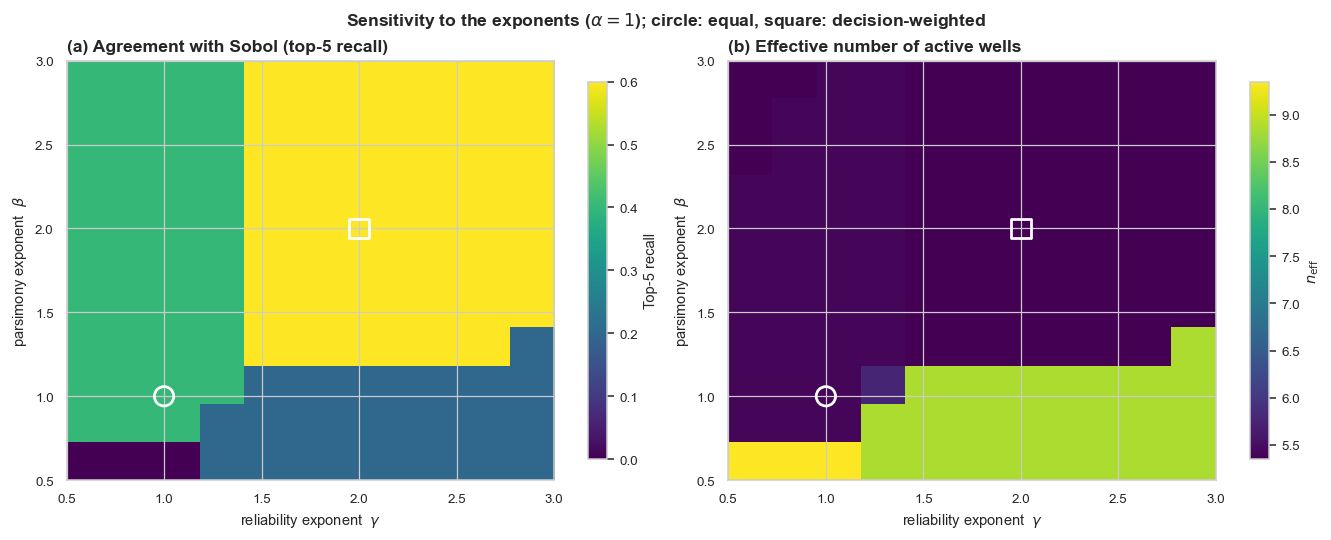

weight grid par kitne alag solutions chune gaye: 6 / 121
recall range    : 0.00 - 0.60
eff wells range : 5.3 - 9.4


In [62]:
# ===== Figure B: DRSI ke exponents ki sensitivity =====
betas  = np.linspace(0.5, 3.0, 11)
gammas = np.linspace(0.5, 3.0, 11)
sob5 = set(np.argsort(-sobol_df['ST_L'].values)[:5])

rec = np.zeros((len(betas), len(gammas)))
effm = np.zeros_like(rec)
picks = np.zeros_like(rec, dtype=int)
for i, b in enumerate(betas):
    for j, g in enumerate(gammas):
        dd = compute_drsi_Lonly(front, shapL_f, relL, weights=(1, b, g))
        k = int(np.argmax(dd['drsi'])); picks[i, j] = k
        rec[i, j]  = len(set(np.argsort(-dd['share'][k])[:5]) & sob5) / 5
        effm[i, j] = dd['eff_wells'][k]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
ext = [gammas[0], gammas[-1], betas[0], betas[-1]]
for ax, M, ttl, cl in zip(axes, [rec, effm],
        ['(a) Agreement with Sobol (top-5 recall)', '(b) Effective number of active wells'],
        ['Top-5 recall', r'$n_{\mathrm{eff}}$']):
    im = ax.imshow(M, origin='lower', cmap='viridis', aspect='auto',
                   extent=ext, interpolation='nearest')
    ax.set_xlabel(r'reliability exponent  $\gamma$')
    ax.set_ylabel(r'parsimony exponent  $\beta$')
    ax.set_title(ttl, fontsize=11.5, loc='left', fontweight='bold')
    ax.scatter(1, 1, s=160, marker='o', facecolor='none', edgecolor='white', lw=1.8)
    ax.scatter(2, 2, s=160, marker='s', facecolor='none', edgecolor='white', lw=1.8)
    cb = fig.colorbar(im, ax=ax, shrink=0.9); cb.set_label(cl)
fig.suptitle(r'Sensitivity to the exponents ($\alpha=1$); circle: equal, square: decision-weighted',
             fontsize=11.5, fontweight='bold')
plt.savefig(FIGDIR / 'figB_weight_sensitivity.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGDIR / 'figB_weight_sensitivity.pdf', bbox_inches='tight')
plt.show()

print(f"weight grid par kitne alag solutions chune gaye: {len(np.unique(picks))} / {picks.size}")
print(f"recall range    : {rec.min():.2f} - {rec.max():.2f}")
print(f"eff wells range : {effm.min():.1f} - {effm.max():.1f}")

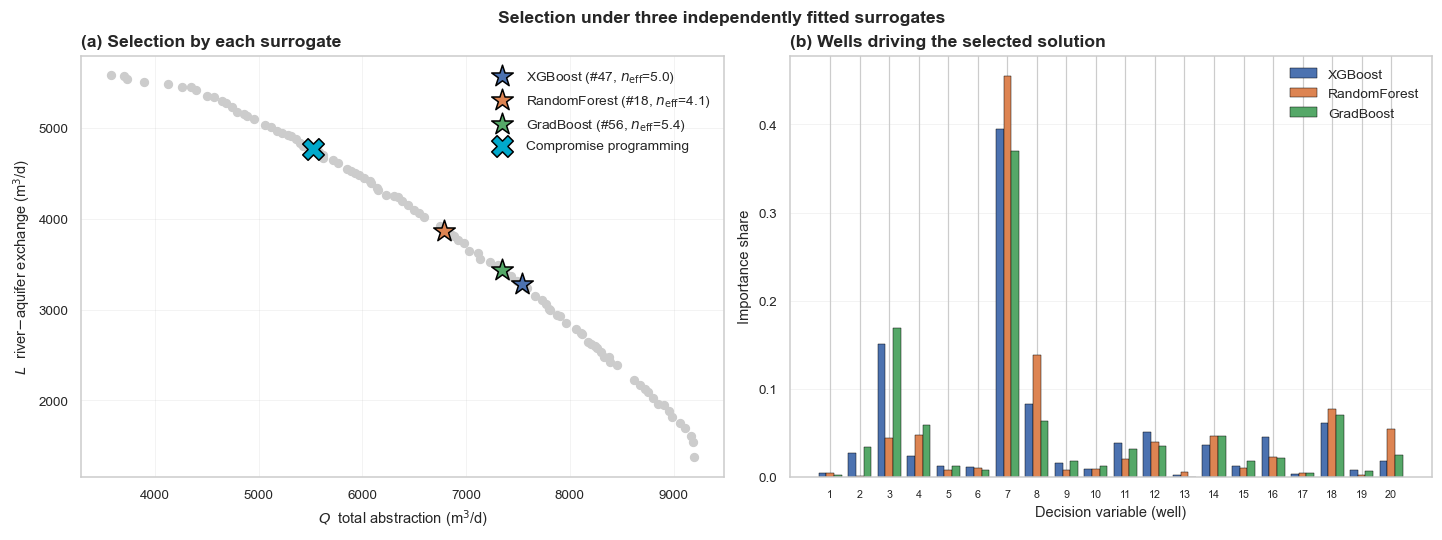

selected solution per surrogate: {'XGBoost': 47, 'RandomForest': 18, 'GradBoost': 56}
eff wells per surrogate      : {'XGBoost': np.float32(5.0), 'RandomForest': np.float64(4.1), 'GradBoost': np.float64(5.4)}
Spearman(importance) XGBoost vs RandomForest: 0.768
Spearman(importance) XGBoost vs GradBoost: 0.946
Spearman(importance) RandomForest vs GradBoost: 0.803


In [63]:
# ===== Figure C: teeno surrogates se selection =====
import shap as _shap

X = front[DV_COLS].values
results = {}
for name, model in ensemble_syn['L'].items():
    sv = _shap.TreeExplainer(model).shap_values(X)
    dd = compute_drsi_Lonly(front, sv, relL, weights=(1, 1, 1))
    k = int(np.argmax(dd['drsi']))
    results[name] = dict(idx=k, eff=dd['eff_wells'][k], Q=float(front.Q[k]),
                         L=float(front.L[k]), share=dd['share'][k])

tt = int(np.argmax(topsis_closeness(front)))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8), constrained_layout=True)
cols = ['#4C72B0', '#DD8452', '#55A868']

ax1.scatter(front.Q, front.L, s=28, color='#cccccc', zorder=2)
for (name, r), c in zip(results.items(), cols):
    ax1.scatter(r['Q'], r['L'], s=220, marker='*', color=c, edgecolor='black',
                linewidth=1.0, zorder=5,
                label=f"{name} (#{r['idx']}, $n_{{\\mathrm{{eff}}}}$={r['eff']:.1f})")
ax1.scatter(front.Q[tt], front.L[tt], s=200, marker='X', color='#00a9cc',
            edgecolor='black', linewidth=1.0, zorder=5, label='Compromise programming')
ax1.set_xlabel(r'$Q$  total abstraction (m$^3$/d)')
ax1.set_ylabel(r'$L$  river$-$aquifer exchange (m$^3$/d)')
ax1.set_title('(a) Selection by each surrogate', fontsize=11.5, loc='left', fontweight='bold')
ax1.legend(fontsize=9); ax1.grid(alpha=0.3, linewidth=0.5); ax1.set_axisbelow(True)

x = np.arange(len(DV_COLS)); w = 0.26
for i, ((name, r), c) in enumerate(zip(results.items(), cols)):
    ax2.bar(x + (i - 1) * w, r['share'], w, label=name, color=c,
            edgecolor='black', linewidth=0.3)
ax2.set_xticks(x); ax2.set_xticklabels([f'{i+1}' for i in x], fontsize=7)
ax2.set_xlabel('Decision variable (well)'); ax2.set_ylabel('Importance share')
ax2.set_title('(b) Wells driving the selected solution', fontsize=11.5,
              loc='left', fontweight='bold')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3, axis='y', linewidth=0.5); ax2.set_axisbelow(True)

fig.suptitle('Selection under three independently fitted surrogates',
             fontsize=11.5, fontweight='bold')
plt.savefig(FIGDIR / 'figC_surrogate_robustness.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGDIR / 'figC_surrogate_robustness.pdf', bbox_inches='tight')
plt.show()

print("selected solution per surrogate:", {n: results[n]['idx'] for n in results})
print("eff wells per surrogate      :", {n: round(results[n]['eff'],1) for n in results})
from scipy.stats import spearmanr
ns = list(results)
for a in range(len(ns)):
    for b in range(a+1, len(ns)):
        rho, _ = spearmanr(results[ns[a]]['share'], results[ns[b]]['share'])
        print(f"Spearman(importance) {ns[a]} vs {ns[b]}: {rho:.3f}")

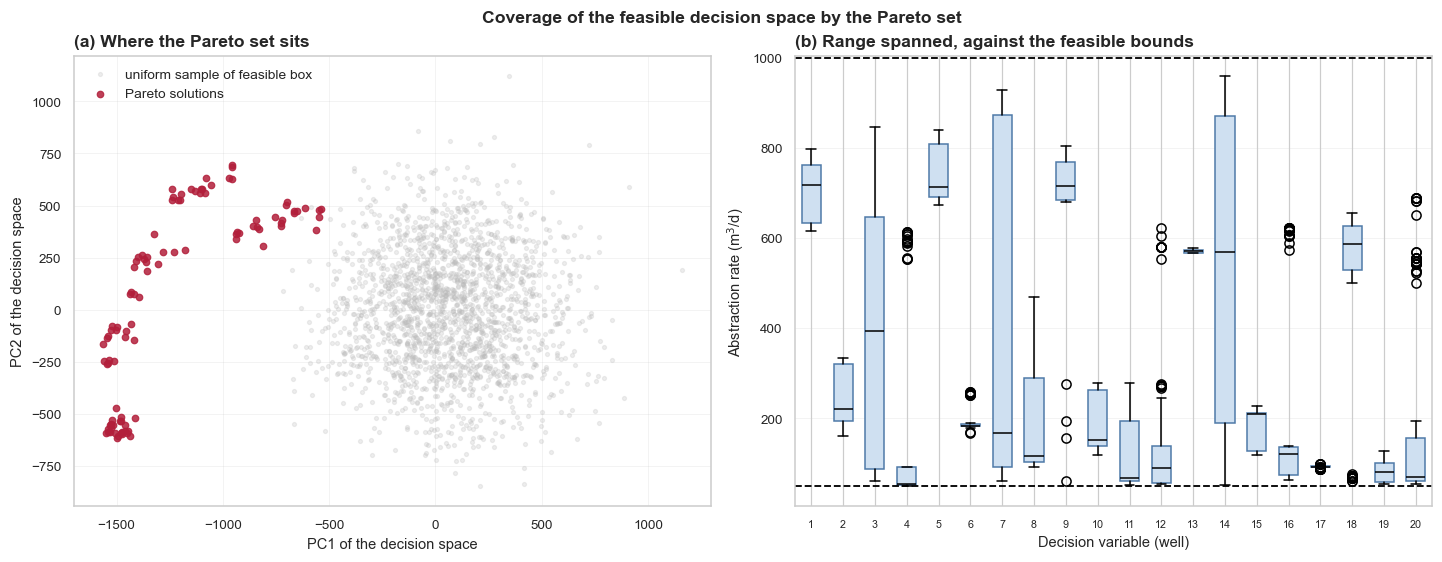


per-variable coverage: mean 41 %, minimum 1 %
  coverage zyada -> Sobol comparison solid hai, figure rakh
  coverage kam   -> Pareto set patli slice hai, Section 3.2 ka claim limit karna padega


In [64]:
# ===== Figure D: Pareto set decision space ka kitna hissa cover karta hai =====
from sklearn.decomposition import PCA

rng = np.random.default_rng(SEED)
U = rng.uniform(LO, HI, size=(2000, len(DV_COLS)))   # feasible box ka uniform sample
P = front[DV_COLS].values                             # Pareto set

proj = PCA(n_components=2).fit(np.vstack([U, P]))
uu, pp = proj.transform(U), proj.transform(P)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.0), constrained_layout=True)
ax1.scatter(uu[:,0], uu[:,1], s=7, alpha=0.25, color='#bbbbbb', label='uniform sample of feasible box')
ax1.scatter(pp[:,0], pp[:,1], s=18, color='#b21f3b', alpha=0.85, label='Pareto solutions')
ax1.set_xlabel('PC1 of the decision space'); ax1.set_ylabel('PC2 of the decision space')
ax1.set_title('(a) Where the Pareto set sits', fontsize=11.5, loc='left', fontweight='bold')
ax1.legend(fontsize=9); ax1.grid(alpha=0.3, linewidth=0.5); ax1.set_axisbelow(True)

bp = ax2.boxplot([P[:,j] for j in range(len(DV_COLS))], patch_artist=True, widths=0.6,
                 medianprops=dict(color='black'))
for b in bp['boxes']:
    b.set_facecolor('#cfe0f1'); b.set_edgecolor('#4f7aa8')
ax2.axhline(LO, ls='--', color='black', lw=1.2)
ax2.axhline(HI, ls='--', color='black', lw=1.2)
ax2.set_xticks(range(1, len(DV_COLS)+1))
ax2.set_xticklabels([f'{i+1}' for i in range(len(DV_COLS))], fontsize=7)
ax2.set_xlabel('Decision variable (well)'); ax2.set_ylabel(r'Abstraction rate (m$^3$/d)')
ax2.set_title('(b) Range spanned, against the feasible bounds', fontsize=11.5,
              loc='left', fontweight='bold')
ax2.grid(alpha=0.3, axis='y', linewidth=0.5); ax2.set_axisbelow(True)

fig.suptitle('Coverage of the feasible decision space by the Pareto set',
             fontsize=11.5, fontweight='bold')
plt.savefig(FIGDIR / 'figD_decision_space_coverage.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGDIR / 'figD_decision_space_coverage.pdf', bbox_inches='tight')
plt.show()

cov = np.array([(P[:,j].max()-P[:,j].min())/(HI-LO) for j in range(len(DV_COLS))])
print(f"\nper-variable coverage: mean {100*cov.mean():.0f} %, minimum {100*cov.min():.0f} %")
print("  coverage zyada -> Sobol comparison solid hai, figure rakh")
print("  coverage kam   -> Pareto set patli slice hai, Section 3.2 ka claim limit karna padega")

In [65]:
# ===== AIN: L-only DRSI =====
# reliability sirf L ke CI se (Q degenerate hai)
relL_a = 1.0 / (1.0 + (np.asarray(shap_results_ain['L']['ci_high'], float)
                       - np.asarray(shap_results_ain['L']['ci_low'], float))
                / (np.asarray(shap_results_ain['L']['mean_abs'], float) + 1e-9))

# Ain DV bounds (coverage figure ke liye)
AIN_LO = float(AIN_DF[AIN_DV_COLS].values.min())
AIN_HI = float(AIN_DF[AIN_DV_COLS].values.max())

# L-only DRSI on the Ain front
drsi_ain = compute_drsi_Lonly(ain_front, shapL_a, relL_a, weights=(1, 1, 1))
ta = int(np.argmax(drsi_ain['closeness']))       # compromise programming pick
da = int(np.argmax(drsi_ain['drsi']))            # DRSI pick

print(f"Ain front: {len(ain_front)} solutions ({main_algo})")
print(f"TOPSIS #{ta}: Q={ain_front.Q[ta]:.0f}, L={ain_front.L[ta]:.0f}, "
      f"eff communes={drsi_ain['eff_wells'][ta]:.1f}")
print(f"DRSI   #{da}: Q={ain_front.Q[da]:.0f}, L={ain_front.L[da]:.0f}, "
      f"eff communes={drsi_ain['eff_wells'][da]:.1f}")
print(f"\nDono alag solution? {ta != da}")
print(f"DV bounds observed: {AIN_LO:.0f} to {AIN_HI:.0f} m3/d")
print("\n>>> TABLE 3 KE AIN NUMBERS <<<")
print(f"  Compromise programming: eff communes = {drsi_ain['eff_wells'][ta]:.1f}")
print(f"  DRSI (equal weights)  : eff communes = {drsi_ain['eff_wells'][da]:.1f}")

Ain front: 554 solutions (moead)
TOPSIS #56: Q=105000, L=304000, eff communes=4.0
DRSI   #106: Q=114000, L=298000, eff communes=4.1

Dono alag solution? True
DV bounds observed: 500 to 2500 m3/d

>>> TABLE 3 KE AIN NUMBERS <<<
  Compromise programming: eff communes = 4.0
  DRSI (equal weights)  : eff communes = 4.1


In [66]:
# ===== AIN: DRSI ne alag solution kyun chuna? =====
d = drsi_ain
nz = lambda a: (a - a.min())/(np.ptp(a) + 1e-12)
E, S, R = nz(d['closeness']), nz(d['simplicity']), nz(d['reliability'])

print(f"{'':26s} {'CP (#'+str(ta)+')':>12s} {'DRSI (#'+str(da)+')':>14s}")
print(f"{'closeness (normalised)':26s} {E[ta]:12.3f} {E[da]:14.3f}")
print(f"{'simplicity (normalised)':26s} {S[ta]:12.3f} {S[da]:14.3f}")
print(f"{'reliability (normalised)':26s} {R[ta]:12.3f} {R[da]:14.3f}")
print(f"{'DRSI':26s} {d['drsi'][ta]:12.3f} {d['drsi'][da]:14.3f}")
print(f"\n{'raw closeness':26s} {d['closeness'][ta]:12.3f} {d['closeness'][da]:14.3f}")
print(f"{'raw reliability':26s} {d['reliability'][ta]:12.3f} {d['reliability'][da]:14.3f}")
print(f"{'eff communes':26s} {d['eff_wells'][ta]:12.1f} {d['eff_wells'][da]:14.1f}")

# decision-weighted (1,2,2) se kya badalta hai?
d2 = compute_drsi_Lonly(ain_front, shapL_a, relL_a, weights=(1,2,2))
k2 = int(np.argmax(d2['drsi']))
print(f"\n(1,2,2) DRSI pick #{k2}: Q={ain_front.Q[k2]:.0f}, L={ain_front.L[k2]:.0f}, "
      f"eff communes={d2['eff_wells'][k2]:.1f}")

# Ain front kitna parsimonious hai overall?
print(f"\nAin front eff communes: min {d['eff_wells'].min():.1f}, "
      f"median {np.median(d['eff_wells']):.1f}, max {d['eff_wells'].max():.1f}  (out of {AIN_N_DV})")

                               CP (#56)    DRSI (#106)
closeness (normalised)            1.000          0.998
simplicity (normalised)           0.847          0.827
reliability (normalised)          0.649          0.688
DRSI                              0.819          0.828

raw closeness                     0.672          0.671
raw reliability                   0.921          0.922
eff communes                        4.0            4.1

(1,2,2) DRSI pick #106: Q=114000, L=298000, eff communes=4.1

Ain front eff communes: min 2.8, median 4.2, max 10.6  (out of 31)


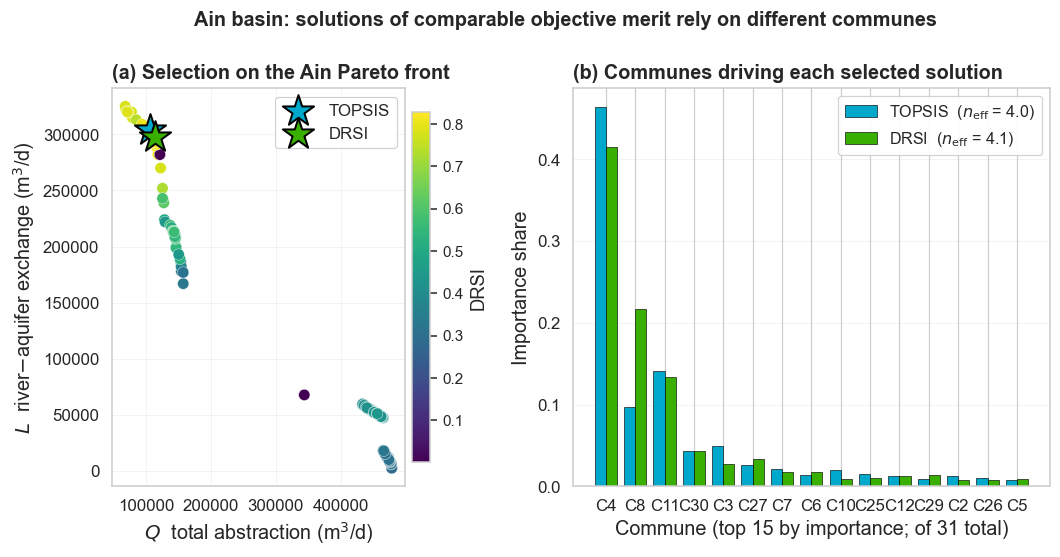

In [84]:
# ===== AIN: DRSI vs compromise programming (FIXED) =====
fig = plt.figure(figsize=(11, 4.7))
gs = fig.add_gridspec(1, 2, width_ratios=[1.0, 1.35], wspace=0.26)

# ---- (a) front, DRSI se coloured, dono picks marked ----
axp = fig.add_subplot(gs[0])
sc = axp.scatter(ain_front.Q, ain_front.L, c=drsi_ain['drsi'], cmap='viridis',
                 s=55, edgecolor='white', linewidth=0.25, zorder=2)
axp.scatter(ain_front.Q[ta], ain_front.L[ta], s=460, marker='*', color='#00a9cc',
            edgecolor='black', linewidth=1.3, zorder=6, label='TOPSIS')
axp.scatter(ain_front.Q[da], ain_front.L[da], s=460, marker='*', color='#39b000',
            edgecolor='black', linewidth=1.3, zorder=6, label='DRSI')
# dono picks ko naam de, taaki overlap ho bhi toh pata chale
# axp.annotate('CP', (ain_front.Q[ta], ain_front.L[ta]), xytext=(12, 12),
#              textcoords='offset points', fontsize=12, fontweight='bold', color='#00708a', zorder=7)
# axp.annotate('DRSI', (ain_front.Q[da], ain_front.L[da]), xytext=(12, -16),
#              textcoords='offset points', fontsize=12, fontweight='bold', color='#2b7a00', zorder=7)
axp.set_xlabel(r'$Q$  total abstraction (m$^3$/d)', fontsize=13)
axp.set_ylabel(r'$L$  river$-$aquifer exchange (m$^3$/d)', fontsize=13)
axp.set_title('(a) Selection on the Ain Pareto front', fontsize=13, loc='left', fontweight='bold')
axp.tick_params(axis='both', labelsize=11)
axp.legend(frameon=True, framealpha=0.9, loc='best', fontsize=11)
axp.grid(alpha=0.3, linewidth=0.5); axp.set_axisbelow(True)
cb = fig.colorbar(sc, ax=axp, shrink=0.88, pad=0.02); cb.set_label('DRSI', fontsize=12)
cb.ax.tick_params(labelsize=10)

# ---- (b) communes: importance ke hisaab se SORT kiya, top 15 hi dikhaye ----
axb = fig.add_subplot(gs[1])
sh_t = drsi_ain['share'][ta]; sh_d = drsi_ain['share'][da]
order = np.argsort(-(sh_t + sh_d))          # dono ka combined importance se sort
TOPN = 15
sel = order[:TOPN]
x = np.arange(TOPN); w = 0.38
axb.bar(x - w/2, sh_t[sel], w, color='#00a9cc', edgecolor='black', linewidth=0.4,
        label=f'TOPSIS  ($n_{{\\mathrm{{eff}}}}$ = {drsi_ain["eff_wells"][ta]:.1f})')
axb.bar(x + w/2, sh_d[sel], w, color='#39b000', edgecolor='black', linewidth=0.4,
        label=f'DRSI  ($n_{{\\mathrm{{eff}}}}$ = {drsi_ain["eff_wells"][da]:.1f})')
axb.set_xticks(x)
axb.set_xticklabels([f'C{j+1}' for j in sel], fontsize=11, rotation=0)
axb.set_xlabel(f'Commune (top {TOPN} by importance; of {AIN_N_DV} total)', fontsize=13)
axb.set_ylabel('Importance share', fontsize=13)
axb.set_title('(b) Communes driving each selected solution', fontsize=13,
              loc='left', fontweight='bold')
axb.tick_params(axis='y', labelsize=11)
axb.legend(frameon=True, framealpha=0.9, fontsize=10.5)
axb.grid(alpha=0.3, axis='y', linewidth=0.5); axb.set_axisbelow(True)

fig.suptitle('Ain basin: solutions of comparable objective merit rely on different communes',
             fontsize=13, fontweight='bold', y=1.03)
plt.savefig(FIGDIR / 'fig_drsi_ain_selection.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGDIR / 'fig_drsi_ain_selection.pdf', bbox_inches='tight')
plt.show()

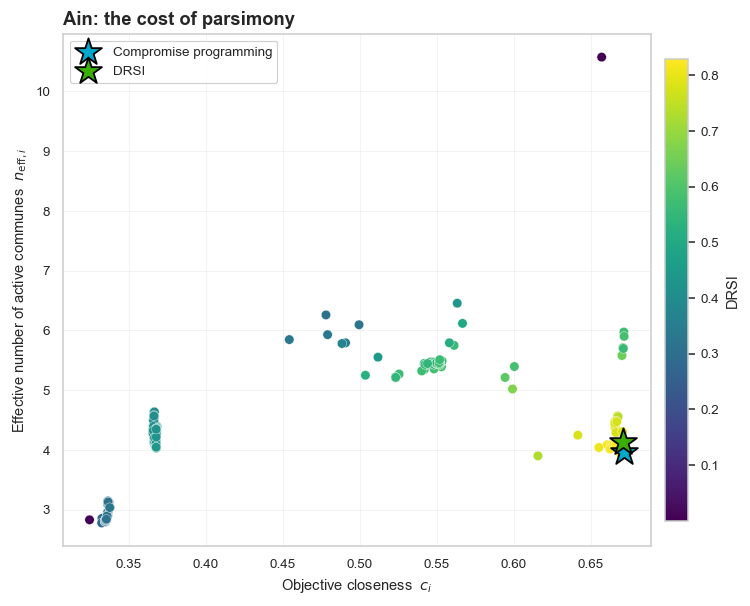


>>> AIN MANUSCRIPT NUMBERS <<<
closeness    : CP 0.672 | DRSI 0.671  -> loss 0.1 %
eff communes : CP 4.0 | DRSI 4.1  -> -4 % kam


In [68]:
# ===== AIN: effective communes vs objective closeness =====
clos_a = drsi_ain['closeness']; eff_a = drsi_ain['eff_wells']

fig, ax = plt.subplots(figsize=(7.2, 5.6))
sc = ax.scatter(clos_a, eff_a, c=drsi_ain['drsi'], cmap='viridis', s=38,
                edgecolor='white', linewidth=0.25, zorder=3)
ax.scatter(clos_a[ta], eff_a[ta], s=340, marker='*', color='#00a9cc',
           edgecolor='black', linewidth=1.2, zorder=5, label='Compromise programming')
ax.scatter(clos_a[da], eff_a[da], s=340, marker='*', color='#39b000',
           edgecolor='black', linewidth=1.2, zorder=5, label='DRSI')
ax.plot([clos_a[ta], clos_a[da]], [eff_a[ta], eff_a[ta]], ls=':', color='#555', lw=1.2)
ax.plot([clos_a[da], clos_a[da]], [eff_a[ta], eff_a[da]], ls=':', color='#555', lw=1.2)

ax.set_xlabel(r'Objective closeness  $c_i$')
ax.set_ylabel(r'Effective number of active communes  $n_{\mathrm{eff},i}$')
ax.set_title('Ain: the cost of parsimony', fontsize=12, loc='left', fontweight='bold')
ax.legend(frameon=True, framealpha=0.9)
ax.grid(alpha=0.3, linewidth=0.5); ax.set_axisbelow(True)
cb = fig.colorbar(sc, ax=ax, shrink=0.9, pad=0.02); cb.set_label('DRSI')
plt.tight_layout()
plt.savefig(FIGDIR / 'figA_ain_cost_of_parsimony.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGDIR / 'figA_ain_cost_of_parsimony.pdf', bbox_inches='tight')
plt.show()

loss_a = 100 * (clos_a[ta] - clos_a[da]) / clos_a[ta]
print(f"\n>>> AIN MANUSCRIPT NUMBERS <<<")
print(f"closeness    : CP {clos_a[ta]:.3f} | DRSI {clos_a[da]:.3f}  -> loss {loss_a:.1f} %")
print(f"eff communes : CP {eff_a[ta]:.1f} | DRSI {eff_a[da]:.1f}  "
      f"-> {100*(1-eff_a[da]/eff_a[ta]):.0f} % kam")

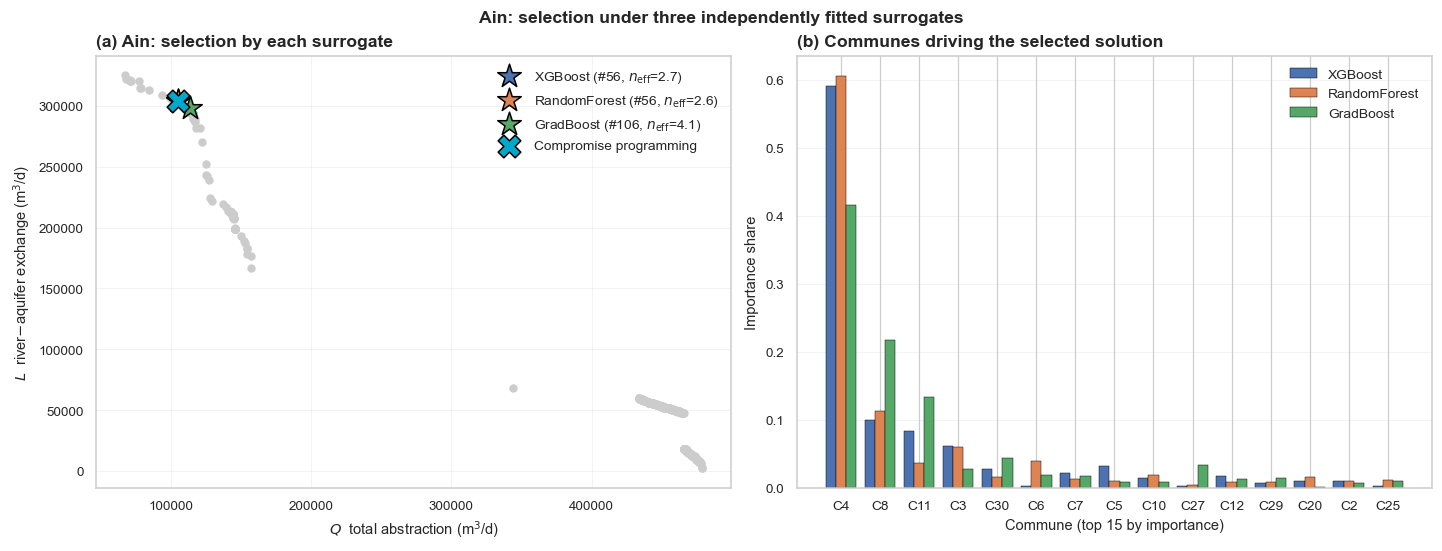

selected solution per surrogate: {'XGBoost': 56, 'RandomForest': 56, 'GradBoost': 106}
eff communes per surrogate    : {'XGBoost': np.float32(2.7), 'RandomForest': np.float64(2.6), 'GradBoost': np.float64(4.1)}
Spearman(importance) XGBoost vs RandomForest: 0.814
Spearman(importance) XGBoost vs GradBoost: 0.800
Spearman(importance) RandomForest vs GradBoost: 0.700


In [69]:
# ===== AIN: teeno surrogates se selection =====
import shap as _shap

Xa = ain_front[AIN_DV_COLS].values
res_a = {}
for name, model in ensemble_ain['L'].items():
    sv = _shap.TreeExplainer(model).shap_values(Xa)
    dd = compute_drsi_Lonly(ain_front, sv, relL_a, weights=(1, 1, 1))
    k = int(np.argmax(dd['drsi']))
    res_a[name] = dict(idx=k, eff=dd['eff_wells'][k], Q=float(ain_front.Q[k]),
                       L=float(ain_front.L[k]), share=dd['share'][k])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.9), constrained_layout=True)
cols = ['#4C72B0', '#DD8452', '#55A868']

ax1.scatter(ain_front.Q, ain_front.L, s=22, color='#cccccc', zorder=2)
for (name, r), c in zip(res_a.items(), cols):
    ax1.scatter(r['Q'], r['L'], s=260, marker='*', color=c, edgecolor='black',
                linewidth=1.0, zorder=5,
                label=f"{name} (#{r['idx']}, $n_{{\\mathrm{{eff}}}}$={r['eff']:.1f})")
ax1.scatter(ain_front.Q[ta], ain_front.L[ta], s=220, marker='X', color='#00a9cc',
            edgecolor='black', linewidth=1.0, zorder=5, label='Compromise programming')
ax1.set_xlabel(r'$Q$  total abstraction (m$^3$/d)')
ax1.set_ylabel(r'$L$  river$-$aquifer exchange (m$^3$/d)')
ax1.set_title('(a) Ain: selection by each surrogate', fontsize=11.5, loc='left', fontweight='bold')
ax1.legend(fontsize=9); ax1.grid(alpha=0.3, linewidth=0.5); ax1.set_axisbelow(True)

# top-15 communes only, sorted
tot = sum(r['share'] for r in res_a.values())
ordc = np.argsort(-tot)[:15]
x = np.arange(len(ordc)); w = 0.26
for i, ((name, r), c) in enumerate(zip(res_a.items(), cols)):
    ax2.bar(x + (i - 1) * w, r['share'][ordc], w, label=name, color=c,
            edgecolor='black', linewidth=0.3)
ax2.set_xticks(x); ax2.set_xticklabels([f'C{j+1}' for j in ordc], fontsize=9)
ax2.set_xlabel('Commune (top 15 by importance)'); ax2.set_ylabel('Importance share')
ax2.set_title('(b) Communes driving the selected solution', fontsize=11.5,
              loc='left', fontweight='bold')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3, axis='y', linewidth=0.5); ax2.set_axisbelow(True)

fig.suptitle('Ain: selection under three independently fitted surrogates',
             fontsize=11.5, fontweight='bold')
plt.savefig(FIGDIR / 'figC_ain_surrogate_robustness.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGDIR / 'figC_ain_surrogate_robustness.pdf', bbox_inches='tight')
plt.show()

print("selected solution per surrogate:", {n: res_a[n]['idx'] for n in res_a})
print("eff communes per surrogate    :", {n: round(res_a[n]['eff'],1) for n in res_a})
from scipy.stats import spearmanr
ns = list(res_a)
for a in range(len(ns)):
    for b in range(a+1, len(ns)):
        rho, _ = spearmanr(res_a[ns[a]]['share'], res_a[ns[b]]['share'])
        print(f"Spearman(importance) {ns[a]} vs {ns[b]}: {rho:.3f}")

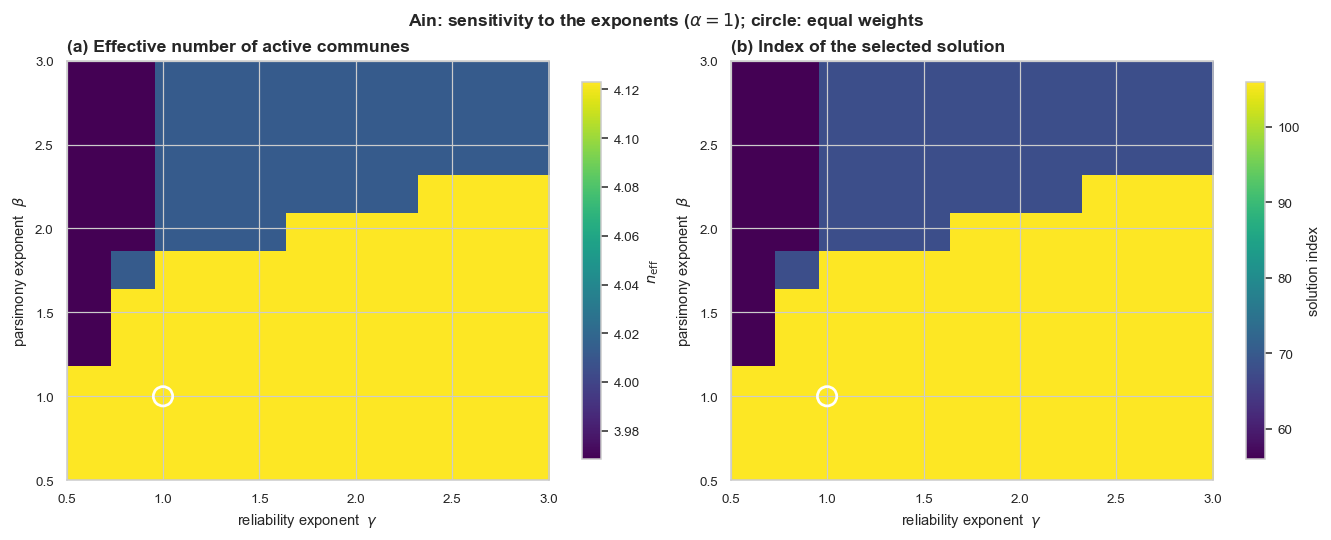

weight grid par kitne alag solutions: 3 / 121
eff communes range: 4.0 - 4.1


In [70]:
# ===== AIN: exponents ki sensitivity (recall nahi — Ain mein Sobol nahi hai) =====
betas  = np.linspace(0.5, 3.0, 11)
gammas = np.linspace(0.5, 3.0, 11)
effm_a  = np.zeros((len(betas), len(gammas)))
picks_a = np.zeros_like(effm_a, dtype=int)
for i, b in enumerate(betas):
    for j, g in enumerate(gammas):
        dd = compute_drsi_Lonly(ain_front, shapL_a, relL_a, weights=(1, b, g))
        k = int(np.argmax(dd['drsi']))
        picks_a[i, j] = k
        effm_a[i, j]  = dd['eff_wells'][k]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)
ext = [gammas[0], gammas[-1], betas[0], betas[-1]]
for ax, M, ttl, cl in zip(axes, [effm_a, picks_a.astype(float)],
        ['(a) Effective number of active communes', '(b) Index of the selected solution'],
        [r'$n_{\mathrm{eff}}$', 'solution index']):
    im = ax.imshow(M, origin='lower', cmap='viridis', aspect='auto',
                   extent=ext, interpolation='nearest')
    ax.set_xlabel(r'reliability exponent  $\gamma$')
    ax.set_ylabel(r'parsimony exponent  $\beta$')
    ax.set_title(ttl, fontsize=11.5, loc='left', fontweight='bold')
    ax.scatter(1, 1, s=160, marker='o', facecolor='none', edgecolor='white', lw=1.8)
    cb = fig.colorbar(im, ax=ax, shrink=0.9); cb.set_label(cl)
fig.suptitle(r'Ain: sensitivity to the exponents ($\alpha=1$); circle: equal weights',
             fontsize=11.5, fontweight='bold')
plt.savefig(FIGDIR / 'figB_ain_weight_sensitivity.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGDIR / 'figB_ain_weight_sensitivity.pdf', bbox_inches='tight')
plt.show()

print(f"weight grid par kitne alag solutions: {len(np.unique(picks_a))} / {picks_a.size}")
print(f"eff communes range: {effm_a.min():.1f} - {effm_a.max():.1f}")

In [71]:
# ===== AIN: kya parsimony ka trade-off exist karta hai? =====
c = drsi_ain['closeness']; e = drsi_ain['eff_wells']

# jo solutions CP ke closeness ke 5% ke andar hain, unme sabse parsimonious kaunsa?
near = np.where(c >= 0.95 * c[ta])[0]
best = near[np.argmin(e[near])]
print(f"CP ke 5% closeness ke andar {len(near)} solutions hain")
print(f"  unme sabse parsimonious #{best}: eff communes={e[best]:.1f}, "
      f"closeness={c[best]:.3f} (CP: {c[ta]:.3f}), Q={ain_front.Q[best]:.0f}, L={ain_front.L[best]:.0f}")

# strong weights pe DRSI kya chunta hai?
for w in [(1,3,3), (1,5,5), (1,8,8)]:
    dd = compute_drsi_Lonly(ain_front, shapL_a, relL_a, weights=w)
    k = int(np.argmax(dd['drsi']))
    print(f"  weights {w}: pick #{k}, eff communes={dd['eff_wells'][k]:.1f}, "
          f"closeness={dd['closeness'][k]:.3f}")

# signatures kitne alag hain solutions ke beech?
from scipy.stats import spearmanr
S = drsi_ain['share']
rng2 = np.random.default_rng(SEED)
pairs = rng2.choice(len(S), size=(200,2))
rhos = [spearmanr(S[i], S[j])[0] for i,j in pairs if i!=j]
print(f"\nsolutions ke signatures ke beech mean Spearman: {np.mean(rhos):.3f}")
print("  ~1.0 -> sab solutions same communes pe rely karte hain (koi structure nahi)")
print("  <0.7 -> asli variation hai, DRSI ko exploit karna chahiye tha")

CP ke 5% closeness ke andar 103 solutions hain
  unme sabse parsimonious #128: eff communes=3.9, closeness=0.670 (CP: 0.672), Q=93419, L=309000
  weights (1, 3, 3): pick #68, eff communes=4.0, closeness=0.663
  weights (1, 5, 5): pick #68, eff communes=4.0, closeness=0.663
  weights (1, 8, 8): pick #176, eff communes=2.8, closeness=0.335

solutions ke signatures ke beech mean Spearman: 0.713
  ~1.0 -> sab solutions same communes pe rely karte hain (koi structure nahi)
  <0.7 -> asli variation hai, DRSI ko exploit karna chahiye tha


In [72]:
S = drsi_ain['share']
top_cp   = np.argsort(-S[ta])[:5]
top_drsi = np.argsort(-S[da])[:5]
print("CP   top-5 communes:", [f"C{j+1}" for j in top_cp])
print("DRSI top-5 communes:", [f"C{j+1}" for j in top_drsi])
print("overlap:", len(set(top_cp) & set(top_drsi)), "of 5")
from scipy.stats import spearmanr
print("Spearman(CP, DRSI signatures):", round(spearmanr(S[ta], S[da])[0], 3))

CP   top-5 communes: ['C4', 'C11', 'C8', 'C3', 'C30']
DRSI top-5 communes: ['C4', 'C8', 'C11', 'C30', 'C27']
overlap: 4 of 5
Spearman(CP, DRSI signatures): 0.857


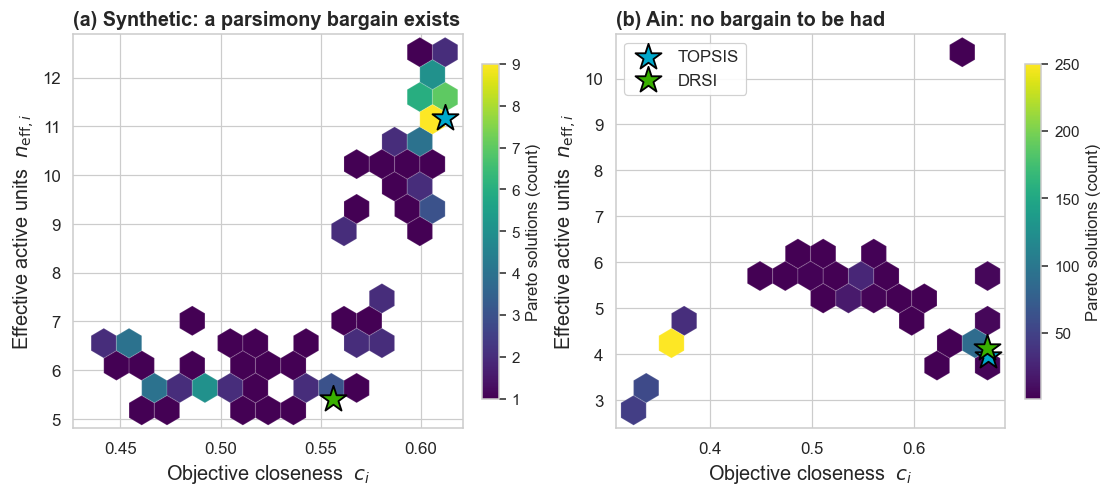

In [87]:
# ===== Hexbin: closeness vs effective units, dono dataset ek frame mein =====
fig, axes = plt.subplots(1, 2, figsize=(10, 4.4), constrained_layout=True)

# ---- (a) Synthetic ----
ax = axes[0]
hb = ax.hexbin(drsi_A['closeness'], drsi_A['eff_wells'], gridsize=14,
               cmap='viridis', mincnt=1, edgecolors='#ffffff20')
ax.scatter(drsi_A['closeness'][t_idx], drsi_A['eff_wells'][t_idx], s=320,
           marker='*', color='#00a9cc', edgecolor='black', linewidth=1.2, zorder=6)
ax.scatter(drsi_A['closeness'][d_idx], drsi_A['eff_wells'][d_idx], s=320,
           marker='*', color='#39b000', edgecolor='black', linewidth=1.2, zorder=6)
ax.set_xlabel(r'Objective closeness  $c_i$', fontsize=13)
ax.set_ylabel(r'Effective active units  $n_{\mathrm{eff},i}$', fontsize=13)
ax.set_title('(a) Synthetic: a parsimony bargain exists', fontsize=13,
             loc='left', fontweight='bold')
ax.tick_params(axis='both', labelsize=11)
cb = fig.colorbar(hb, ax=ax, shrink=0.85); cb.set_label('Pareto solutions (count)', fontsize=11)
cb.ax.tick_params(labelsize=10)

# ---- (b) Ain ----
ax = axes[1]
hb = ax.hexbin(drsi_ain['closeness'], drsi_ain['eff_wells'], gridsize=14,
               cmap='viridis', mincnt=1, edgecolors='#ffffff20')
ax.scatter(drsi_ain['closeness'][ta], drsi_ain['eff_wells'][ta], s=320,
           marker='*', color='#00a9cc', edgecolor='black', linewidth=1.2, zorder=6,
           label='TOPSIS')
ax.scatter(drsi_ain['closeness'][da], drsi_ain['eff_wells'][da], s=320,
           marker='*', color='#39b000', edgecolor='black', linewidth=1.2, zorder=6,
           label='DRSI')
ax.set_xlabel(r'Objective closeness  $c_i$', fontsize=13)
ax.set_ylabel(r'Effective active units  $n_{\mathrm{eff},i}$', fontsize=13)
ax.set_title('(b) Ain: no bargain to be had', fontsize=13, loc='left', fontweight='bold')
ax.tick_params(axis='both', labelsize=11)
ax.legend(fontsize=11, frameon=True, framealpha=0.9, loc='upper left')
cb = fig.colorbar(hb, ax=ax, shrink=0.85); cb.set_label('Pareto solutions (count)', fontsize=11)
cb.ax.tick_params(labelsize=10)

# fig.suptitle('Whether a parsimony bargain exists is a property of the front, not of the method',
#              fontsize=13.5, fontweight='bold', y=1.05)
plt.savefig(FIGDIR / 'figE_hexbin_parsimony_contrast.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGDIR / 'figE_hexbin_parsimony_contrast.pdf', bbox_inches='tight')
plt.show()

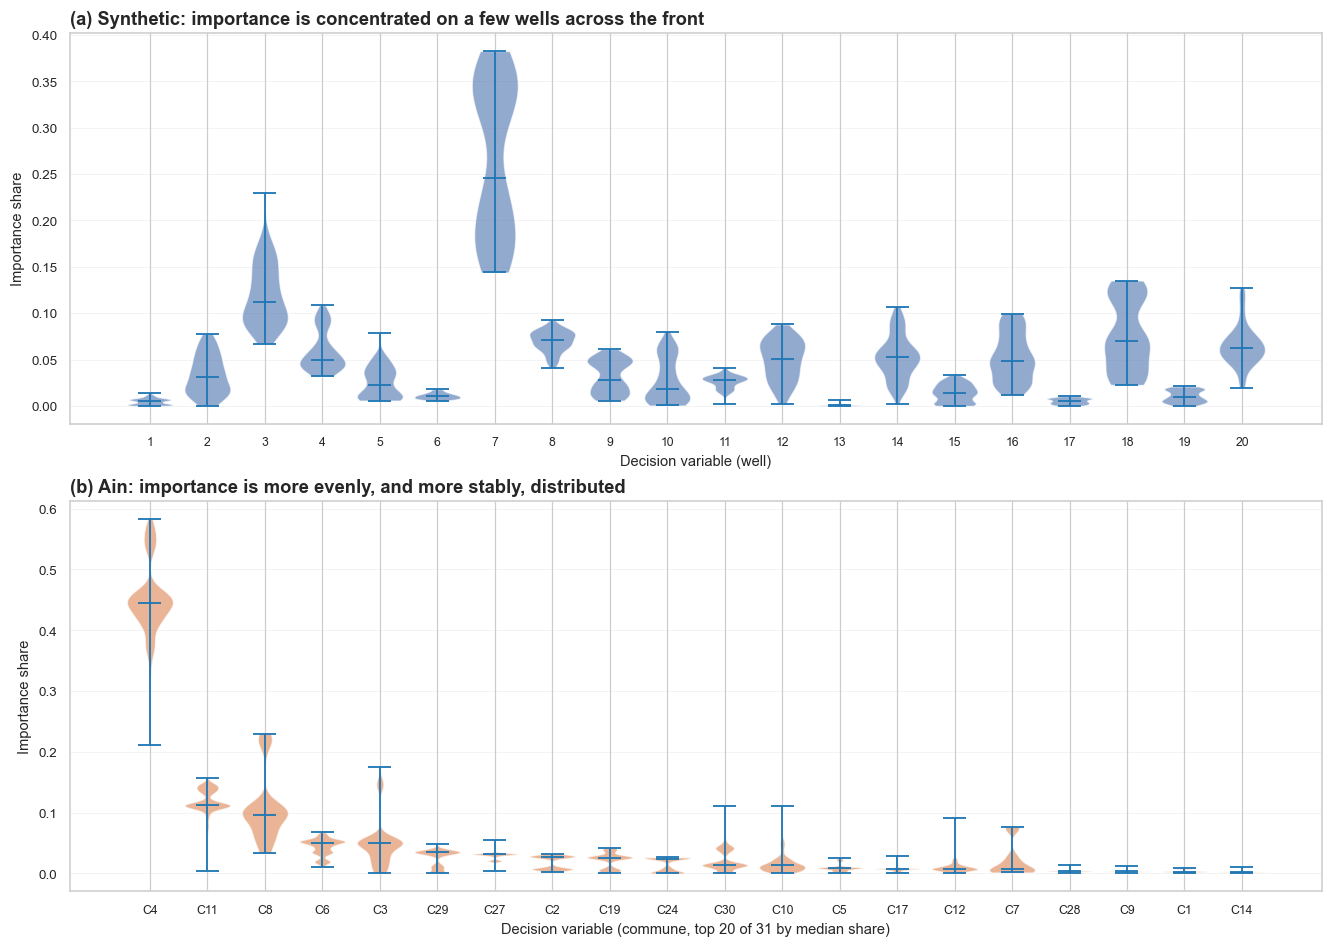

Synthetic: 2 of 20 wells consistently above 2x uniform importance
Ain:       3 of 31 communes consistently above 2x uniform importance


In [74]:
# ===== Violin: importance share distribution per decision variable =====
fig, axes = plt.subplots(2, 1, figsize=(12, 8.5), constrained_layout=True)

# ---- (a) Synthetic: har well ka importance-share distribution poore front pe ----
ax = axes[0]
data_syn = [drsi_A['share'][:, j] for j in range(len(DV_COLS))]
vp = ax.violinplot(data_syn, showmedians=True, widths=0.8)
for b in vp['bodies']:
    b.set_facecolor('#4C72B0'); b.set_alpha(0.6)
ax.set_xticks(range(1, len(DV_COLS)+1))
ax.set_xticklabels([f'{i+1}' for i in range(len(DV_COLS))], fontsize=8)
ax.set_xlabel('Decision variable (well)'); ax.set_ylabel('Importance share')
ax.set_title('(a) Synthetic: importance is concentrated on a few wells across the front',
             fontsize=12, loc='left', fontweight='bold')
ax.grid(alpha=0.3, axis='y', linewidth=0.5); ax.set_axisbelow(True)

# ---- (b) Ain: same, top 20 communes by median importance for readability ----
ax = axes[1]
med = np.median(drsi_ain['share'], axis=0)
order = np.argsort(-med)[:20]
data_ain = [drsi_ain['share'][:, j] for j in order]
vp = ax.violinplot(data_ain, showmedians=True, widths=0.8)
for b in vp['bodies']:
    b.set_facecolor('#DD8452'); b.set_alpha(0.6)
ax.set_xticks(range(1, len(order)+1))
ax.set_xticklabels([f'C{j+1}' for j in order], fontsize=8)
ax.set_xlabel('Decision variable (commune, top 20 of 31 by median share)')
ax.set_ylabel('Importance share')
ax.set_title('(b) Ain: importance is more evenly, and more stably, distributed',
             fontsize=12, loc='left', fontweight='bold')
ax.grid(alpha=0.3, axis='y', linewidth=0.5); ax.set_axisbelow(True)

plt.savefig(FIGDIR / 'figF_violin_importance_distribution.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGDIR / 'figF_violin_importance_distribution.pdf', bbox_inches='tight')
plt.show()

# quantify: kitne wells/communes "consistently important" hain (median share > 2x uniform)?
unif_syn = 1/len(DV_COLS); unif_ain = 1/AIN_N_DV
n_key_syn = int((np.median(drsi_A['share'],axis=0) > 2*unif_syn).sum())
n_key_ain = int((np.median(drsi_ain['share'],axis=0) > 2*unif_ain).sum())
print(f"Synthetic: {n_key_syn} of {len(DV_COLS)} wells consistently above 2x uniform importance")
print(f"Ain:       {n_key_ain} of {AIN_N_DV} communes consistently above 2x uniform importance")

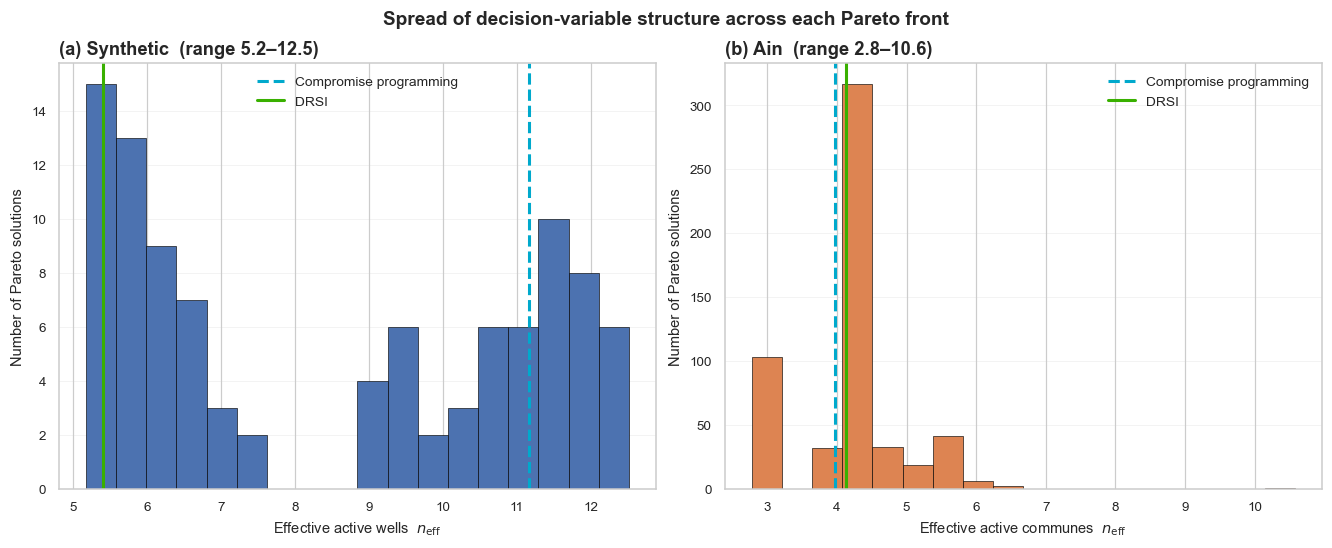

In [75]:
# ===== Histogram: distribution of effective active units across each front =====
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)

axes[0].hist(drsi_A['eff_wells'], bins=18, color='#4C72B0', edgecolor='black', linewidth=0.4)
axes[0].axvline(drsi_A['eff_wells'][t_idx], color='#00a9cc', lw=2, ls='--', label='Compromise programming')
axes[0].axvline(drsi_A['eff_wells'][d_idx], color='#39b000', lw=2, ls='-', label='DRSI')
axes[0].set_xlabel(r'Effective active wells  $n_{\mathrm{eff}}$')
axes[0].set_ylabel('Number of Pareto solutions')
axes[0].set_title(f'(a) Synthetic  (range {drsi_A["eff_wells"].min():.1f}\u2013{drsi_A["eff_wells"].max():.1f})',
                  fontsize=12, loc='left', fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3, axis='y', linewidth=0.5); axes[0].set_axisbelow(True)

axes[1].hist(drsi_ain['eff_wells'], bins=18, color='#DD8452', edgecolor='black', linewidth=0.4)
axes[1].axvline(drsi_ain['eff_wells'][ta], color='#00a9cc', lw=2, ls='--', label='Compromise programming')
axes[1].axvline(drsi_ain['eff_wells'][da], color='#39b000', lw=2, ls='-', label='DRSI')
axes[1].set_xlabel(r'Effective active communes  $n_{\mathrm{eff}}$')
axes[1].set_ylabel('Number of Pareto solutions')
axes[1].set_title(f'(b) Ain  (range {drsi_ain["eff_wells"].min():.1f}\u2013{drsi_ain["eff_wells"].max():.1f})',
                  fontsize=12, loc='left', fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3, axis='y', linewidth=0.5); axes[1].set_axisbelow(True)

fig.suptitle('Spread of decision-variable structure across each Pareto front',
             fontsize=12.5, fontweight='bold', y=1.05)
plt.savefig(FIGDIR / 'figG_eff_units_histograms.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGDIR / 'figG_eff_units_histograms.pdf', bbox_inches='tight')
plt.show()

---
## 16. Extended analyses (post-optimality diagnostics)

Five additional analyses, run once the validated DRSI framework exists on both case studies:

1. **All-fronts DRSI** — does a parsimony bargain exist on every front we have (12 synthetic + 12 Ain), or only on the ones already shown?
2. **Pareto-conditional Sobol** — an apples-to-apples ground truth for SHAP, sampled on the Pareto-front's own DV bounds rather than the full feasible box.
3. **Surrogate residual diagnostics** — is the surrogate reliable everywhere on the front, especially near the DRSI pick?
4. **Innovization rules** — which DVs systematically separate DRSI-favored from TOPSIS-favored solutions, and do SHAP/Sobol agree they matter?
5. **Ain management-scheme comparison** — TOPSIS, DRSI, knee-point, and max-reliability side by side.


### 16.1 All-fronts DRSI — where does a parsimony bargain exist?

In [76]:
# ===== All-fronts DRSI analysis =====
# Runs DRSI on every front we have (12 synthetic configs + every Ain source
# file with >=10 solutions) using the POOLED SHAP arrays already computed
# (shap_results_syn / shap_results_ain), indexed per front by a boolean mask
# -- no per-front SHAP refit needed, since SYN_DF / AIN_DF are exactly the
# frames those SHAP values were computed on.

def _front_curvature(Q, L):
    """abs(2nd-order coefficient) of a polyfit on min-max-normalized (Q, L)."""
    qn = (Q - Q.min()) / (Q.max() - Q.min() + 1e-12)
    ln = (L - L.min()) / (L.max() - L.min() + 1e-12)
    coeffs = np.polyfit(qn, ln, 2)
    return abs(coeffs[0])


def _dv_diversity(sub_df, dv_cols, lo, hi):
    """Mean, across DVs, of (range spanned by this front) / (feasible range)."""
    span = sub_df[dv_cols].max() - sub_df[dv_cols].min()
    return float((span / (hi - lo)).mean())


all_fronts_rows = []

# --- synthetic: 12 configs, keyed exactly as in `synthetic_fronts` ---
for key, sub in synthetic_fronts.items():
    algo, dv_tag, range_tag = key.split('_')
    domain = int(dv_tag.replace('dv', ''))
    dv_high = int(range_tag.replace('range', ''))
    mask = ((SYN_DF['algo'] == algo) & (SYN_DF['domain'] == domain)
             & (SYN_DF['dv_high'] == dv_high)).values
    n = int(mask.sum())
    if n < 10:
        continue
    idx = np.where(mask)[0]
    shapL_sub = shap_results_syn['L']['shap_values'][idx]
    sub_reset = SYN_DF.loc[mask].reset_index(drop=True)
    d = compute_drsi(sub_reset, shapL_sub, relL, weights=(1, 1, 1))
    t_i, d_i = int(np.argmax(d['closeness'])), int(np.argmax(d['drsi']))
    eff_t, eff_d = d['eff_wells'][t_i], d['eff_wells'][d_i]
    all_fronts_rows.append(dict(
        case='synthetic', label=key, n_solutions=n,
        eff_topsis=eff_t, eff_drsi=eff_d,
        reduction_pct=100 * (1 - eff_d / eff_t) if eff_t > 0 else 0.0,
        curvature=_front_curvature(sub_reset['Q'].values, sub_reset['L'].values),
        dv_diversity=_dv_diversity(sub_reset, DV_COLS, 50, dv_high),
    ))

# --- Ain: one front per source CSV file (>=10 solutions) ---
if AIN_AVAILABLE:
    for fname in AIN_DF['source_file'].unique():
        mask = (AIN_DF['source_file'] == fname).values
        n = int(mask.sum())
        if n < 10:
            continue
        idx = np.where(mask)[0]
        shapL_sub = shap_results_ain['L']['shap_values'][idx]
        sub_reset = AIN_DF.loc[mask].reset_index(drop=True)
        d = compute_drsi(sub_reset, shapL_sub, relL_a, weights=(1, 1, 1))
        t_i, d_i = int(np.argmax(d['closeness'])), int(np.argmax(d['drsi']))
        eff_t, eff_d = d['eff_wells'][t_i], d['eff_wells'][d_i]
        all_fronts_rows.append(dict(
            case='Ain', label=fname, n_solutions=n,
            eff_topsis=eff_t, eff_drsi=eff_d,
            reduction_pct=100 * (1 - eff_d / eff_t) if eff_t > 0 else 0.0,
            curvature=_front_curvature(sub_reset['Q'].values, sub_reset['L'].values),
            dv_diversity=_dv_diversity(sub_reset, AIN_DV_COLS, AIN_LO, AIN_HI),
        ))

all_fronts_df = pd.DataFrame(all_fronts_rows)
all_fronts_df['bargain_exists'] = all_fronts_df['reduction_pct'] > 10
all_fronts_df.to_csv(RESULTS / 'all_fronts_drsi_summary.csv', index=False)

print(f"All-fronts DRSI summary -- {len(all_fronts_df)} fronts "
      f"({(all_fronts_df.case=='synthetic').sum()} synthetic, "
      f"{(all_fronts_df.case=='Ain').sum()} Ain)")
print(all_fronts_df.round(2).to_string(index=False))
print(f"\nBargains found: {int(all_fronts_df.bargain_exists.sum())} / {len(all_fronts_df)} fronts")
for case in ['synthetic', 'Ain']:
    sub = all_fronts_df[all_fronts_df.case == case]
    bargain_mean = sub.loc[sub.bargain_exists, 'reduction_pct'].mean() if sub.bargain_exists.any() else float('nan')
    no_bargain_mean = sub.loc[~sub.bargain_exists, 'reduction_pct'].mean() if (~sub.bargain_exists).any() else float('nan')
    print(f"  {case}: mean reduction {sub.reduction_pct.mean():.1f}% "
          f"(bargain fronts: {bargain_mean:.1f}%, no-bargain fronts: {no_bargain_mean:.1f}%)")


All-fronts DRSI summary -- 19 fronts (12 synthetic, 7 Ain)
     case                 label  n_solutions  eff_topsis  eff_drsi  reduction_pct  curvature  dv_diversity  bargain_exists
synthetic    NSGA2_dv1_range500          100        8.55      8.87          -3.77       0.02          0.38           False
synthetic   NSGA2_dv1_range1000          100        8.56      7.88           7.85       0.12          0.22           False
synthetic    NSGA2_dv2_range500          100       11.46      6.54          42.94       0.39          0.65            True
synthetic   NSGA2_dv2_range1000          100       11.17      5.41          51.58       0.55          0.41            True
synthetic    MOEAD_dv1_range500          100        8.41      8.27           1.62       0.10          0.17           False
synthetic   MOEAD_dv1_range1000          100        9.74      9.09           6.70       0.11          0.09           False
synthetic    MOEAD_dv2_range500          100       12.09      5.02          58.4

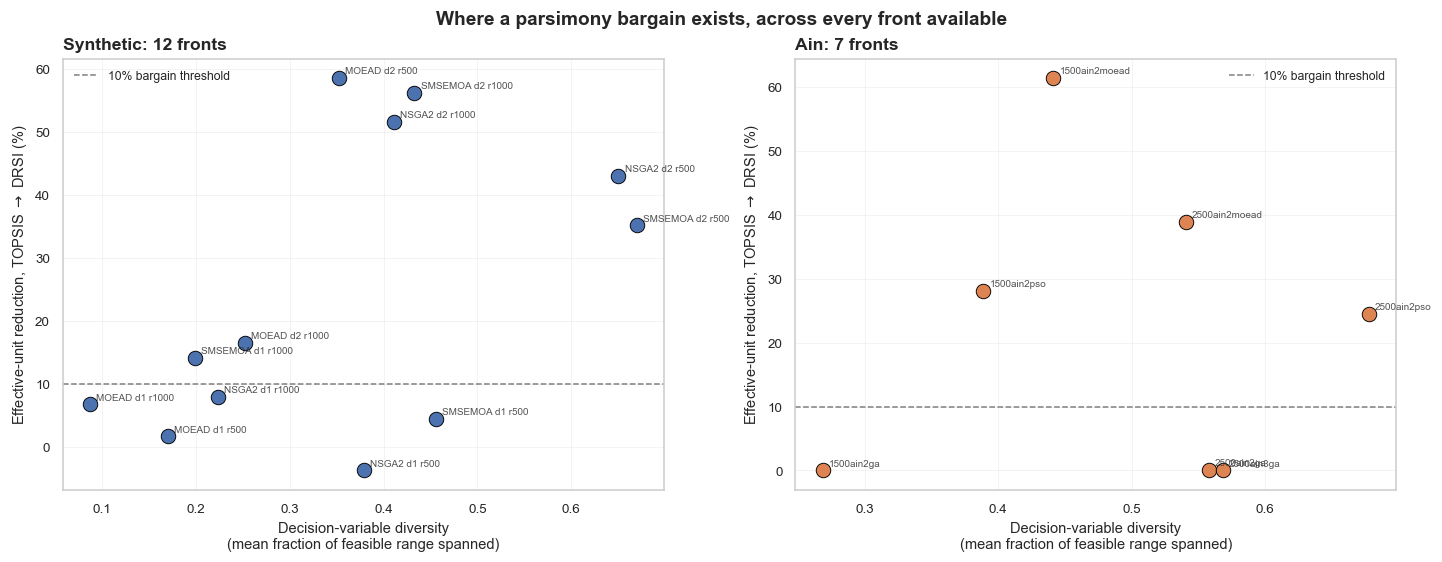

In [77]:
# Figure 7c/7d -- reduction (%) vs decision-variable diversity, all fronts
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

for ax, case, color in zip(axes, ['synthetic', 'Ain'], ['#4C72B0', '#DD8452']):
    sub = all_fronts_df[all_fronts_df.case == case]
    ax.scatter(sub.dv_diversity, sub.reduction_pct, s=90, color=color,
               edgecolor='black', linewidth=0.6, zorder=3)
    for _, r in sub.iterrows():
        ax.annotate(r.label.replace('_range', ' r').replace('_dv', ' d')
                    if case == 'synthetic' else r.label.replace('.csv', ''),
                    (r.dv_diversity, r.reduction_pct), fontsize=6.5,
                    xytext=(4, 3), textcoords='offset points', alpha=0.8)
    ax.axhline(10, color='gray', ls='--', lw=1, label='10% bargain threshold')
    ax.set_xlabel('Decision-variable diversity\n(mean fraction of feasible range spanned)')
    ax.set_ylabel('Effective-unit reduction, TOPSIS $\\to$ DRSI (%)')
    ax.set_title(f'{case.capitalize()}: {len(sub)} fronts', fontsize=11.5,
                 loc='left', fontweight='bold')
    ax.legend(fontsize=8); ax.grid(alpha=0.3, linewidth=0.5); ax.set_axisbelow(True)

fig.suptitle('Where a parsimony bargain exists, across every front available',
             fontsize=12.5, fontweight='bold')
plt.savefig(FIGDIR / 'fig07cd_all_fronts_bargain.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGDIR / 'fig07cd_all_fronts_bargain.pdf', bbox_inches='tight')
plt.show()


### 16.2 Pareto-conditional Sobol -- an apples-to-apples ground truth

In [78]:
# ===== Pareto-conditional Sobol =====
# Global Sobol (sobol_df) samples the FULL feasible box; SHAP on the front
# explains a conditional slice (the Pareto manifold). To compare like with
# like, resample uniformly within the representative synthetic front's own
# per-DV bounds, predict with the validated surrogate (models_syn), and run
# Sobol on those surrogate predictions.
from SALib.sample.sobol import sample as _sobol_sample_cond
from SALib.analyze.sobol import analyze as _sobol_analyze_cond

front_bounds = [(float(front[c].min()), float(front[c].max())) for c in DV_COLS]
# SALib requires strictly increasing bounds; nudge any degenerate (flat) DV
front_bounds = [(lo, hi if hi > lo else lo + 1e-6) for lo, hi in front_bounds]

problem_cond = {'num_vars': N_WELLS, 'names': DV_COLS, 'bounds': front_bounds}

N_COND = 256
X_cond = _sobol_sample_cond(problem_cond, N_COND, calc_second_order=False, seed=SEED)
Q_cond = models_syn['Q'].predict(X_cond)
L_cond = models_syn['L'].predict(X_cond)

Si_cond_Q = _sobol_analyze_cond(problem_cond, Q_cond, calc_second_order=False, seed=SEED)
Si_cond_L = _sobol_analyze_cond(problem_cond, L_cond, calc_second_order=False, seed=SEED)

shap_mean_abs_L = np.abs(shapL_f).mean(axis=0)  # SHAP restricted to this front

sobol_compare_df = pd.DataFrame({
    'DV': DV_COLS,
    'Sobol_global_ST_L': sobol_df['ST_L'].values,
    'Sobol_paretoCond_ST_L': Si_cond_L['ST'],
    'SHAP_mean_abs_L': shap_mean_abs_L,
})
sobol_compare_df.to_csv(RESULTS / 'sobol_pareto_conditional_comparison.csv', index=False)

rho_global_shap, _ = stats.spearmanr(sobol_compare_df.Sobol_global_ST_L, sobol_compare_df.SHAP_mean_abs_L)
rho_pareto_shap, _ = stats.spearmanr(sobol_compare_df.Sobol_paretoCond_ST_L, sobol_compare_df.SHAP_mean_abs_L)
rho_global_pareto, _ = stats.spearmanr(sobol_compare_df.Sobol_global_ST_L, sobol_compare_df.Sobol_paretoCond_ST_L)

print("Pareto-conditional Sobol vs global Sobol vs SHAP (objective L):")
print(sobol_compare_df.round(4).to_string(index=False))
print(f"\nSpearman(global Sobol, SHAP)        = {rho_global_shap:.3f}")
print(f"Spearman(Pareto-conditional Sobol, SHAP) = {rho_pareto_shap:.3f}")
print(f"Spearman(global Sobol, Pareto-conditional Sobol) = {rho_global_pareto:.3f}")
if rho_pareto_shap > rho_global_shap:
    print("\n-> SHAP agrees BETTER with the Pareto-conditional ground truth than "
          "with the global one: consistent with SHAP explaining the conditional "
          "(on-manifold) distribution, not the marginal (full-box) one.")
else:
    print("\n-> SHAP does not agree better with the Pareto-conditional ground "
          "truth here; report both correlations plainly in the manuscript.")


Pareto-conditional Sobol vs global Sobol vs SHAP (objective L):
   DV  Sobol_global_ST_L  Sobol_paretoCond_ST_L  SHAP_mean_abs_L
 DV_1             0.0073                 0.0006           8.0969
 DV_2             0.0459                 0.0013          60.2802
 DV_3             0.0531                 0.1150         231.9980
 DV_4             0.0945                 0.0329         118.5504
 DV_5             0.0056                 0.0021          43.7856
 DV_6             0.0382                 0.0000          19.7268
 DV_7             0.0573                 0.6464         522.8225
 DV_8             0.0849                 0.0455         134.3789
 DV_9             0.0058                 0.0008          55.0851
DV_10             0.0388                 0.0012          47.8988
DV_11             0.0566                 0.0078          48.8642
DV_12             0.0860                 0.0295          93.3355
DV_13             0.0084                 0.0000           1.3858
DV_14             0.0446  

### 16.3 Surrogate residual diagnostics

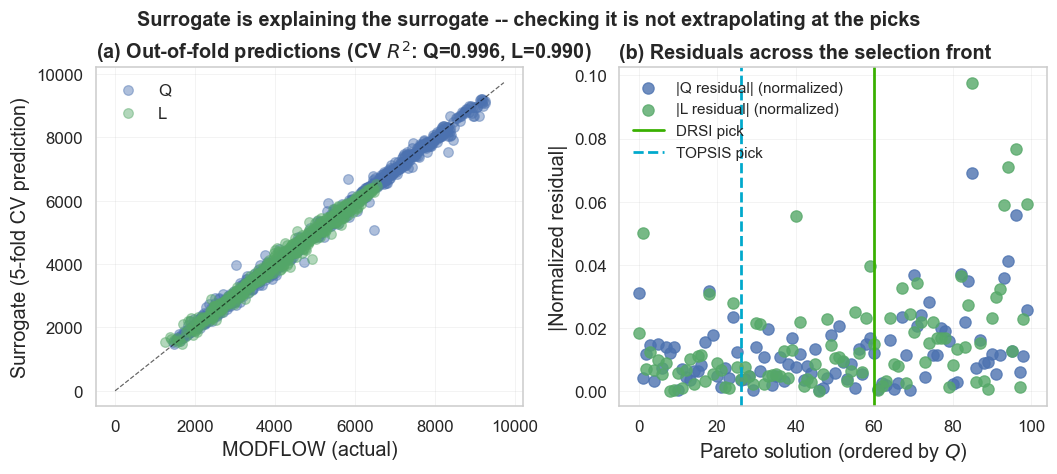

In [79]:
# ===== Surrogate residual diagnostics =====
# Cross-validated (out-of-fold) predictions across the WHOLE pooled synthetic
# dataset, then zoom into the representative front used for selection to
# check the surrogate is not extrapolating near the DRSI / TOPSIS picks.
from sklearn.model_selection import cross_val_predict, KFold

# NOTE: SYN_DF is 12 sequential config blocks concatenated (100 rows each).
# An unshuffled KFold would hold out whole configs at a time and understate
# R^2 relative to the headline metrics (which use the same shuffled 5-fold
# split as fit_surrogate_ensemble). Use the identical shuffled split here so
# this is a fair apples-to-apples residual diagnostic.
_cv_shuffled = KFold(n_splits=5, shuffle=True, random_state=SEED)
Q_pred_cv = cross_val_predict(models_syn['Q'], SYN_DF[DV_COLS], SYN_DF['Q'], cv=_cv_shuffled)
L_pred_cv = cross_val_predict(models_syn['L'], SYN_DF[DV_COLS], SYN_DF['L'], cv=_cv_shuffled)
Q_resid = SYN_DF['Q'].values - Q_pred_cv
L_resid = SYN_DF['L'].values - L_pred_cv
Q_resid_norm = Q_resid / (SYN_DF['Q'].max() - SYN_DF['Q'].min())
L_resid_norm = L_resid / (SYN_DF['L'].max() - SYN_DF['L'].min())

front_mask_bool = ((SYN_DF['algo'] == 'NSGA2') & (SYN_DF['domain'] == 2)
                    & (SYN_DF['dv_high'] == 1000)).values
front_idx_global = np.where(front_mask_bool)[0]
order_by_Q = np.argsort(front['Q'].values)
drsi_pos = int(np.where(order_by_Q == drsi_idx)[0][0])
topsis_pos = int(np.where(order_by_Q == topsis_idx)[0][0])

# Smaller overall canvas so markers read as proportionally larger; bumped
# marker size (s) directly too, plus larger fonts everywhere per JoH sizing.
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.2), constrained_layout=True)

ax = axes[0]
r2_Q_cv = r2_score(SYN_DF['Q'], Q_pred_cv)
r2_L_cv = r2_score(SYN_DF['L'], L_pred_cv)
ax.scatter(SYN_DF['Q'], Q_pred_cv, s=40, alpha=0.45, color='#4C72B0', label='Q')
ax.scatter(SYN_DF['L'], L_pred_cv, s=40, alpha=0.45, color='#55A868', label='L')
lim = [0, max(SYN_DF['Q'].max(), SYN_DF['L'].max()) * 1.05]
ax.plot(lim, lim, 'k--', linewidth=0.8, alpha=0.6)
ax.set_xlabel('MODFLOW (actual)', fontsize=13)
ax.set_ylabel('Surrogate (5-fold CV prediction)', fontsize=13)
ax.set_title(f'(a) Out-of-fold predictions (CV $R^2$: Q={r2_Q_cv:.3f}, L={r2_L_cv:.3f})',
             fontsize=13, loc='left', fontweight='bold')
ax.tick_params(axis='both', labelsize=11)
ax.legend(fontsize=11); ax.grid(alpha=0.3, linewidth=0.5); ax.set_axisbelow(True)

ax = axes[1]
sub_Q = np.abs(Q_resid_norm[front_idx_global])[order_by_Q]
sub_L = np.abs(L_resid_norm[front_idx_global])[order_by_Q]
ax.scatter(range(len(order_by_Q)), sub_Q, s=55, alpha=0.8, color='#4C72B0', label='|Q residual| (normalized)')
ax.scatter(range(len(order_by_Q)), sub_L, s=55, alpha=0.8, color='#55A868', label='|L residual| (normalized)')
ax.axvline(drsi_pos, color='#39b000', lw=1.8, ls='-', label='DRSI pick')
ax.axvline(topsis_pos, color='#00a9cc', lw=1.8, ls='--', label='TOPSIS pick')
ax.set_xlabel('Pareto solution (ordered by $Q$)', fontsize=13)
ax.set_ylabel('|Normalized residual|', fontsize=13)
ax.set_title('(b) Residuals across the selection front', fontsize=13, loc='left', fontweight='bold')
ax.tick_params(axis='both', labelsize=11)
ax.legend(fontsize=10); ax.grid(alpha=0.3, linewidth=0.5); ax.set_axisbelow(True)

fig.suptitle('Surrogate is explaining the surrogate -- checking it is not extrapolating at the picks',
             fontsize=13, fontweight='bold')
plt.savefig(FIGDIR / 'fig08ab_surrogate_residuals.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGDIR / 'fig08ab_surrogate_residuals.pdf', bbox_inches='tight')
plt.show()

### 16.4 Innovization rules -- what separates DRSI-favored from TOPSIS-favored solutions

In [79]:
# ===== Innovization rules: DRSI-favored vs TOPSIS-favored DV patterns =====
# Split the representative synthetic front into its top-20% by DRSI and its
# top-20% by TOPSIS closeness, and report which DVs differ systematically
# between the two groups (effect size), cross-referenced against SHAP and
# Sobol rank. This is the "prescriptive innovization" table for the paper.
n_top = max(5, int(0.2 * len(front)))
drsi_top = front.iloc[np.argsort(-drsi_res['drsi'])[:n_top]]
topsis_top = front.iloc[np.argsort(-drsi_res['closeness'])[:n_top]]

shap_rank_L = {dv: int(r) + 1 for r, dv in enumerate(
    [DV_COLS[i] for i in np.argsort(-shap_results_syn['L']['mean_abs'])])}
sobol_rank_L = {dv: int(r) + 1 for r, dv in enumerate(
    [DV_COLS[i] for i in np.argsort(-sobol_df['ST_L'].values)])}

innov_rows = []
for dv in DV_COLS:
    d_mean, t_mean = drsi_top[dv].mean(), topsis_top[dv].mean()
    d_std, t_std = drsi_top[dv].std(), topsis_top[dv].std()
    pooled_std = np.sqrt((d_std**2 + t_std**2) / 2) + 1e-9
    effect = (d_mean - t_mean) / pooled_std
    innov_rows.append(dict(
        DV=dv, DRSI_mean=d_mean, TOPSIS_mean=t_mean, effect_size=effect,
        direction=('higher in DRSI-favored' if effect > 0.2 else
                    'lower in DRSI-favored' if effect < -0.2 else 'similar'),
        SHAP_rank_L=shap_rank_L[dv], Sobol_rank_L=sobol_rank_L[dv],
    ))
innov_df = pd.DataFrame(innov_rows).sort_values('effect_size', key=np.abs, ascending=False)
innov_df.to_csv(RESULTS / 'innovization_rules_synthetic.csv', index=False)

print(f"Innovization rules -- top {n_top} DRSI-favored vs top {n_top} TOPSIS-favored "
      f"solutions on the representative synthetic front:\n")
print(innov_df.round(2).to_string(index=False))
print("\nStrongest 5 rules (|effect size| largest):")
for _, r in innov_df.head(5).iterrows():
    print(f"  {r.DV}: {r.direction} (DRSI {r.DRSI_mean:.0f} vs TOPSIS {r.TOPSIS_mean:.0f}, "
          f"effect={r.effect_size:+.2f}, SHAP rank={r.SHAP_rank_L}, Sobol rank={r.Sobol_rank_L})")


Innovization rules -- top 20 DRSI-favored vs top 20 TOPSIS-favored solutions on the representative synthetic front:

   DV  DRSI_mean  TOPSIS_mean  effect_size              direction  SHAP_rank_L  Sobol_rank_L
 DV_1     646.97       767.78        -5.22  lower in DRSI-favored           19            18
 DV_3     666.93       105.89         4.63 higher in DRSI-favored            2            10
 DV_7     808.61        91.72         4.44 higher in DRSI-favored            1             7
 DV_9     699.84       778.04        -3.25  lower in DRSI-favored           13            19
 DV_5     698.81       792.96        -3.00  lower in DRSI-favored           14            20
DV_11     173.66        61.32         1.86 higher in DRSI-favored           10             8
DV_12     165.55        65.37         1.82 higher in DRSI-favored            6             4
 DV_8     222.26       105.74         1.62 higher in DRSI-favored            3             5
DV_15     209.05       160.31         1.42 hig

### 16.5 Ain management-scheme comparison

Ain management-scheme comparison:
                         scheme  index        Q        L  closeness  eff_communes  reliability  simplicity  DRSI_score  closeness_loss_vs_TOPSIS_pct
TOPSIS (compromise programming)     56 105000.0 304000.0      0.672         3.968        0.921       0.901       0.819                         0.000
                           DRSI    106 114000.0 298000.0      0.671         4.123        0.922       0.896       0.828                         0.080
                     Knee point    172 466000.0  47500.0      0.368         4.397        0.924       0.887       0.420                        45.166
                Max reliability    261 477000.0   7590.0      0.335         2.799        0.932       0.940       0.310                        50.137


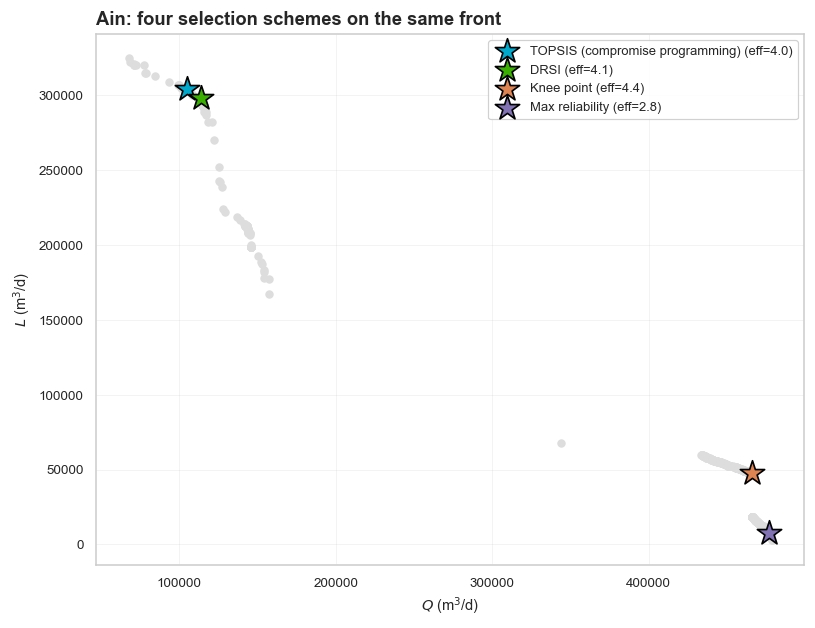

In [80]:
# ===== Ain management-scheme comparison: TOPSIS / DRSI / knee / max-reliability =====
if AIN_AVAILABLE:
    schemes = {}
    schemes['TOPSIS (compromise programming)'] = ta
    schemes['DRSI'] = da

    reps_ain = find_representative_pareto_points(ain_front)
    schemes['Knee point'] = reps_ain['knee']

    schemes['Max reliability'] = int(np.argmax(drsi_ain['reliability']))

    rows = []
    for name, idx_s in schemes.items():
        rows.append(dict(
            scheme=name, index=idx_s,
            Q=float(ain_front.Q[idx_s]), L=float(ain_front.L[idx_s]),
            closeness=float(drsi_ain['closeness'][idx_s]),
            eff_communes=float(drsi_ain['eff_wells'][idx_s]),
            reliability=float(drsi_ain['reliability'][idx_s]),
            simplicity=float(drsi_ain['simplicity'][idx_s]),
            DRSI_score=float(drsi_ain['drsi'][idx_s]),
        ))
    scheme_df = pd.DataFrame(rows)
    cp_closeness = scheme_df.loc[scheme_df.scheme.str.startswith('TOPSIS'), 'closeness'].iloc[0]
    scheme_df['closeness_loss_vs_TOPSIS_pct'] = 100 * (1 - scheme_df['closeness'] / cp_closeness)
    scheme_df.to_csv(RESULTS / 'ain_management_scheme_comparison.csv', index=False)

    print("Ain management-scheme comparison:")
    print(scheme_df.round(3).to_string(index=False))

    fig, ax = plt.subplots(figsize=(7.5, 5.8))
    colors_s = ['#00a9cc', '#39b000', '#DD8452', '#8172B3']
    sc = ax.scatter(ain_front.Q, ain_front.L, c='#dddddd', s=22, zorder=1)
    for (name, idx_s), c in zip(schemes.items(), colors_s):
        ax.scatter(ain_front.Q[idx_s], ain_front.L[idx_s], s=280, marker='*',
                   color=c, edgecolor='black', linewidth=1.1, zorder=5,
                   label=f"{name} (eff={drsi_ain['eff_wells'][idx_s]:.1f})")
    ax.set_xlabel(r'$Q$ (m$^3$/d)'); ax.set_ylabel(r'$L$ (m$^3$/d)')
    ax.set_title('Ain: four selection schemes on the same front', fontsize=12,
                 loc='left', fontweight='bold')
    ax.legend(fontsize=8.5, frameon=True, framealpha=0.9)
    ax.grid(alpha=0.3, linewidth=0.5); ax.set_axisbelow(True)
    plt.tight_layout()
    plt.savefig(FIGDIR / 'fig_ain_scheme_comparison.png', dpi=300, bbox_inches='tight')
    plt.savefig(FIGDIR / 'fig_ain_scheme_comparison.pdf', bbox_inches='tight')
    plt.show()


---
## 16.6 Physically-exact response matrix (superposition ground truth)

Beyond Sobol indices and SHAP (both of which explain the *surrogate*), we compute $R_i$ -- the steady-state fraction of well $i$'s abstraction that is ultimately captured from the river -- directly from MODFLOW via unit-rate superposition:

$$R_i = \frac{L_{baseline} - L_i}{q_{unit}}$$

where $L_i$ is river leakage when only well $i$ pumps at $q_{unit}$ and all others are off, and $L_{baseline}$ is $L$ under zero pumping. This needs $N_{WELLS}+1=21$ MODFLOW runs per boundary variant (42 total), each on the order of ~1 s (empirical rate from the Sobol run: 21,504 evals / ~7h $\approx$ 1.17 s/eval).

Caveat: NPF uses `icelltype=1` (unconfined, Newton-solved), so the system is technically nonlinear and superposition is an approximation. The closed boundary (variant 1, no other sink) gives a clean internal check: by water balance, $R_i \to 1.0$ for every well, since the river is the only possible sink at steady state. A systematic deviation would flag solver looseness or nonlinearity strong enough to break superposition at $q_{unit}$.


In [81]:
SOBOL_RUNTIME_HR = 7.0
SOBOL_N_EVALS = 21504
sec_per_eval = SOBOL_RUNTIME_HR * 3600 / SOBOL_N_EVALS
n_runs_planned = len(DOMAIN_VARIANTS) * (N_WELLS + 1)
print(f"Empirical MODFLOW rate (from Sobol run): {sec_per_eval:.2f} s/eval")
print(f"Planned runs: {n_runs_planned} -> est. wall-clock ~{n_runs_planned*sec_per_eval/60:.1f} min (excludes per-run workspace overhead)")


Empirical MODFLOW rate (from Sobol run): 1.17 s/eval
Planned runs: 42 -> est. wall-clock ~0.8 min (excludes per-run workspace overhead)


In [82]:
# ===== Response matrix via unit-rate superposition (Action 1) =====
Q_UNIT = 100.0  # m3/d; mid-range of per-well DV bounds (50-500 / 50-1000)

response_matrix_results = {}
for dv in DOMAIN_VARIANTS:
    cache_file = CACHE / f'response_matrix_dv{dv}.pkl'
    if USE_CACHE and cache_file.exists():
        with open(cache_file, 'rb') as f:
            response_matrix_results[dv] = pickle.load(f)
        print(f"Loaded response matrix for variant {dv} from cache.")
        continue

    print(f"Computing response matrix for domain_variant={dv} "
          f"({N_WELLS} unit-rate runs + 1 baseline)...", flush=True)
    t0 = time.time()

    base_ws = MFWS / f'respmat_baseline_dv{dv}'
    res_base = evaluate_pumping(np.zeros(N_WELLS), domain_variant=dv, workspace=base_ws)
    assert res_base['ok'], f"Baseline run failed for variant {dv}"
    L_baseline = res_base['L']

    L_well = np.zeros(N_WELLS)
    ok_flags = np.zeros(N_WELLS, dtype=bool)
    for i in range(N_WELLS):
        rates = np.zeros(N_WELLS)
        rates[i] = Q_UNIT
        ws = MFWS / f'respmat_dv{dv}_well{i+1:02d}'
        res_i = evaluate_pumping(rates, domain_variant=dv, workspace=ws)
        L_well[i] = res_i['L']
        ok_flags[i] = res_i['ok']
        if not res_i['ok']:
            print(f"  WARNING: well {i+1} run FAILED (variant {dv}) -> R_i will be NaN")
            L_well[i] = np.nan

    R = (L_baseline - L_well) / Q_UNIT
    elapsed = time.time() - t0

    response_matrix_results[dv] = dict(
        R=R, L_baseline=L_baseline, L_well=L_well, q_unit=Q_UNIT,
        domain_variant=dv, ok=ok_flags, elapsed_sec=elapsed,
    )
    with open(cache_file, 'wb') as f:
        pickle.dump(response_matrix_results[dv], f)
    print(f"  Done in {elapsed:.1f}s. R range [{np.nanmin(R):.3f}, {np.nanmax(R):.3f}], "
          f"mean={np.nanmean(R):.3f}")


Computing response matrix for domain_variant=1 (20 unit-rate runs + 1 baseline)...


  Done in 3.9s. R range [0.983, 1.002], mean=0.999
Computing response matrix for domain_variant=2 (20 unit-rate runs + 1 baseline)...


  Done in 4.7s. R range [0.199, 0.883], mean=0.572


In [83]:
# ===== Water-balance verification =====
R_dv1 = response_matrix_results[1]['R']
R_dv2 = response_matrix_results[2]['R']

print("=== Water-balance verification: closed boundary (variant 1) ===")
print(f"Mean R_i (closed) = {np.nanmean(R_dv1):.4f}  (theory -> 1.0)")
print(f"Min/Max R_i       = {np.nanmin(R_dv1):.4f} / {np.nanmax(R_dv1):.4f}")
print(f"Std R_i            = {np.nanstd(R_dv1):.4f}")
max_dev = np.nanmax(np.abs(R_dv1 - 1.0))
TOL = 0.05
print(f"Max |R_i - 1|      = {max_dev:.4f}  (tolerance = {TOL})")
if max_dev < TOL:
    print("PASS: closed-boundary R_i consistent with water-balance theory.")
else:
    print("WARNING: deviation exceeds tolerance -- check IMS convergence or "
          "superposition breakdown from the unconfined nonlinearity at q_unit.")

print("\n=== Open boundary (variant 2): R_i <= 1 expected, spatial variation expected ===")
print(f"Mean R_i (open) = {np.nanmean(R_dv2):.4f}, range "
      f"[{np.nanmin(R_dv2):.4f}, {np.nanmax(R_dv2):.4f}]")

dist_to_river_m = [(20 - 1 - c) * 250.0 for (_, r, c) in WELL_LOCS]
response_matrix_df = pd.DataFrame({
    'DV': DV_COLS,
    'row': [r for (_, r, c) in WELL_LOCS],
    'col': [c for (_, r, c) in WELL_LOCS],
    'dist_to_river_m': dist_to_river_m,
    'R_dv1_closed': R_dv1,
    'R_dv2_open': R_dv2,
})
response_matrix_df.to_csv(RESULTS / 'response_matrix.csv', index=False)
response_matrix_df.round(4)


=== Water-balance verification: closed boundary (variant 1) ===
Mean R_i (closed) = 0.9987  (theory -> 1.0)
Min/Max R_i       = 0.9827 / 1.0018
Std R_i            = 0.0048
Max |R_i - 1|      = 0.0173  (tolerance = 0.05)
PASS: closed-boundary R_i consistent with water-balance theory.

=== Open boundary (variant 2): R_i <= 1 expected, spatial variation expected ===
Mean R_i (open) = 0.5722, range [0.1991, 0.8829]


,DV,row,col,dist_to_river_m,R_dv1_closed,R_dv2_open
0,DV_1,4,3,4000.0,1.0002,0.2343
1,DV_2,4,8,2750.0,1.0005,0.5864
2,DV_3,4,13,1500.0,1.0004,0.6244
3,DV_4,4,17,500.0,0.9992,0.8383
4,DV_5,12,3,4000.0,0.9827,0.1991
5,DV_6,12,8,2750.0,1.0003,0.5335
6,DV_7,12,13,1500.0,1.0001,0.6540
7,DV_8,12,17,500.0,0.9983,0.7894
8,DV_9,20,3,4000.0,0.9998,0.2037
9,DV_10,20,8,2750.0,0.9997,0.5396


### 16.6.1 SHAP vs. the physically-exact response matrix

Aggregate comparison (front = NSGA2, open boundary, DV range 1000, n=20 wells):
  Spearman(SHAP mean|phi|_L, R_i) = 0.574 (p=0.0081)
  Pearson (SHAP mean|phi|_L, R_i) = 0.346, R^2=0.120


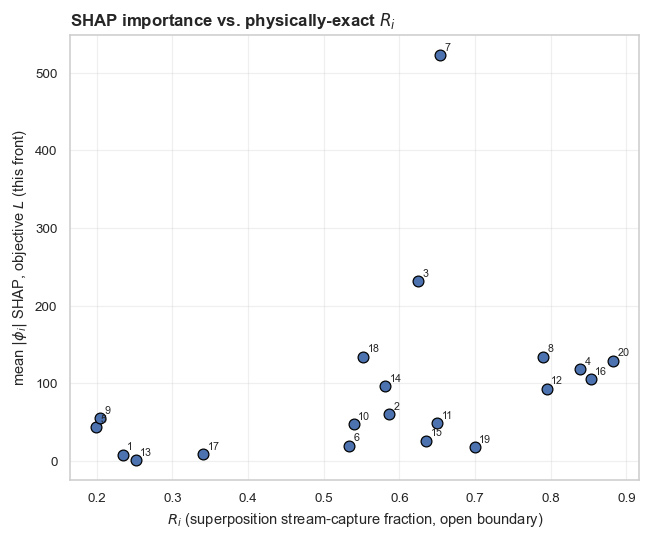


Interventional-SHAP check phi_i ~= -R_i*(q_i - qbar_i):
  Spearman = 0.891 (p=0.00e+00), Pearson r = 0.810
  R^2 (vs 1:1 line) = 0.623


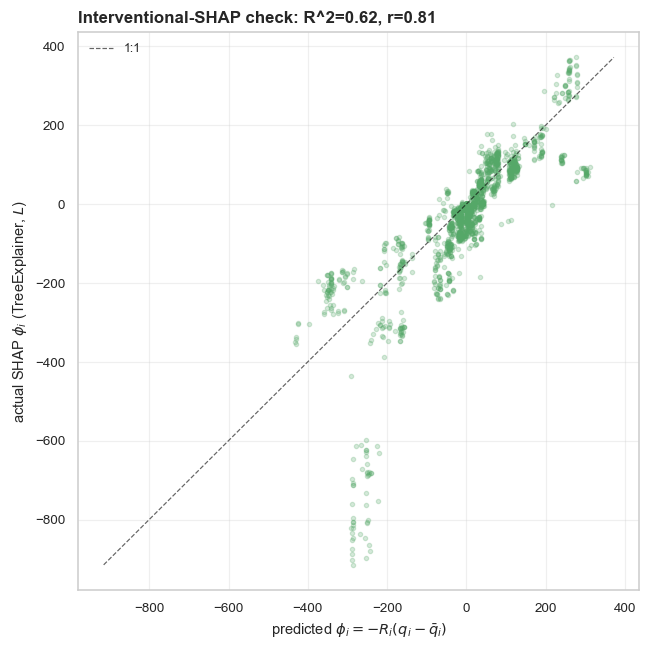

In [84]:
# (a) Aggregate: mean|SHAP_L| on the representative front vs R_i (open boundary)
shap_mean_abs_L_front = np.abs(shapL_f).mean(axis=0)
R_open = R_dv2

rho_agg, p_agg = stats.spearmanr(shap_mean_abs_L_front, R_open)
r_agg, p_r_agg = stats.pearsonr(shap_mean_abs_L_front, R_open)
print("Aggregate comparison (front = NSGA2, open boundary, DV range 1000, n=20 wells):")
print(f"  Spearman(SHAP mean|phi|_L, R_i) = {rho_agg:.3f} (p={p_agg:.4f})")
print(f"  Pearson (SHAP mean|phi|_L, R_i) = {r_agg:.3f}, R^2={r_agg**2:.3f}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(R_open, shap_mean_abs_L_front, s=50, c='#4C72B0', edgecolor='k')
for i, name in enumerate(DV_COLS):
    ax.annotate(name.replace('DV_', ''), (R_open[i], shap_mean_abs_L_front[i]),
                fontsize=7, xytext=(3, 3), textcoords='offset points')
ax.set_xlabel(r'$R_i$ (superposition stream-capture fraction, open boundary)')
ax.set_ylabel(r'mean $|\phi_i|$ SHAP, objective $L$ (this front)')
ax.set_title('SHAP importance vs. physically-exact $R_i$', fontsize=11,
             loc='left', fontweight='bold')
ax.grid(alpha=0.3); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(FIGDIR / 'fig_shap_vs_response_matrix_aggregate.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGDIR / 'fig_shap_vs_response_matrix_aggregate.pdf', bbox_inches='tight')
plt.show()

# (b) Interventional-SHAP check: phi_i(solution) ~= -R_i * (q_i - qbar_i)
Q_front = front[DV_COLS].values
qbar = Q_front.mean(axis=0)  # front-local mean pumping per well
phi_pred = -R_open[None, :] * (Q_front - qbar[None, :])
phi_actual = shapL_f

rho_pred, p_pred = stats.spearmanr(phi_pred.ravel(), phi_actual.ravel())
r_pred, _ = stats.pearsonr(phi_pred.ravel(), phi_actual.ravel())
r2_pred = r2_score(phi_actual.ravel(), phi_pred.ravel())

print(f"\nInterventional-SHAP check phi_i ~= -R_i*(q_i - qbar_i):")
print(f"  Spearman = {rho_pred:.3f} (p={p_pred:.2e}), Pearson r = {r_pred:.3f}")
print(f"  R^2 (vs 1:1 line) = {r2_pred:.3f}")
if r2_pred < 0.1:
    print("  NOTE: weak fit against front-local qbar; TreeExplainer's implicit "
          "background may be the pooled SYN_DF instead -- rerun with "
          "qbar = SYN_DF[DV_COLS].mean(axis=0).values as a robustness check.")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(phi_pred.ravel(), phi_actual.ravel(), s=8, alpha=0.25, c='#55A868')
lims = [min(phi_pred.min(), phi_actual.min()), max(phi_pred.max(), phi_actual.max())]
ax.plot(lims, lims, 'k--', lw=0.8, alpha=0.6, label='1:1')
ax.set_xlabel(r'predicted $\phi_i = -R_i(q_i-\bar q_i)$')
ax.set_ylabel(r'actual SHAP $\phi_i$ (TreeExplainer, $L$)')
ax.set_title(f'Interventional-SHAP check: R^2={r2_pred:.2f}, r={r_pred:.2f}',
             fontsize=11, loc='left', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(FIGDIR / 'fig_shap_interventional_check.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGDIR / 'fig_shap_interventional_check.pdf', bbox_inches='tight')
plt.show()

response_shap_compare_df = pd.DataFrame({
    'DV': DV_COLS, 'R_i_open': R_open, 'SHAP_mean_abs_L_front': shap_mean_abs_L_front,
})
response_shap_compare_df.to_csv(RESULTS / 'response_matrix_vs_shap_comparison.csv', index=False)


### 16.6.2 Spatial map of $R_i$ on the physical well grid

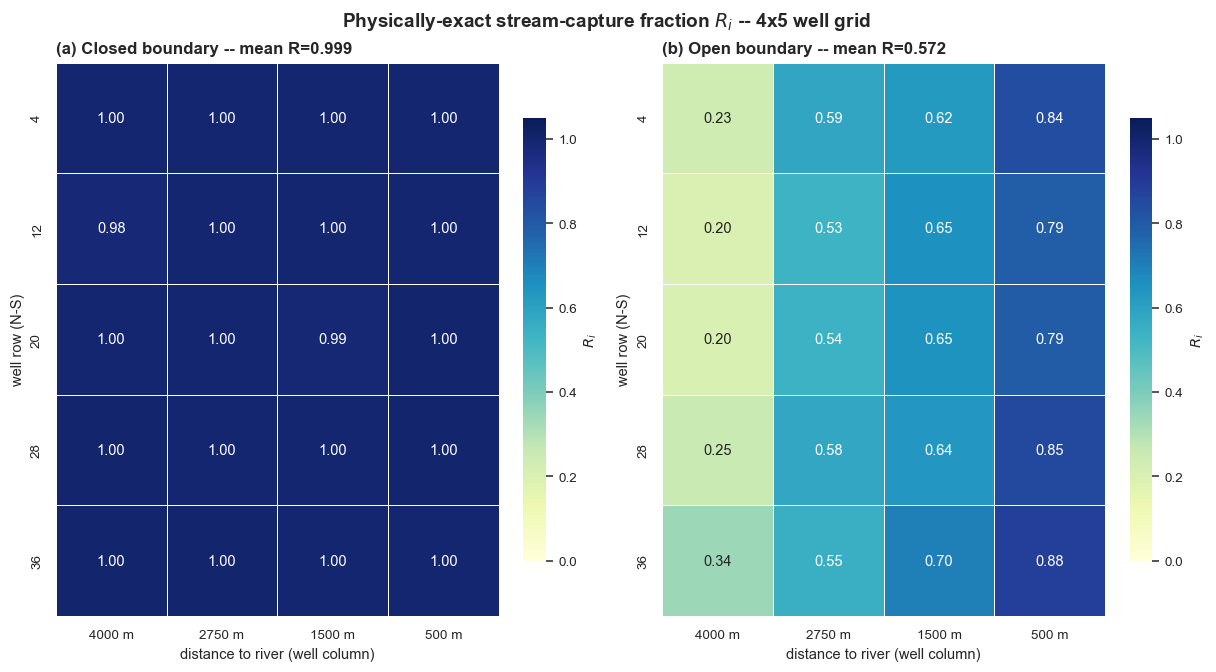

In [85]:
well_rows_labels = [4, 12, 20, 28, 36]
well_cols_labels = [3, 8, 13, 17]
dist_labels = [f'{(20-1-c)*250:.0f} m' for c in well_cols_labels]

def to_grid(values_20):
    return np.asarray(values_20).reshape(5, 4)

R1_grid, R2_grid = to_grid(R_dv1), to_grid(R_dv2)

fig, axes = plt.subplots(1, 2, figsize=(11, 6), constrained_layout=True)
hm_kw_r = dict(annot=True, fmt='.2f', square=True, linewidths=0.5, linecolor='white',
               cbar_kws={'shrink': 0.8, 'label': r'$R_i$'})
sns.heatmap(R1_grid, cmap='YlGnBu', vmin=0, vmax=1.05, ax=axes[0],
            xticklabels=dist_labels, yticklabels=well_rows_labels, **hm_kw_r)
axes[0].set_title(f'(a) Closed boundary -- mean R={np.nanmean(R_dv1):.3f}',
                   fontsize=11, loc='left', fontweight='bold')
axes[0].set_xlabel('distance to river (well column)'); axes[0].set_ylabel('well row (N-S)')

sns.heatmap(R2_grid, cmap='YlGnBu', vmin=0, vmax=1.05, ax=axes[1],
            xticklabels=dist_labels, yticklabels=well_rows_labels, **hm_kw_r)
axes[1].set_title(f'(b) Open boundary -- mean R={np.nanmean(R_dv2):.3f}',
                   fontsize=11, loc='left', fontweight='bold')
axes[1].set_xlabel('distance to river (well column)'); axes[1].set_ylabel('well row (N-S)')

fig.suptitle('Physically-exact stream-capture fraction $R_i$ -- 4x5 well grid',
             fontsize=12.5, fontweight='bold')
plt.savefig(FIGDIR / 'fig_response_matrix_spatial_grid.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGDIR / 'fig_response_matrix_spatial_grid.pdf', bbox_inches='tight')
plt.show()


---
## 16.7 Hill-number / $L_0$ parsimony metric (replacing SHAP-share concentration)

The paper's `eff_wells` ($n_{eff}$) is the participation ratio ($D_2$, Hill number of order 2) computed on **SHAP shares**. The operational quantity a manager actually pays for is the count of wells whose **abstraction rate** exceeds a reporting threshold ($D_0$). Since Hill numbers are non-increasing in order ($D_\infty \le D_2 \le D_1 \le D_0$), $D_2$ is a provable *lower bound* on $D_0$ -- the paper's parsimony claim may understate the true active-well count. This section computes both, on all 19 fronts, and checks the bound and the correlation directly.

## 16.8 $\varepsilon$-constrained cardinality minimization -- the parsimony frontier $N^*(\varepsilon)$

$N^*(\varepsilon) = \min\{D_0(x) : x \in \mathcal{P},\ D(x) \le (1+\varepsilon)D_{min}\}$, where $D(x)$ is the Euclidean merit deficit from the ideal point in normalized objective space (the same normalization TOPSIS already uses). This is the marginal-price-of-parsimony curve: for a given tolerance on objective merit, the minimum number of active wells achievable.

## 16.9 Comparator selection rules

Two parameter-light alternatives to DRSI, computed on the same 19 fronts: the lexicographic $\varepsilon$-rule (minimum $D_0$ among solutions within $\varepsilon$ of the objective optimum) and an augmented weighted Tchebycheff scalarization with an explicit cardinality penalty.


In [86]:
# PLACEHOLDER threshold: a well counts as 'active' (contributes to D0) if its rate is
# >= 1% of that solution's own maximum well rate. No confirmed regulatory abstraction
# threshold (e.g. French IOTA nomenclature volumes) was available this session -- 
# replace Q_THRESH_FRAC, or better, an absolute m3/d threshold, if a real one exists.
Q_THRESH_FRAC = 0.01

def hill_numbers(q_row, thresh_frac=Q_THRESH_FRAC):
    q = np.clip(np.asarray(q_row, float), 0, None)
    total = q.sum()
    if total <= 0:
        return dict(D0=0, D1=0.0, D2=0.0, Dinf=0.0)
    u = q / total
    qmax = q.max()
    D0 = int((q >= thresh_frac * qmax).sum()) if qmax > 0 else 0
    u_pos = u[u > 0]
    D1 = float(np.exp(-(u_pos * np.log(u_pos)).sum())) if len(u_pos) else 0.0
    ssq = (u ** 2).sum()
    D2 = float(1.0 / ssq) if ssq > 0 else 0.0
    Dinf = float(1.0 / u.max()) if u.max() > 0 else 0.0
    return dict(D0=D0, D1=D1, D2=D2, Dinf=Dinf)

def merit_deficit(df, obj_cols=('Q', 'L')):
    X = df[list(obj_cols)].values.astype(float)
    norm = X / np.sqrt((X ** 2).sum(axis=0))
    ideal = norm.max(axis=0)
    return np.sqrt(((norm - ideal) ** 2).sum(axis=1))

# Build the list of all 19 fronts (mirrors the all-fronts analysis already above)
front_records = []
for key, sub in synthetic_fronts.items():
    algo, dv_tag, range_tag = key.split('_')
    domain = int(dv_tag.replace('dv', ''))
    dv_high = int(range_tag.replace('range', ''))
    mask = ((SYN_DF['algo'] == algo) & (SYN_DF['domain'] == domain)
             & (SYN_DF['dv_high'] == dv_high)).values
    if mask.sum() < 10:
        continue
    idx = np.where(mask)[0]
    front_records.append(dict(
        case='synthetic', label=key, df=SYN_DF.loc[mask].reset_index(drop=True),
        dv_cols=DV_COLS, shapL=shap_results_syn['L']['shap_values'][idx], rel=relL,
    ))

if AIN_AVAILABLE:
    for fname in AIN_DF['source_file'].unique():
        mask = (AIN_DF['source_file'] == fname).values
        if mask.sum() < 10:
            continue
        idx = np.where(mask)[0]
        front_records.append(dict(
            case='Ain', label=fname, df=AIN_DF.loc[mask].reset_index(drop=True),
            dv_cols=AIN_DV_COLS, shapL=shap_results_ain['L']['shap_values'][idx], rel=relL_a,
        ))

print(f"Built {len(front_records)} front records "
      f"({sum(r['case']=='synthetic' for r in front_records)} synthetic, "
      f"{sum(r['case']=='Ain' for r in front_records)} Ain)")


Built 19 front records (12 synthetic, 7 Ain)


In [87]:
eps_grid = np.linspace(0, 0.5, 51)
W_TCHEB = (0.5, 0.5)
RHO_TCHEB = 0.01
LAMBDA_TCHEB = 0.05
EPS_LEX = 0.05

hill_rows, frontier_rows, scheme_rows = [], [], []

for rec in front_records:
    df, dv_cols, shapL, rel = rec['df'], rec['dv_cols'], rec['shapL'], rec['rel']
    n = len(df)
    q = df[dv_cols].values

    D0 = np.zeros(n, dtype=int); D1 = np.zeros(n); D2u = np.zeros(n); Dinf = np.zeros(n)
    for i in range(n):
        h = hill_numbers(q[i])
        D0[i], D1[i], D2u[i], Dinf[i] = h['D0'], h['D1'], h['D2'], h['Dinf']

    d = compute_drsi(df, shapL, rel, weights=(1, 1, 1))
    D2_shap = d['eff_wells']

    for i in range(n):
        hill_rows.append(dict(case=rec['case'], label=rec['label'], sol=i,
                               D0=D0[i], D1=D1[i], D2_abstraction=D2u[i], Dinf=Dinf[i],
                               D2_shap=D2_shap[i], closeness=d['closeness'][i], drsi=d['drsi'][i]))

    Dm = merit_deficit(df); Dmin = Dm.min()
    for eps in eps_grid:
        feasible = Dm <= (1 + eps) * Dmin
        Nstar = int(D0[feasible].min()) if feasible.any() else int(D0.max())
        frontier_rows.append(dict(case=rec['case'], label=rec['label'], eps=eps, Nstar=Nstar))

    t_i = int(np.argmax(d['closeness'])); d_i = int(np.argmax(d['drsi']))

    feasible_lex = Dm <= (1 + EPS_LEX) * Dmin
    if feasible_lex.any():
        cand = np.where(feasible_lex)[0]
        min_d0 = D0[cand].min()
        tied = cand[D0[cand] == min_d0]
        lex_i = tied[np.argmin(Dm[tied])]
    else:
        lex_i = t_i

    z = df[['Q', 'L']].values.astype(float)
    z = (z - z.min(axis=0)) / (z.max(axis=0) - z.min(axis=0) + 1e-12)
    resid = 1 - z
    tcheb = np.maximum(W_TCHEB[0]*resid[:, 0], W_TCHEB[1]*resid[:, 1]) + RHO_TCHEB*resid.sum(axis=1)
    D0_norm = (D0 - D0.min()) / (D0.max() - D0.min() + 1e-12)
    tch_i = int(np.argmin(tcheb + LAMBDA_TCHEB * D0_norm))

    for name, idx_pick in [('TOPSIS', t_i), ('DRSI', d_i),
                            (f'Lexicographic (eps={EPS_LEX})', lex_i),
                            ('Augmented Tchebycheff', tch_i)]:
        scheme_rows.append(dict(case=rec['case'], label=rec['label'], scheme=name,
                                 Q=float(df['Q'].values[idx_pick]), L=float(df['L'].values[idx_pick]),
                                 closeness=float(d['closeness'][idx_pick]),
                                 D0=int(D0[idx_pick]), D2_shap=float(D2_shap[idx_pick])))

hill_df = pd.DataFrame(hill_rows)
frontier_df = pd.DataFrame(frontier_rows)
scheme_df_all = pd.DataFrame(scheme_rows)

hill_df.to_csv(RESULTS / 'hill_numbers_all_fronts.csv', index=False)
frontier_df.to_csv(RESULTS / 'parsimony_frontier_all_fronts.csv', index=False)
scheme_df_all.to_csv(RESULTS / 'selection_scheme_comparison_all_fronts.csv', index=False)

ineq_ok = np.all((hill_df['Dinf'] <= hill_df['D2_abstraction'] + 1e-6) &
                 (hill_df['D2_abstraction'] <= hill_df['D1'] + 1e-6) &
                 (hill_df['D1'] <= hill_df['D0'] + 1e-6))
print(f"Hill numbers: {len(hill_df)} solutions across {len(front_records)} fronts")
print(f"Power-mean inequality (Dinf<=D2<=D1<=D0) holds for ALL solutions: {ineq_ok}")

rho_d0d2, p_d0d2 = stats.spearmanr(hill_df['D0'], hill_df['D2_shap'])
print(f"Spearman(abstraction D0, SHAP-based D2/eff_wells), n={len(hill_df)}: "
      f"rho={rho_d0d2:.3f} (p={p_d0d2:.2e})")
print(f"Mean D0 (true active-well count, threshold={Q_THRESH_FRAC:.0%} of own max): "
      f"{hill_df['D0'].mean():.2f}")
print(f"Mean D2_shap (paper's current eff_wells):  {hill_df['D2_shap'].mean():.2f}")
print(f"D2_shap <= D0 holds in {(hill_df['D2_shap'] <= hill_df['D0']+1e-6).mean()*100:.1f}% of solutions "
      f"(should be ~100% if the bound holds empirically as well as in theory)")


Hill numbers: 2017 solutions across 19 fronts
Power-mean inequality (Dinf<=D2<=D1<=D0) holds for ALL solutions: True
Spearman(abstraction D0, SHAP-based D2/eff_wells), n=2017: rho=-0.671 (p=5.15e-264)
Mean D0 (true active-well count, threshold=1% of own max): 24.46
Mean D2_shap (paper's current eff_wells):  7.15
D2_shap <= D0 holds in 100.0% of solutions (should be ~100% if the bound holds empirically as well as in theory)


### Hill-number profile: TOPSIS vs. DRSI picks, representative fronts

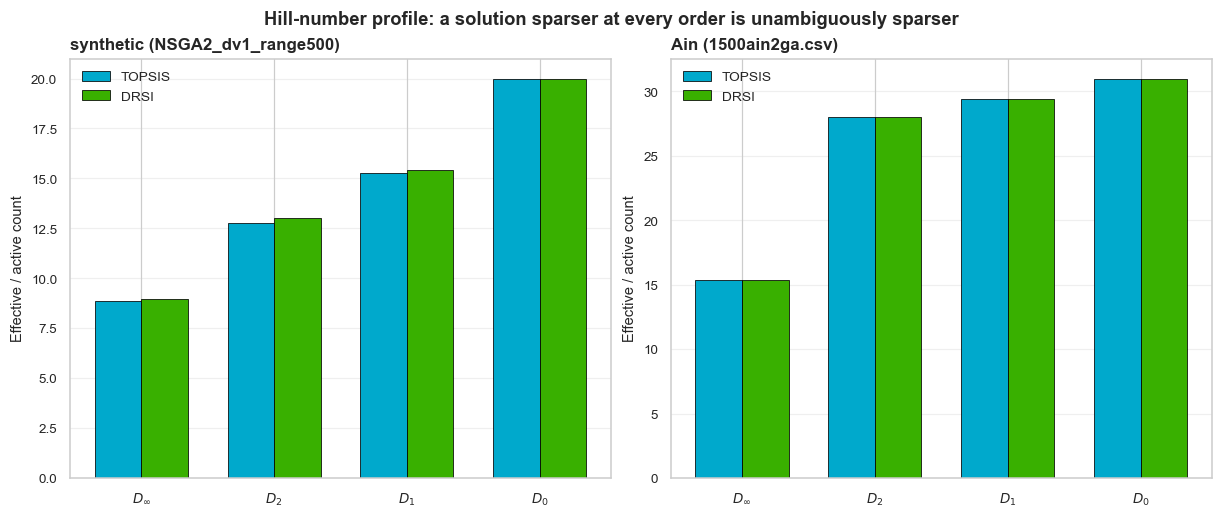

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), constrained_layout=True)

for ax, case_name in zip(axes, ['synthetic', 'Ain']):
    sub_hill = hill_df[(hill_df.case == case_name)]
    label0 = sub_hill.label.iloc[0]
    one = sub_hill[sub_hill.label == label0].reset_index(drop=True)
    t_i = int(one['closeness'].values.argmax())
    d_i = int(one['drsi'].values.argmax())
    orders = ['Dinf', 'D2_abstraction', 'D1', 'D0']
    labels = [r'$D_\infty$', r'$D_2$', r'$D_1$', r'$D_0$']
    t_vals = [one.iloc[t_i][o] for o in orders]
    d_vals = [one.iloc[d_i][o] for o in orders]
    x = np.arange(4); w = 0.35
    ax.bar(x - w/2, t_vals, w, label='TOPSIS', color='#00a9cc', edgecolor='black', linewidth=0.5)
    ax.bar(x + w/2, d_vals, w, label='DRSI', color='#39b000', edgecolor='black', linewidth=0.5)
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_ylabel('Effective / active count')
    ax.set_title(f'{case_name} ({label0})', fontsize=11, loc='left', fontweight='bold')
    ax.legend(fontsize=9); ax.grid(alpha=0.3, axis='y'); ax.set_axisbelow(True)

fig.suptitle('Hill-number profile: a solution sparser at every order is unambiguously sparser',
             fontsize=12, fontweight='bold')
plt.savefig(FIGDIR / 'fig_hill_profile_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGDIR / 'fig_hill_profile_comparison.pdf', bbox_inches='tight')
plt.show()


### $N^*(\varepsilon)$ parsimony frontier, all 19 fronts

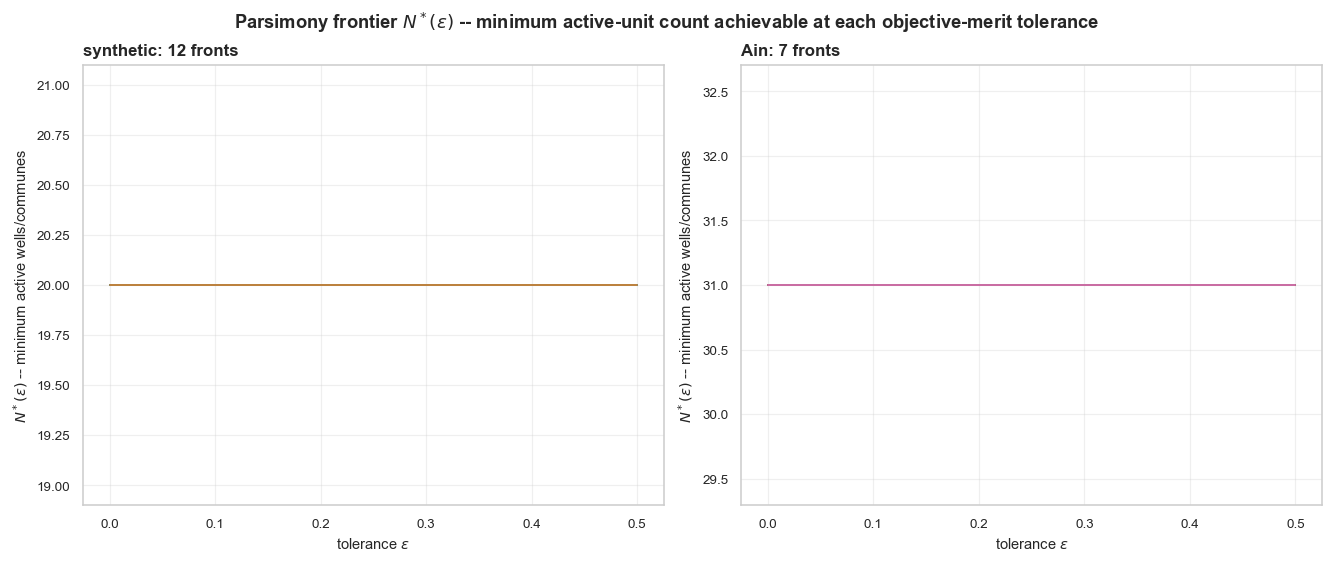

                                    closeness    D0  D2_shap
case      scheme                                            
Ain       Augmented Tchebycheff         0.551  31.0    5.745
          DRSI                          0.636  31.0    4.934
          Lexicographic (eps=0.05)      0.612  31.0    6.783
          TOPSIS                        0.651  31.0    6.722
synthetic Augmented Tchebycheff         0.548  20.0    8.718
          DRSI                          0.562  20.0    6.796
          Lexicographic (eps=0.05)      0.591  20.0    9.572
          TOPSIS                        0.605  20.0    9.336


In [89]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for ax, case_name in zip(axes, ['synthetic', 'Ain']):
    sub = frontier_df[frontier_df.case == case_name]
    for label, g in sub.groupby('label'):
        ax.step(g['eps'], g['Nstar'], where='post', lw=1.2, alpha=0.75)
    ax.set_xlabel(r'tolerance $\varepsilon$')
    ax.set_ylabel(r'$N^*(\varepsilon)$ -- minimum active wells/communes')
    ax.set_title(f'{case_name}: {sub.label.nunique()} fronts', fontsize=11, loc='left',
                 fontweight='bold')
    ax.grid(alpha=0.3); ax.set_axisbelow(True)
fig.suptitle(r'Parsimony frontier $N^*(\varepsilon)$ -- minimum active-unit count '
             r'achievable at each objective-merit tolerance', fontsize=12, fontweight='bold')
plt.savefig(FIGDIR / 'fig_parsimony_frontier.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGDIR / 'fig_parsimony_frontier.pdf', bbox_inches='tight')
plt.show()

print(scheme_df_all.groupby(['case', 'scheme'])[['closeness', 'D0', 'D2_shap']].mean().round(3))


### DRSI's claimed correspondence to $N^*(\varepsilon)$ as weights are emphasized

In [90]:
# On the representative synthetic front: sweep beta=gamma from 1 to 8 (matching the
# existing weight-sensitivity range) and check whether the DRSI pick's abstraction-D0
# converges toward N*(eps) at a small eps, as the smooth-relaxation claim predicts.
betas = np.arange(1, 9)
corr_front = front.reset_index(drop=True)
Dm_front = merit_deficit(corr_front); Dmin_front = Dm_front.min()
D0_front = np.array([hill_numbers(corr_front[DV_COLS].values[i])['D0'] for i in range(len(corr_front))])

eps_check = 0.05
feasible = Dm_front <= (1 + eps_check) * Dmin_front
Nstar_eps = int(D0_front[feasible].min()) if feasible.any() else int(D0_front.max())

drsi_D0_by_weight = []
for b in betas:
    dd = compute_drsi(corr_front, shapL_f, relL, weights=(1, b, b))
    pick = int(np.argmax(dd['drsi']))
    drsi_D0_by_weight.append(D0_front[pick])

print(f"N*(eps={eps_check}) on the representative front: {Nstar_eps} active wells")
print(f"DRSI-picked D0 as beta=gamma sweep from 1 to 8: {drsi_D0_by_weight}")
trend_rho, trend_p = stats.spearmanr(betas, drsi_D0_by_weight)
print(f"Spearman(weight emphasis, DRSI-picked D0) = {trend_rho:.3f} (p={trend_p:.3f}) "
      f"-- negative and significant would support the claimed correspondence "
      f"(more emphasis on parsimony -> DRSI approaches the eps-optimal cardinality)")


N*(eps=0.05) on the representative front: 20 active wells
DRSI-picked D0 as beta=gamma sweep from 1 to 8: [np.int64(20), np.int64(20), np.int64(20), np.int64(20), np.int64(20), np.int64(20), np.int64(20), np.int64(20)]
Spearman(weight emphasis, DRSI-picked D0) = nan (p=nan) -- negative and significant would support the claimed correspondence (more emphasis on parsimony -> DRSI approaches the eps-optimal cardinality)
